In [2]:
import pandas as pd
from pandas import SparseDtype
import numpy as np
import missingno as msno
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.neural_network import MLPClassifier
from scipy.stats import uniform, loguniform, randint
from scipy.sparse import hstack
from datetime import datetime
import joblib
import json
import gc
import time

In [3]:
os.listdir('data')

['clean_ga_hits.csv',
 'ga_sessions.csv',
 'ga_hits.csv',
 'clean_ga_sessions.csv']

# First look

## Анализ ga_sessions

In [4]:
sessions_df = pd.read_csv('data/ga_sessions.csv', low_memory=False)
sessions_df.head(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,2021-11-24,14:36:32,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Zlatoust
1,905544597018549464.1636867290.1636867290,210838531.1636867288,2021-11-14,08:21:30,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,xhoenQgDQsgfEPYNPwKO,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,NaN,385x854,Samsung Internet,Russia,Moscow
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,2021-12-28,02:42:06,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,vCIpmpaGBnIQhyYNkXqp,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,NaN,360x720,Chrome,Russia,Krasnoyarsk
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,2021-05-29,05:00:00,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NOBKLgtuvqYWkXQHeYWM,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2021-05-29,05:00:00,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,NaN,mobile,NaN,Xiaomi,NaN,393x786,Chrome,Russia,Moscow


In [5]:
sessions_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1860042 entries, 0 to 1860041
Data columns (total 18 columns):
 #   Column                    Dtype
---  ------                    -----
 0   session_id                str  
 1   client_id                 str  
 2   visit_date                str  
 3   visit_time                str  
 4   visit_number              int64
 5   utm_source                str  
 6   utm_medium                str  
 7   utm_campaign              str  
 8   utm_adcontent             str  
 9   utm_keyword               str  
 10  device_category           str  
 11  device_os                 str  
 12  device_brand              str  
 13  device_model              str  
 14  device_screen_resolution  str  
 15  device_browser            str  
 16  geo_country               str  
 17  geo_city                  str  
dtypes: int64(1), str(17)
memory usage: 255.4 MB


<Axes: >

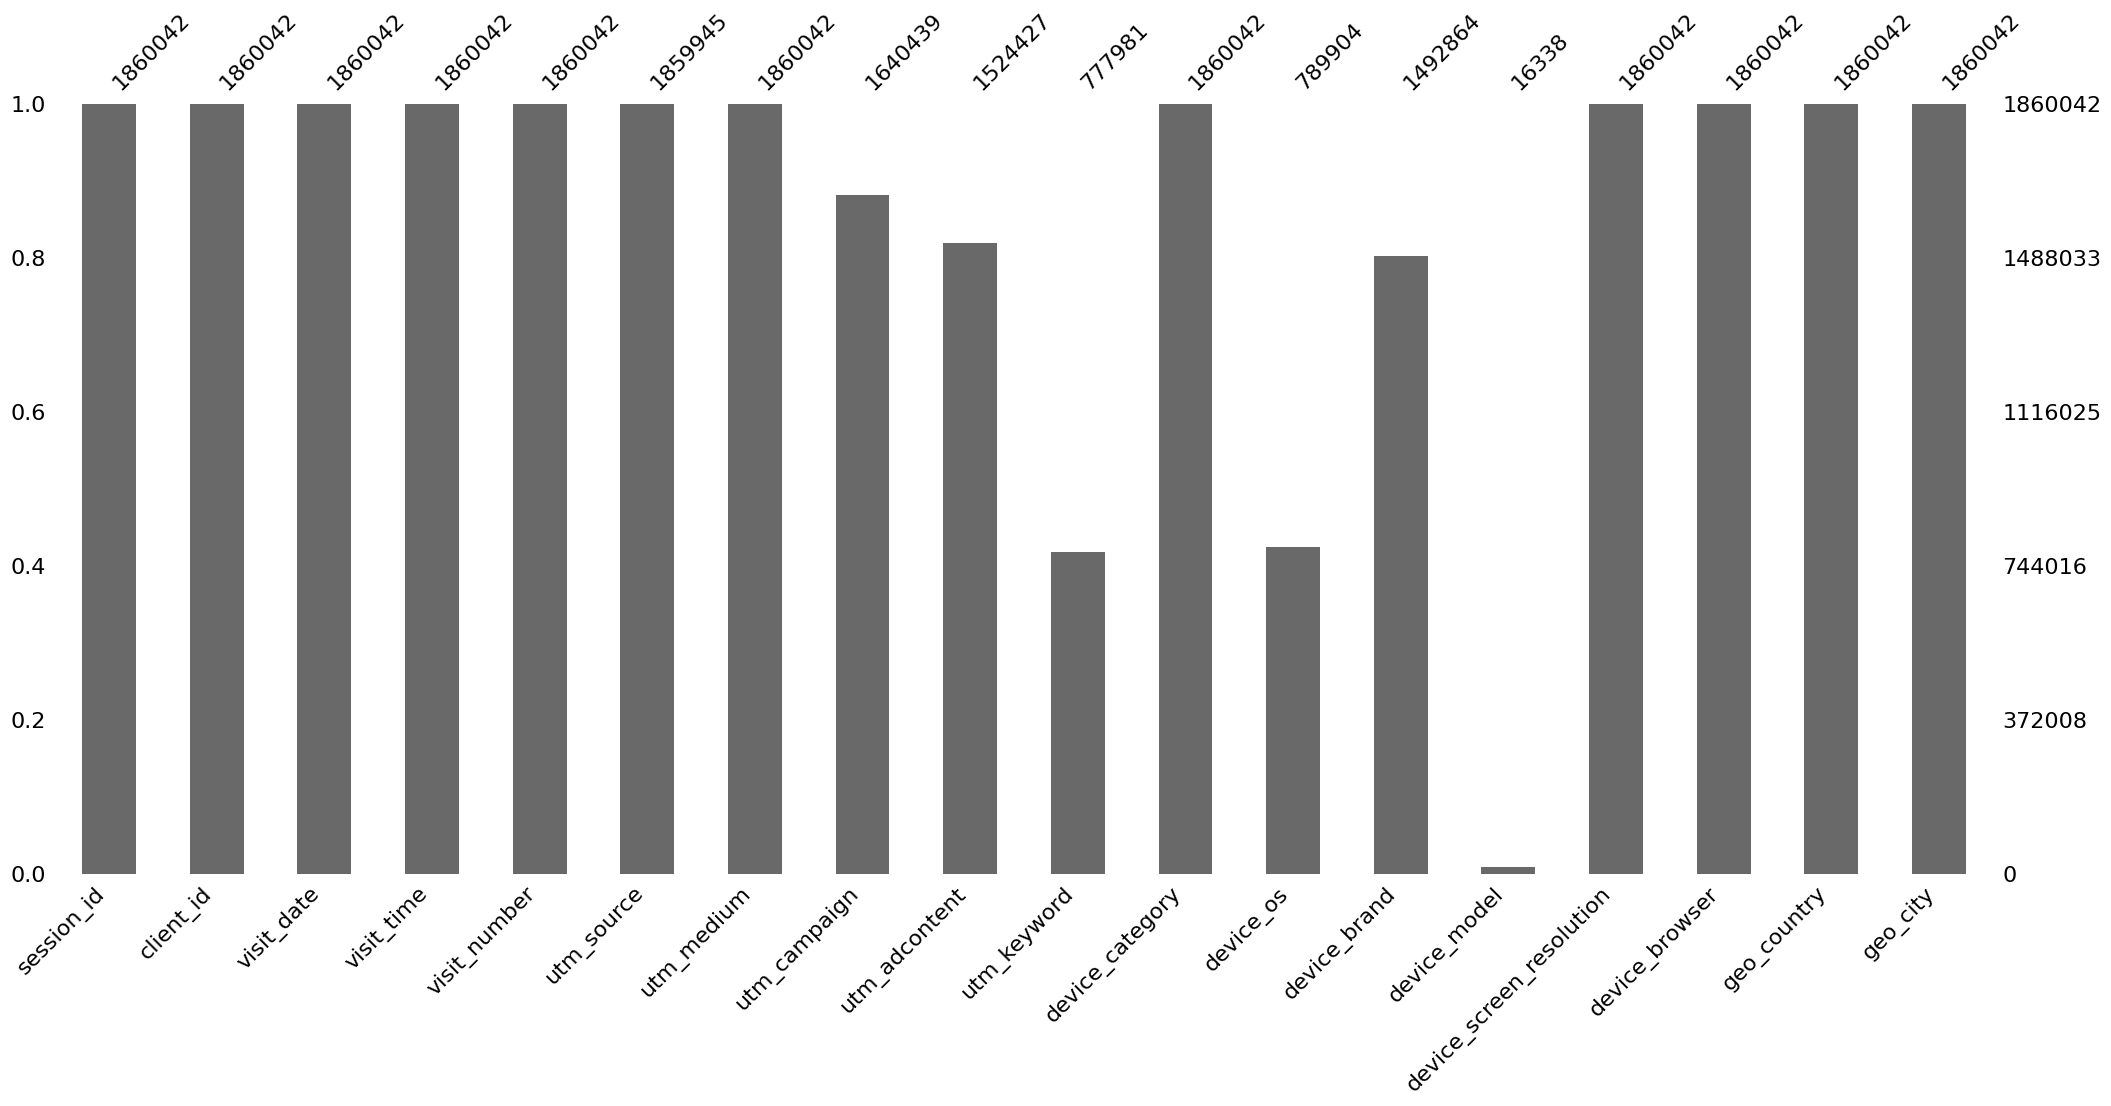

In [6]:
msno.bar(sessions_df)

Проспусков довольно много. Некоторые колонки будет проще удалить, а некоторые заполнить.

(1.0, 15.0)

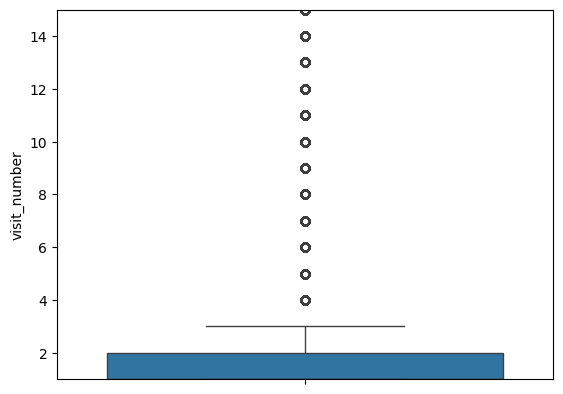

In [7]:
sns.boxplot(data=sessions_df.visit_number, showfliers=True)
plt.ylim(1, 15)

Количество визитов очень сильно варьируется. Похоже, что есть люди, которые очень долго принимают решения, но есть ещё и боты

(1.0, 40.0)

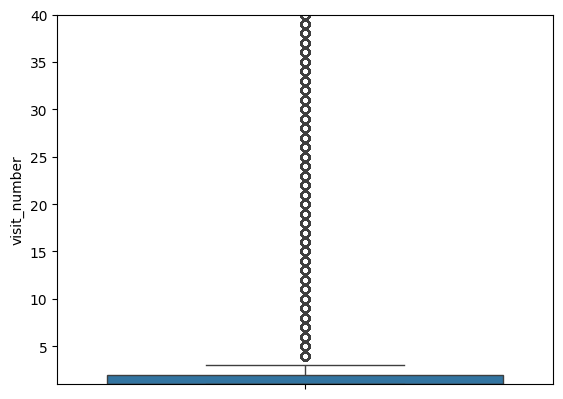

In [8]:
sns.boxplot(data=sessions_df.visit_number, showfliers=True)
plt.ylim(1, 40)

(1.0, 5.0)

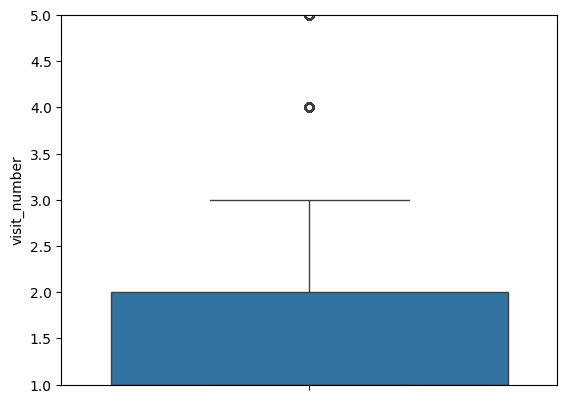

In [9]:
sns.boxplot(data=sessions_df.visit_number, showfliers=True)
plt.ylim(1, 5)

In [10]:
sessions_df.visit_number.max()

np.int64(564)

## Анализ ga_hits 

In [11]:
hits_df = pd.read_csv('data/ga_hits.csv')
hits_df.head(5)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


In [12]:
hits_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   session_id      str    
 1   hit_date        str    
 2   hit_time        float64
 3   hit_number      int64  
 4   hit_type        str    
 5   hit_referer     str    
 6   hit_page_path   str    
 7   event_category  str    
 8   event_action    str    
 9   event_label     str    
 10  event_value     float64
dtypes: float64(2), int64(1), str(8)
memory usage: 1.3 GB


<Axes: >

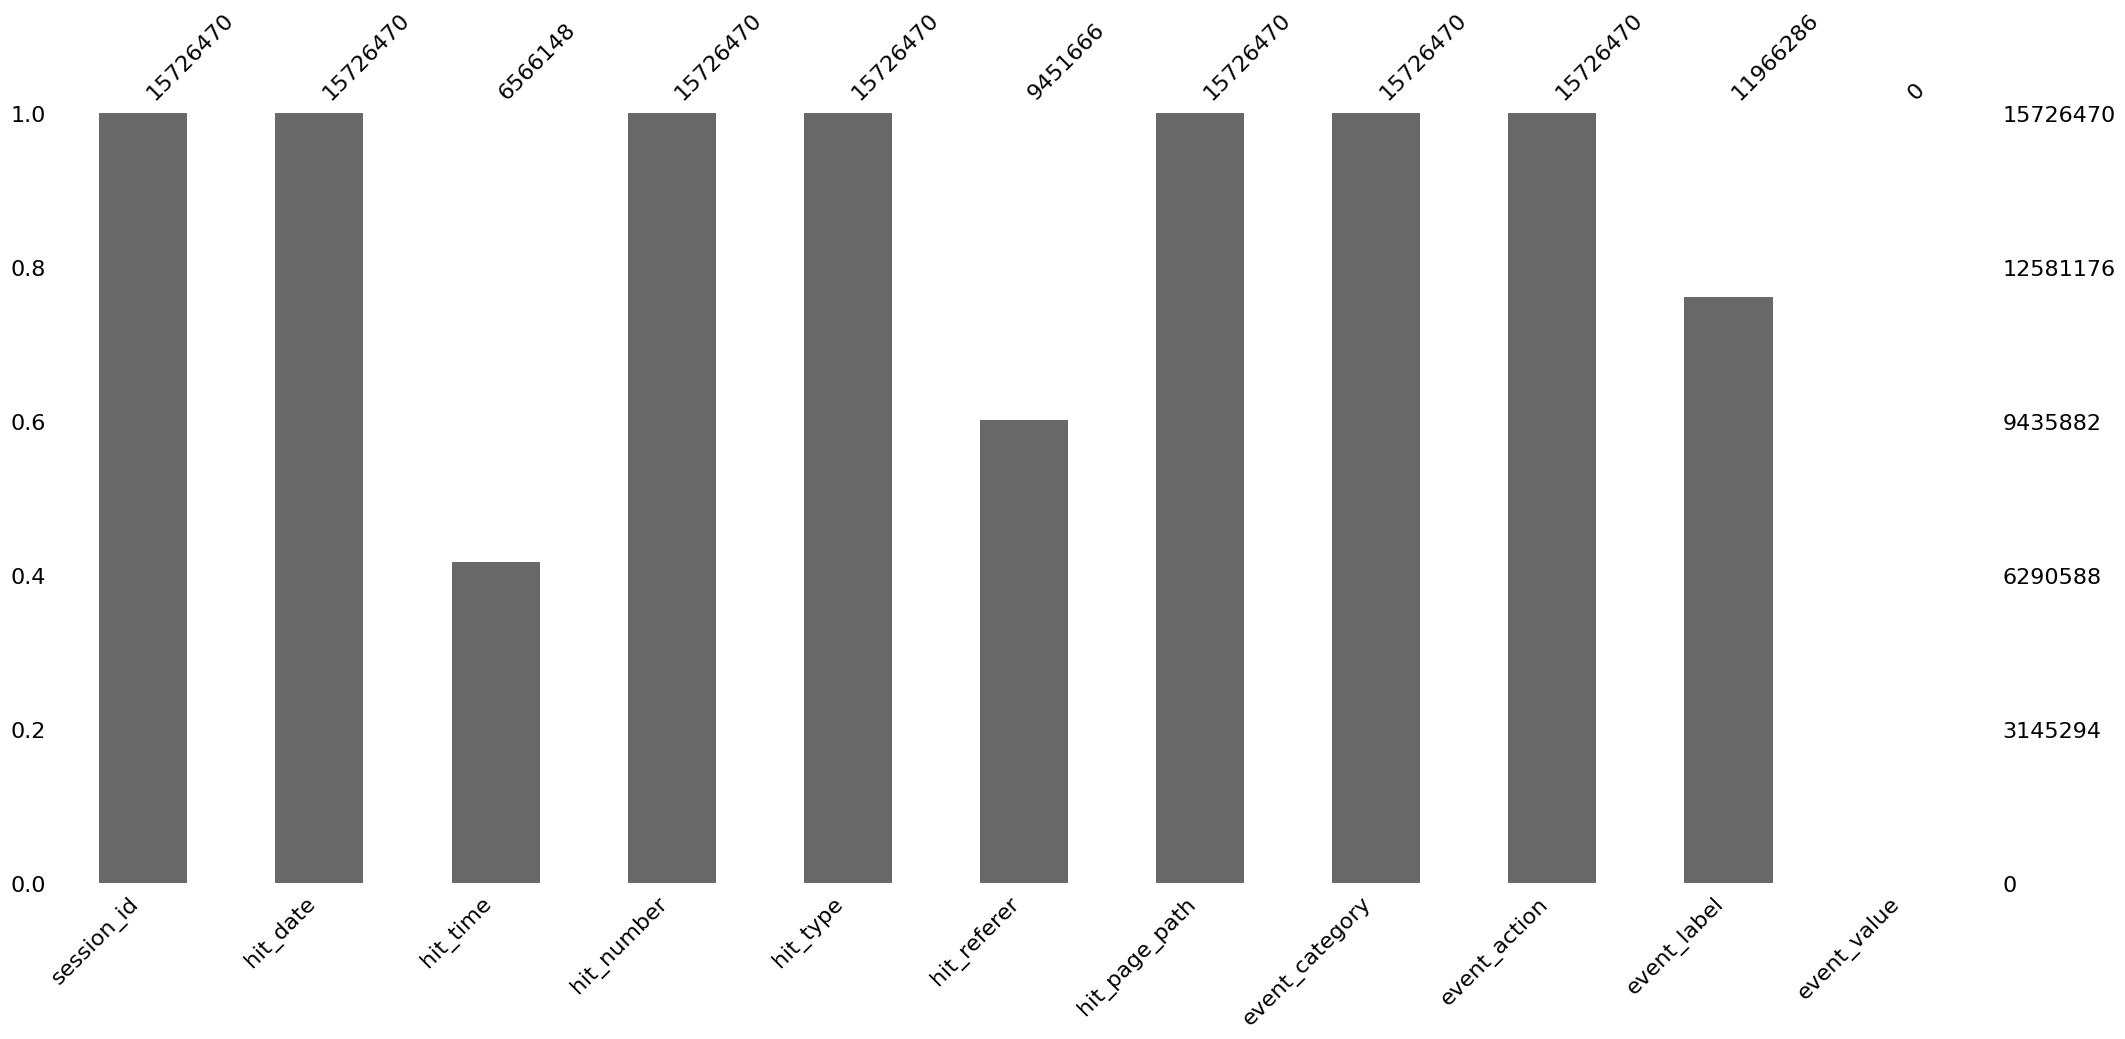

In [13]:
msno.bar(hits_df)

Все пропуски можно заполнить

In [14]:
hits_df.hit_type.nunique()

1

Совершено бесполезный столбец.

In [15]:
hits_df.event_category.unique()

<StringArray>
[                         'quiz',                      'card_web',
                 'sub_page_view',                   'search_form',
                          'auth',                          'chat',
                        'offers',                     'ad_banner',
                    'navigation',                  'profile_menu',
              'sub_button_click',                   'listing_ads',
                          'cars',                    'sub_submit',
                  'main_banners',                        'header',
               'sap_search_form',             'active_invitation',
              'sap_search__form',                        'footer',
           'scrolling_main_page',                       'my_idea',
                         'phone',                 'main_services',
     'greenday_sub_button_click',          'greenday_listing_ads',
     'greenday_gtm.triggergroup',                'credit_buttons',
                    'add_ad_vin',               

In [16]:
hits_df.event_action.unique()

<StringArray>
[                           'quiz_show',
                            'view_card',
                          'sub_landing',
                           'photos_all',
                           'quiz_start',
                           'search_kpp',
                           'start_auth',
                           'start_chat',
                          'go_to_offer',
                         'name_entered',
 ...
                      'callback button',
                    'tesla_banner_show',
                       'click_on_apple',
        'show_popup_error_confirmation',
                     'click_on_android',
 'setelem_postzalog_retargeting_button',
               'new_year_road_help_btn',
                      'titul_page_view',
             'show_pos_status_declined',
           'survey_buy_after_sell_when']
Length: 230, dtype: str

In [17]:
hits_df.hit_referer.unique()

<StringArray>
[                   nan, 'VloVXNWduHeTjUoDkjkO', 'trXmoxcphNjuYcShOXwL',
 'uMnMdxLOIznakHyXLoMC', 'QDnrErJRERbRmvEHvwWY', 'CqGkajCZmVSQVVJUrbUz',
 'zxPaddltVsJZegslUWyX', 'fKlOwMZQuIToXVwBYxtH', 'InufokblhLdayYnloSPA',
 'yetwrnEDxNrksjoAQAtC',
 ...
 'XUBkvPCVxMhdfdZJvvLp', 'KtjQeuFzAkccCVDLmWYW', 'kyNAtgvDjQLlGlQkFtcv',
 'STOWpoKSjKHUmLOOUUkl', 'nabaInLgFceAmcjHtLhZ', 'PYfUUqZWEEVSGFUDpHcn',
 'jPmVYBOZAmSEcpscocTK', 'SyKCPVqPvVwsypNSfuig', 'KpKtMqJlrvgANamYaRSI',
 'tvGabHlPFDvTmIFiCKTL']
Length: 37874, dtype: str

In [18]:
hits_df.event_label.unique()

<StringArray>
[                   nan, 'GYKKaSmRGxilGoDZiuEJ', 'nsSPWOGBZhTHYKHvcPDM',
 'ZMbQwFawhJjkrpMZWybs', 'EicaxODtmDFqKADTgwme', 'mhufEJfVmNfVHJTpbciK',
 'sfCemwVzPyhiUBVuawDb', 'cMCEFfSnnlNHXnIdruks', 'uDrwlhtkwJJbRcbyRaTW',
 'mQyqverWYeUVtBHpOjCG',
 ...
 'UCthpQDJazdzRLsTaDSj', 'PnrFXtXZYZzeeTHKWLyv', 'WfOOEMfOLBMilVVWSGJS',
 'iXgkYQSXdRRLCtJwncEC', 'sWbcnjgZzpfNEvFlrcNo', 'tqhdvaOmRNrgAqCYjOyD',
 'XLmvTJvcLBsbUZGtsnaj', 'zCMGPrpNkfsTcYWqMUzJ', 'NqyZafHYWtVdMoHFaUMP',
 'aNlmojNIfsJaXKZHCDiU']
Length: 39826, dtype: str

Данные действительно разнообразны, но hit_referer и event_label выглядят довольно странно и обладают огромным разнообразием. Подобные колонки будут разбрасывать наши данные, следовательно к ним особое внимание

In [19]:
os.listdir()

['service.py',
 'final.ipynb',
 'instruction.txt',
 'Заметки по анализу модели.pdf',
 'data',
 '__pycache__',
 'model',
 'api.py',
 '.ipynb_checkpoints',
 'sber']

# Cleaning

## Очистка ga_sessions

In [20]:
session_df = sessions_df
session_df.tail(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_adcontent,utm_keyword,device_category,device_os,device_brand,device_model,device_screen_resolution,device_browser,geo_country,geo_city
1860037,9055415581448263752.1640159305.1640159305,2108378238.1640159304,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,NaN,NaN,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.1622007305,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,NaN,mobile,NaN,Apple,NaN,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.1636979515,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,NaN,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.1638189272,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,JNHcPlZPxEMWDnRiyoBf,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,NaN,393x851,Chrome,Russia,Chelyabinsk
1860041,9055430416266113553.1640968742.1640968742,2108381692.1640968721,2021-12-31,19:39:02,1,fgymSoTvjKPEgaIJqsiH,cpm,FTjNLDyTrXaWYgZymFkV,yYdBRbPmBMUZHXwqGxNx,oKjXDUsycmahkgMhGdAR,desktop,Linux,NaN,NaN,1366x768,Chrome,Russia,Moscow


### Удаление бесполезных колоннок

In [21]:
session_df = session_df.drop(['utm_adcontent', 'device_model'], axis=1)
session_df.tail(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city
1860037,9055415581448263752.1640159305.1640159305,2108378238.1640159304,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,NaN,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,1920x1080,Chrome,Russia,Moscow
1860038,9055421130527858185.1622007305.1622007305,2108379530.1622007305,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,NaN,mobile,NaN,Apple,390x844,Safari,Russia,Stavropol
1860039,9055422955903931195.1636979515.1636979515,2108379955.1636979515,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,375x667,Safari,Russia,Moscow
1860040,905543020766873816.1638189404.1638189404,210838164.1638189272,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,393x851,Chrome,Russia,Chelyabinsk
1860041,9055430416266113553.1640968742.1640968742,2108381692.1640968721,2021-12-31,19:39:02,1,fgymSoTvjKPEgaIJqsiH,cpm,FTjNLDyTrXaWYgZymFkV,oKjXDUsycmahkgMhGdAR,desktop,Linux,NaN,1366x768,Chrome,Russia,Moscow


### Преобразование даты

Объеденим колонки с временем в одну для удобства

In [22]:
session_df['visit_datetime'] = pd.to_datetime(
    session_df['visit_date'] + ' ' + session_df['visit_time'], 
    format='%Y-%m-%d %H:%M:%S'
)
session_df.tail(5)

,session_id,client_id,visit_date,visit_time,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime
1860037,9055415581448263752.1640159305.1640159305,2108378238.1640159304,2021-12-22,10:48:25,1,BHcvLfOaCWvWTykYqHVe,cpc,NaN,VlqBmecIOXWjCWUmQkLd,desktop,Windows,NaN,1920x1080,Chrome,Russia,Moscow,2021-12-22 10:48:25
1860038,9055421130527858185.1622007305.1622007305,2108379530.1622007305,2021-05-26,08:00:00,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,NaN,mobile,NaN,Apple,390x844,Safari,Russia,Stavropol,2021-05-26 08:00:00
1860039,9055422955903931195.1636979515.1636979515,2108379955.1636979515,2021-11-15,15:31:55,1,fDLlAcSmythWSCVMvqvL,(none),LTuZkdKfxRGVceoWkVyg,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,375x667,Safari,Russia,Moscow,2021-11-15 15:31:55
1860040,905543020766873816.1638189404.1638189404,210838164.1638189272,2021-11-29,15:36:44,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Xiaomi,393x851,Chrome,Russia,Chelyabinsk,2021-11-29 15:36:44
1860041,9055430416266113553.1640968742.1640968742,2108381692.1640968721,2021-12-31,19:39:02,1,fgymSoTvjKPEgaIJqsiH,cpm,FTjNLDyTrXaWYgZymFkV,oKjXDUsycmahkgMhGdAR,desktop,Linux,NaN,1366x768,Chrome,Russia,Moscow,2021-12-31 19:39:02


Теперь удалим оставшиеся ненужные столбцы

In [23]:
session_df = session_df.drop(['visit_date', 'visit_time'], axis=1)
session_df.head(5)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,2021-11-24 14:36:32
1,905544597018549464.1636867290.1636867290,210838531.1636867288,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,2021-11-14 08:21:30
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,2021-12-28 02:42:06
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,1,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2,kjsLglQLzykiRbcDiGcD,cpc,NaN,NaN,mobile,NaN,Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00


### Заполняем пропуски

Заполним колноку с ключевыми словами

In [24]:
session_df.utm_keyword = session_df.utm_keyword.fillna('keywordless')
session_df.utm_keyword.info()

<class 'pandas.Series'>
RangeIndex: 1860042 entries, 0 to 1860041
Series name: utm_keyword
Non-Null Count    Dtype
--------------    -----
1860042 non-null  str  
dtypes: str(1)
memory usage: 14.2 MB


Заполними колонку с названиями ОС клиента модой

In [25]:
mode_of_device_os = session_df.device_os.mode()
session_df.device_os = session_df.device_os.fillna(str(mode_of_device_os))
session_df.device_os.info()

<class 'pandas.Series'>
RangeIndex: 1860042 entries, 0 to 1860041
Series name: device_os
Non-Null Count    Dtype
--------------    -----
1860042 non-null  str  
dtypes: str(1)
memory usage: 14.2 MB


Заполним колонку с рекламными кампаниями

In [26]:
session_df.utm_campaign = session_df.utm_campaign.fillna('campaignless')
session_df.utm_campaign.info()

<class 'pandas.Series'>
RangeIndex: 1860042 entries, 0 to 1860041
Series name: utm_campaign
Non-Null Count    Dtype
--------------    -----
1860042 non-null  str  
dtypes: str(1)
memory usage: 14.2 MB


Заполним колонку с брендом девайса клиента

In [27]:
mode_of_device_brand = session_df.device_brand.mode()
session_df.device_brand = session_df.device_brand.fillna(str(mode_of_device_brand))

In [28]:
session_df.device_brand.info()

<class 'pandas.Series'>
RangeIndex: 1860042 entries, 0 to 1860041
Series name: device_brand
Non-Null Count    Dtype
--------------    -----
1860042 non-null  str  
dtypes: str(1)
memory usage: 14.2 MB


Посмотрим результат

<Axes: >

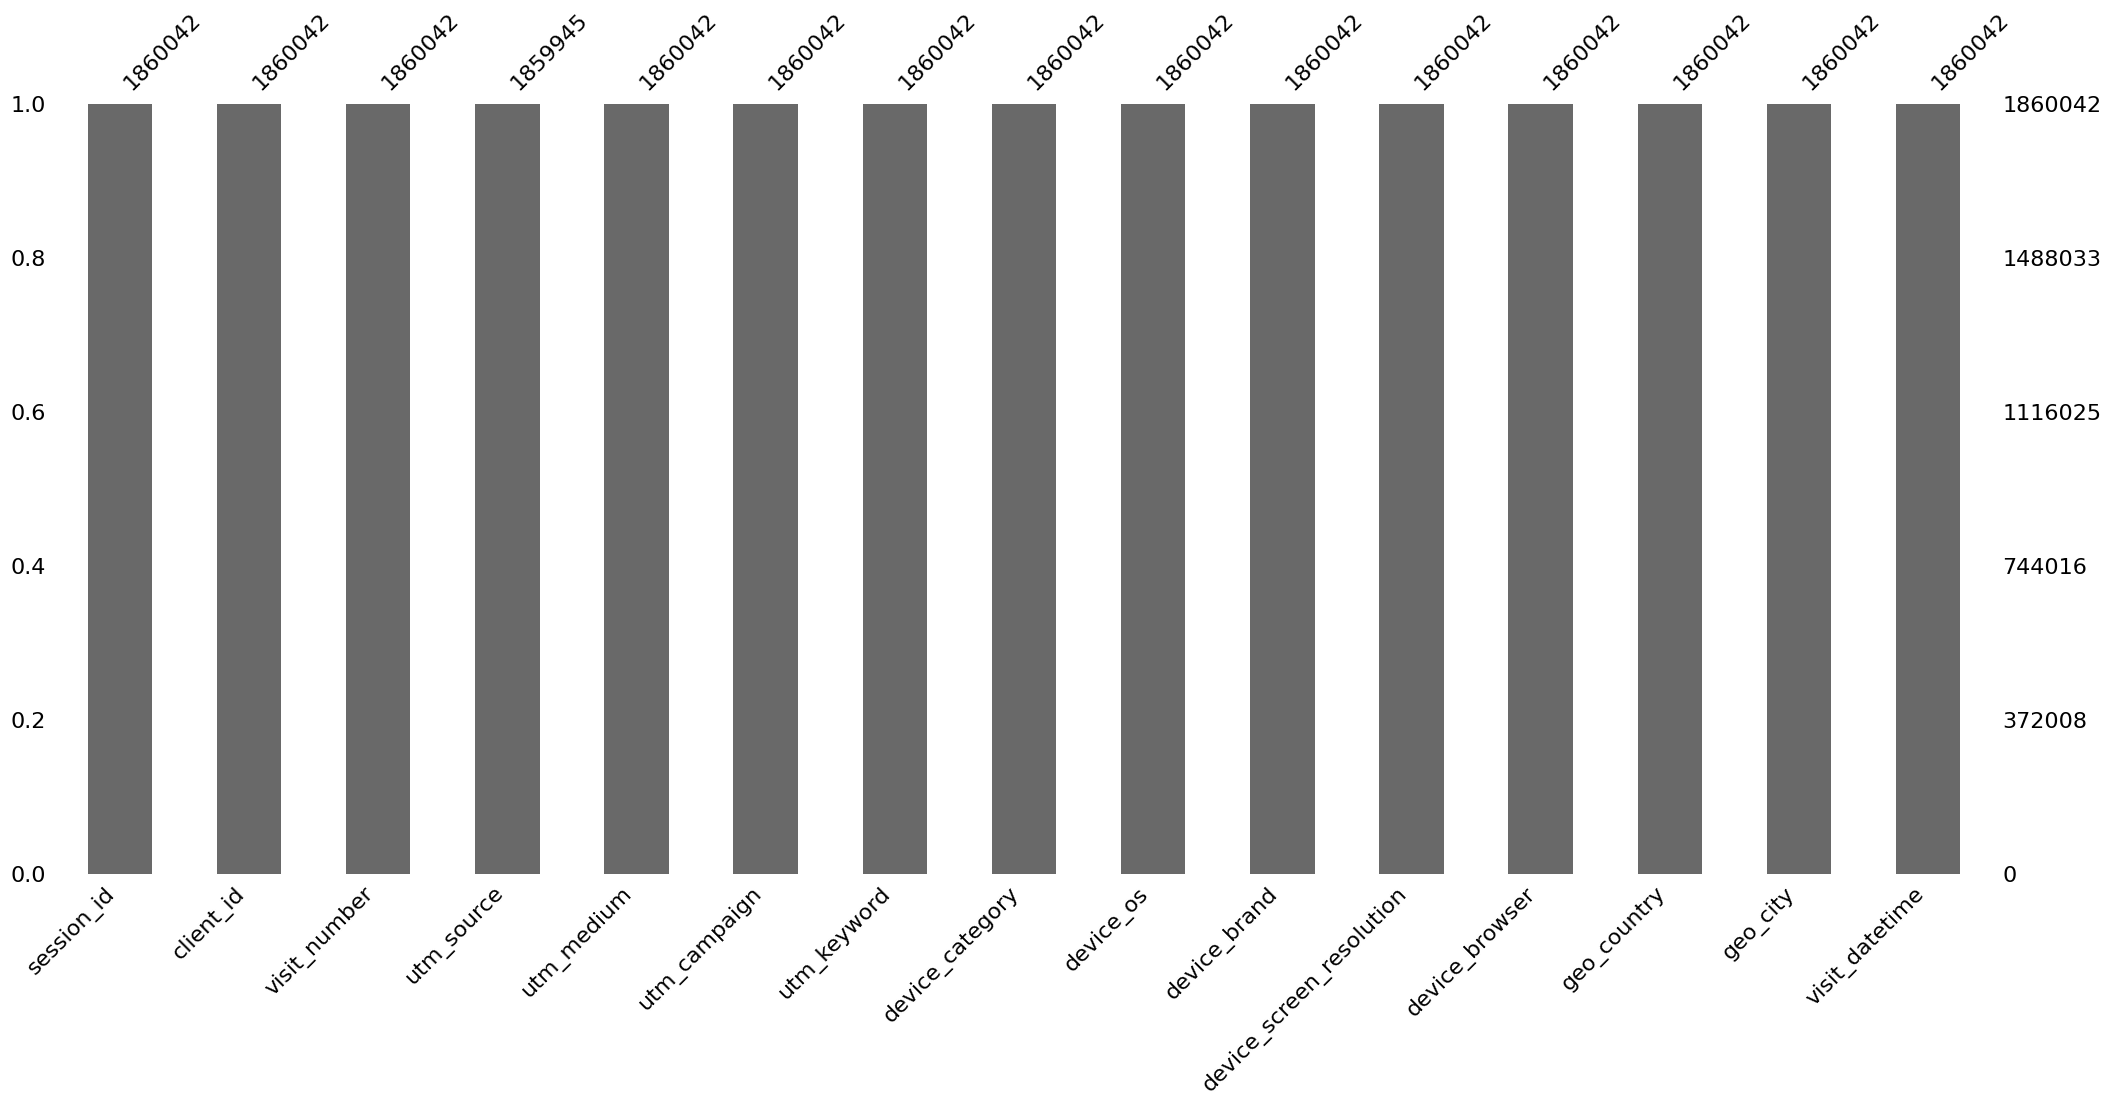

In [29]:
msno.bar(session_df)

Отлично! Пропуски заполненны!

### Обработка выбрасов

In [30]:
def calc_outliers(data):
    q25 = data.quantile(0.25)
    q75 = data.quantile(0.75)
    iqr = q75 - q25

    return (q25 - 1.5*iqr, q75 + 1.5*iqr)

Обработаем колонку с датой

In [31]:
bounds_of_datetime = calc_outliers(session_df.visit_datetime)
bounds_of_datetime

(Timestamp('2021-02-14 05:03:48'), Timestamp('2022-05-11 23:33:40'))

In [32]:
is_outlier_low = session_df.visit_datetime < bounds_of_datetime[0]
is_outlier_high = session_df.visit_datetime > bounds_of_datetime[1]
session_df[is_outlier_high]

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime


In [33]:
session_df[is_outlier_low]

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime


<Axes: ylabel='visit_datetime'>

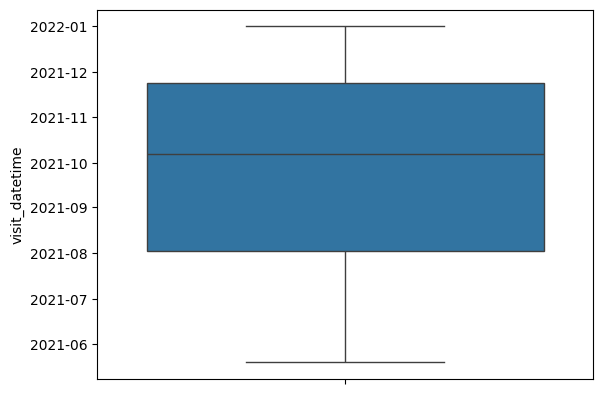

In [34]:
sns.boxplot(data=session_df.visit_datetime, showfliers=True)

Похоже, что аномалий с датами нету. Перейдем к порядковому номеру

In [35]:
bounds_of_visit_number = calc_outliers(session_df.visit_number)
bounds_of_visit_number

(np.float64(-0.5), np.float64(3.5))

В данном столбце обрабатывать выбросы мы не будем. Чтобы понять почему, достаточно быть человеком. Клиент может долго принимать решение, в связи с разными обстоятельствами (очень ограниченный бюджет например). Но посмотреть на предельные значения всё же стоит.

In [36]:
print(session_df.visit_number.max())
strangers = range(100, 565)
session_df[session_df['visit_number'].isin(strangers)]['visit_number'].value_counts()

564


visit_number
100    78
101    75
104    75
103    74
106    74
       ..
560     1
561     1
562     1
563     1
564     1
Name: count, Length: 438, dtype: int64

In [37]:
session_df.visit_number.value_counts()[22]

np.int64(1082)

Итак, можено установить границу в 22. Клиент врядли будет заходить по 20+ раз на сайт. Даже если такие есть, их единицы, а данных у нас миллионы. Также мы предостережёмся от наличия ботов

In [38]:
is_outlier = session_df.visit_number > 22
clean_df_session = session_df.copy().drop(session_df[is_outlier].index)

In [39]:
clean_df_session.head(10)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,2021-11-24 14:36:32
1,905544597018549464.1636867290.1636867290,210838531.1636867288,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,2021-11-14 08:21:30
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,2021-12-28 02:42:06
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,1,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00
5,9055447192389856083.1622453074.1622453074,2108385598.1622453075,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Apple,375x812,Safari,Russia,Saint Petersburg,2021-05-31 12:00:00
6,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,602x1029,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28
7,9055461992850812764.1626107740.1626107740,2108389044.1626107740,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Samsung,360x640,Chrome,Russia,Saint Petersburg,2021-07-12 19:00:00
8,9055462349345527315.1638536723.1638536723,2108389127.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,390x844,Safari,Russia,Moscow,2021-12-03 16:05:23
9,9055466554104774132.1624800757.1624800757,2108390106.1624800756,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Samsung,412x915,Chrome,Russia,Moscow,2021-06-27 16:00:00


### Удаление дубликатов

In [40]:
clean_df_session[clean_df_session.duplicated()]

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime


### Проверка

<Axes: >

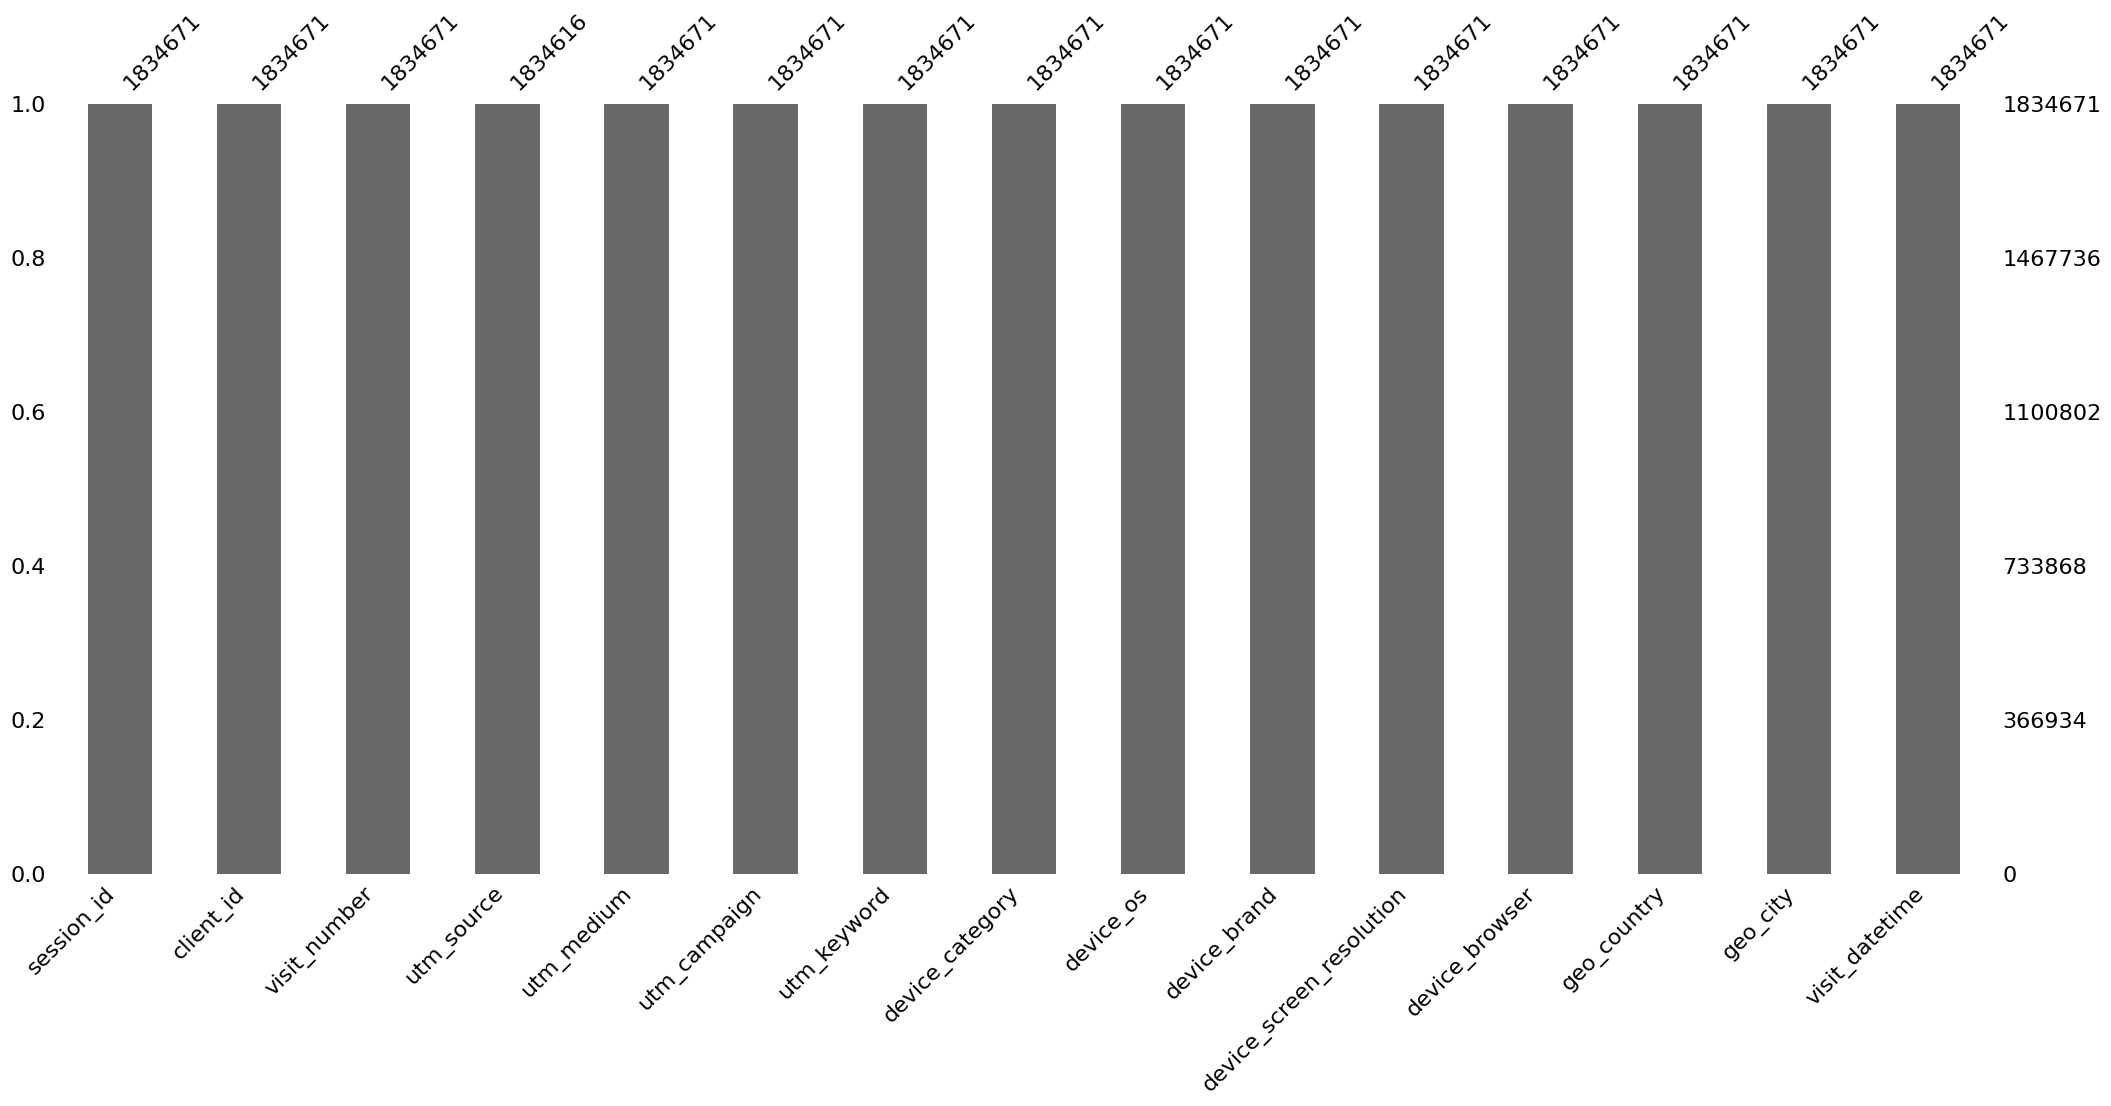

In [41]:
msno.bar(clean_df_session)

In [42]:
clean_df_session.info()

<class 'pandas.DataFrame'>
Index: 1834671 entries, 0 to 1860041
Data columns (total 15 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                str           
 1   client_id                 str           
 2   visit_number              int64         
 3   utm_source                str           
 4   utm_medium                str           
 5   utm_campaign              str           
 6   utm_keyword               str           
 7   device_category           str           
 8   device_os                 str           
 9   device_brand              str           
 10  device_screen_resolution  str           
 11  device_browser            str           
 12  geo_country               str           
 13  geo_city                  str           
 14  visit_datetime            datetime64[us]
dtypes: datetime64[us](1), int64(1), str(13)
memory usage: 224.0 MB


Пропуски заполнены, типы приведены. Выбросы и аномалии в данных были обработаны. Дубликатов не оказалось

## Очистка ga_hits

In [43]:
hit_df = hits_df
hit_df.head(5)

,session_id,hit_date,hit_time,hit_number,hit_type,hit_referer,hit_page_path,event_category,event_action,event_label,event_value
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,event,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,event,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,event,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,event,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,event,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN,NaN


### Удаление бесполезных колонок

In [44]:
hit_df = hit_df.drop(['event_value', 'hit_type'], axis=1)
hit_df.shape

(15726470, 9)

In [45]:
hit_df.tail(5)

,session_id,hit_date,hit_time,hit_number,hit_referer,hit_page_path,event_category,event_action,event_label
15726465,6866159858916559617.1640270865.1640270865,2021-12-23,810589.0,43,NaN,sberauto.com/cars/all/toyota/fortuner/24cb5af2...,quiz,quiz_show,NaN
15726466,7310304587364460692.1640261783.1640261783,2021-12-23,904927.0,40,NaN,sberauto.com/cars/all/mercedes-benz/gla-klasse...,quiz,quiz_show,NaN
15726467,8013702685784312179.1640270195.1640270195,2021-12-23,2172865.0,43,NaN,sberauto.com/cars/all/toyota/alphard/2ebe4871?...,quiz,quiz_show,NaN
15726468,8021505554734405918.1640257821.1640257821,2021-12-23,713325.0,45,NaN,sberauto.com/cars/all/bmw/x3/6a660f0a?rental_p...,quiz,quiz_show,NaN
15726469,1569014437485249865.1640269129.1640269129,2021-12-23,742820.0,46,NaN,sberauto.com/cars/all/bmw/7-serii/399ac530?utm...,quiz,quiz_show,NaN


### Преобразование дат

In [46]:
hit_df.hit_date = pd.to_datetime(hit_df.hit_date, format='%Y-%m-%d')
hit_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15726470 entries, 0 to 15726469
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   session_id      str           
 1   hit_date        datetime64[us]
 2   hit_time        float64       
 3   hit_number      int64         
 4   hit_referer     str           
 5   hit_page_path   str           
 6   event_category  str           
 7   event_action    str           
 8   event_label     str           
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 1.1 GB


In [47]:
hit_df.head(5)

,session_id,hit_date,hit_time,hit_number,hit_referer,hit_page_path,event_category,event_action,event_label
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,NaN,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,NaN
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,NaN,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,NaN
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,NaN,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,NaN
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,NaN,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,NaN
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,NaN,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,NaN


### Заполнение пропусков

In [48]:
mean_hit_date = hit_df.hit_date.mean()
mean_hit_time = hit_df.hit_time.median()
hit_df.hit_date = hit_df.hit_date.fillna(mean_hit_date)
hit_df.hit_time = hit_df.hit_time.fillna(mean_hit_time)
hit_df.hit_date.info()

<class 'pandas.Series'>
RangeIndex: 15726470 entries, 0 to 15726469
Series name: hit_date
Non-Null Count     Dtype         
--------------     -----         
15726470 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 120.0 MB


In [49]:
hit_df.event_label = hit_df.event_label.fillna('actionless')
hit_df.hit_referer = hit_df.hit_referer.fillna('unknown')

In [50]:
hit_df.hit_referer.info()

<class 'pandas.Series'>
RangeIndex: 15726470 entries, 0 to 15726469
Series name: hit_referer
Non-Null Count     Dtype
--------------     -----
15726470 non-null  str  
dtypes: str(1)
memory usage: 120.0 MB


In [51]:
hit_df.tail(15)

,session_id,hit_date,hit_time,hit_number,hit_referer,hit_page_path,event_category,event_action,event_label
15726455,5296596234193380228.1640276868.1640276868,2021-12-23,1006170.0,26,unknown,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,actionless
15726456,6857546147385616744.1640278376.1640278376,2021-12-23,1219087.0,26,unknown,sberauto.com/cars/all/bmw/x3/6a660f0a?utm_sour...,quiz,quiz_show,actionless
15726457,2140137327123778117.1640266227.1640266227,2021-12-23,1154313.0,28,unknown,sberauto.com/cars/all/bmw/x3/6a660f0a?rental_p...,quiz,quiz_show,actionless
15726458,1752395810013978028.1640242606.1640242606,2021-12-23,738385.0,29,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,actionless
15726459,4787939928687122204.1640266942.1640266942,2021-12-23,823172.0,30,unknown,sberauto.com/cars/all/kia/rio/fee33fe6?rental_...,quiz,quiz_show,actionless
15726460,3955551498414641539.1640288645.1640288645,2021-12-23,1423227.0,29,unknown,sberauto.com/cars/all/renault/duster/145d53f1?...,quiz,quiz_show,actionless
15726461,788733220421394146.1640259301.1640259301,2021-12-23,601072.0,32,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,actionless
15726462,5667731642505283078.1640285708.1640285708,2021-12-23,710532.0,35,unknown,sberauto.com/cars/all/renault/logan/8c3c73f2?u...,quiz,quiz_show,actionless
15726463,4241095243673670992.1640273232.1640273232,2021-12-23,676929.0,30,unknown,sberauto.com/cars?utm_source_initial=dzen&utm_...,quiz,quiz_show,actionless
15726464,2213339474111531465.1640270285.1640270285,2021-12-23,652518.0,37,unknown,sberauto.com/cars/all/bmw/5-serii/eb5698f6?utm...,quiz,quiz_show,actionless


### Обработка выбросов

<Axes: ylabel='hit_date'>

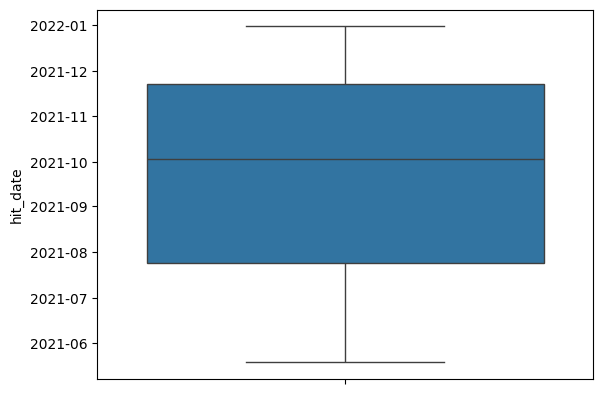

In [52]:
sns.boxplot(data=hit_df.hit_date, showfliers=True)

С датами всё очень хорошо, посмотрим hit_time

In [53]:
bounds_of_hittime = calc_outliers(hit_df.hit_time)
bounds_of_hittime

(np.float64(89941.0), np.float64(89941.0))

In [54]:
is_outlier_of_hittime_low = hit_df.hit_time < bounds_of_hittime[0]
is_outlier_of_hittime_high = hit_df.hit_time > bounds_of_hittime[1]

hit_df[is_outlier_of_hittime_high]

,session_id,hit_date,hit_time,hit_number,hit_referer,hit_page_path,event_category,event_action,event_label
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,unknown,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,actionless
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,unknown,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,actionless
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,unknown,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,actionless
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,actionless
4,3450086108837475701.1640265078.1640265078,2021-12-23,768741.0,79,unknown,sberauto.com/cars/all/mercedes-benz/cla-klasse...,quiz,quiz_show,actionless
...,...,...,...,...,...,...,...,...,...
15726465,6866159858916559617.1640270865.1640270865,2021-12-23,810589.0,43,unknown,sberauto.com/cars/all/toyota/fortuner/24cb5af2...,quiz,quiz_show,actionless
15726466,7310304587364460692.1640261783.1640261783,2021-12-23,904927.0,40,unknown,sberauto.com/cars/all/mercedes-benz/gla-klasse...,quiz,quiz_show,actionless
15726467,8013702685784312179.1640270195.1640270195,2021-12-23,2172865.0,43,unknown,sberauto.com/cars/all/toyota/alphard/2ebe4871?...,quiz,quiz_show,actionless
15726468,8021505554734405918.1640257821.1640257821,2021-12-23,713325.0,45,unknown,sberauto.com/cars/all/bmw/x3/6a660f0a?rental_p...,quiz,quiz_show,actionless


In [55]:
bounds_of_hit_number = calc_outliers(hit_df.hit_number)
bounds_of_hit_number

(np.float64(-26.0), np.float64(62.0))

Т.к выбросы есть (они значительны, ведь только бот может совершать огромное чилсо клиоков. Однако бывают редкие исключения, но в связи с размерами нашего исходного DataFrame, сильно данные не пострадают от исключения подобных аномалий.

In [56]:
is_outlier_hit_number = (hit_df.hit_number < bounds_of_hit_number[0]) | (hit_df.hit_number > bounds_of_hit_number[1])
is_outlier_hit_number.sum()

np.int64(1061598)

In [57]:
clean_hit_df = hit_df.copy()
clean_hit_df.shape

(15726470, 9)

In [58]:
clean_hit_df.drop(clean_hit_df[is_outlier_hit_number].index, inplace=True)
clean_hit_df.shape

(14664872, 9)

### Проверка

<Axes: >

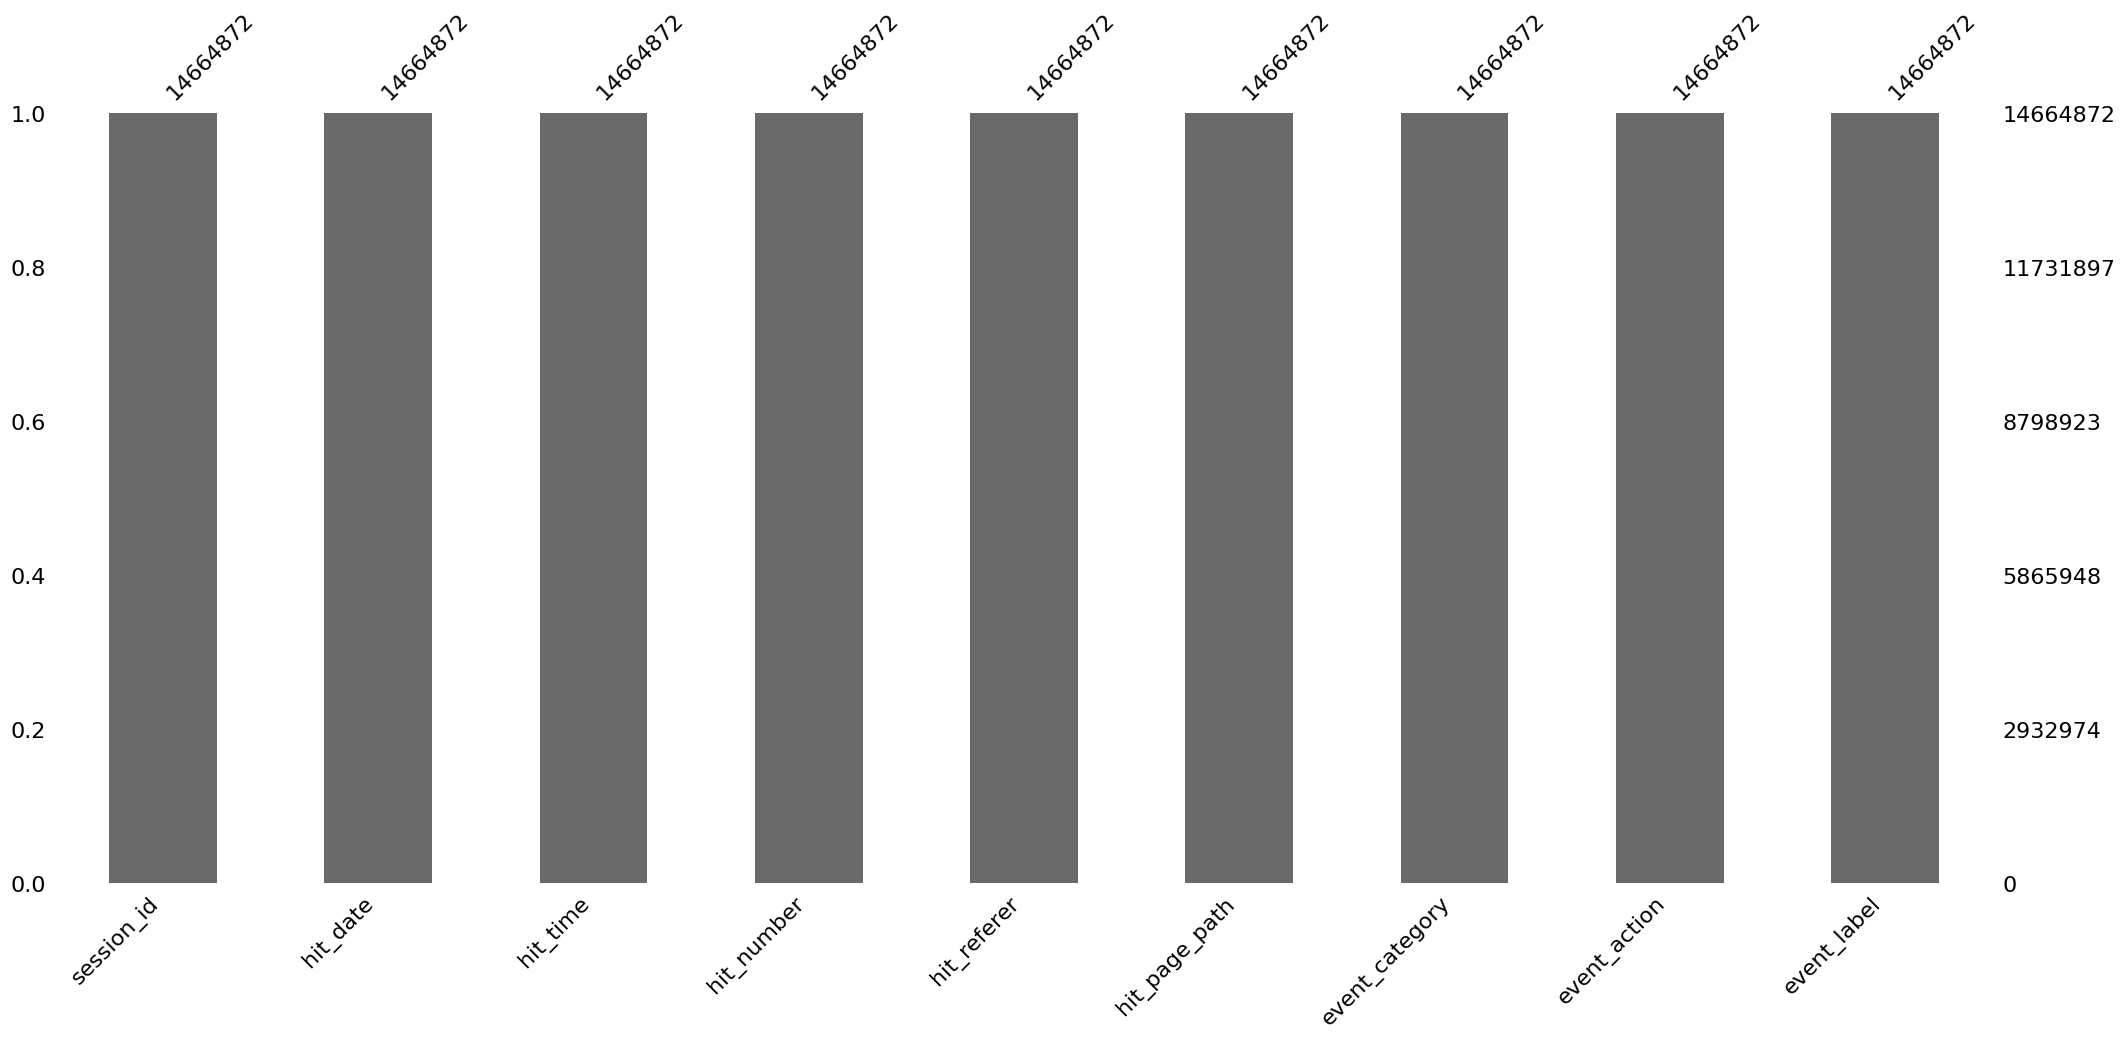

In [59]:
msno.bar(clean_hit_df)

In [60]:
clean_hit_df.info()

<class 'pandas.DataFrame'>
Index: 14664872 entries, 0 to 15726469
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   session_id      str           
 1   hit_date        datetime64[us]
 2   hit_time        float64       
 3   hit_number      int64         
 4   hit_referer     str           
 5   hit_page_path   str           
 6   event_category  str           
 7   event_action    str           
 8   event_label     str           
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 1.1 GB


Пропуски заполнены, типы приведены. Выбросы и аномалии в данных были обработаны. Дубликатов не оказалось.

# Visualisation

## clean_ga_sessions visualisation

In [61]:
dfs = clean_df_session
dfs.head(5)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,device_screen_resolution,device_browser,geo_country,geo_city,visit_datetime
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Zlatoust,2021-11-24 14:36:32
1,905544597018549464.1636867290.1636867290,210838531.1636867288,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,385x854,Samsung Internet,Russia,Moscow,2021-11-14 08:21:30
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,360x720,Chrome,Russia,Krasnoyarsk,2021-12-28 02:42:06
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,1,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,"0 Android\nName: device_os, dtype: str",Xiaomi,393x786,Chrome,Russia,Moscow,2021-05-29 05:00:00


In [62]:
dfs['visit_datetime'] = pd.to_datetime(
    dfs['visit_datetime'],
    format='%Y-%m-%d %H:%M:%S'
)
dfs.info()

<class 'pandas.DataFrame'>
Index: 1834671 entries, 0 to 1860041
Data columns (total 15 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                str           
 1   client_id                 str           
 2   visit_number              int64         
 3   utm_source                str           
 4   utm_medium                str           
 5   utm_campaign              str           
 6   utm_keyword               str           
 7   device_category           str           
 8   device_os                 str           
 9   device_brand              str           
 10  device_screen_resolution  str           
 11  device_browser            str           
 12  geo_country               str           
 13  geo_city                  str           
 14  visit_datetime            datetime64[us]
dtypes: datetime64[us](1), int64(1), str(13)
memory usage: 224.0 MB


### Определим категориальные переменные, пригодные для анализа

In [63]:
for col in dfs.columns:
    print(f'{col}: {dfs[col].nunique()}')

session_id: 1834671
client_id: 1391569
visit_number: 22
utm_source: 284
utm_medium: 55
utm_campaign: 399
utm_keyword: 1211
device_category: 3
device_os: 14
device_brand: 206
device_screen_resolution: 5026
device_browser: 57
geo_country: 166
geo_city: 2546
visit_datetime: 712840


Выделяем переменные для анализа: utm_medium, device_category, device_os, device_browser, geo_counry


### Анализ переменных device_category, device_os, device_browser

In [64]:
dfs.device_category.unique()

<StringArray>
['mobile', 'tablet', 'desktop']
Length: 3, dtype: str

In [65]:
dfs.device_os.unique()

<StringArray>
[                                  'Android',
 '0    Android\nName: device_os, dtype: str',
                                       'iOS',
                                   'Windows',
                                     'Linux',
                                 'Macintosh',
                                 '(not set)',
                                 'Chrome OS',
                                'BlackBerry',
                                     'Tizen',
                                'Firefox OS',
                                   'Samsung',
                             'Windows Phone',
                                     'Nokia']
Length: 14, dtype: str

In [66]:
# Обработаем странное значение 0 Android
mask = dfs['device_os'].str.contains('Android', case=False, na=False)
dfs.loc[mask, 'device_os'] = 'Android'
dfs.device_os.unique()

<StringArray>
[      'Android',           'iOS',       'Windows',         'Linux',
     'Macintosh',     '(not set)',     'Chrome OS',    'BlackBerry',
         'Tizen',    'Firefox OS',       'Samsung', 'Windows Phone',
         'Nokia']
Length: 13, dtype: str

In [67]:
dfs.device_browser.unique()

<StringArray>
[                          'Chrome',                 'Samsung Internet',
                           'Safari',                        'YaBrowser',
                  'Android Webview',                  'Safari (in-app)',
                            'Opera',                          'Firefox',
                             'Edge',                       'helloworld',
 'Instagram 208.0.0.32.135 Android', 'Instagram 209.0.0.21.119 Android',
                  'Android Runtime',                       'UC Browser',
         'Mozilla Compatible Agent',                        '(not set)',
                          'Mozilla',                       'Opera Mini',
                          'Coc Coc', 'Instagram 213.0.0.29.120 Android',
                          'Android', 'Instagram 216.1.0.21.137 Android',
                            '[FBAN',                'Internet Explorer',
                           'Puffin',                         'MRCHROME',
                  'com.vk.vkclient', 

In [68]:
# Уменьшим число браузеров, обработов колонку
mask = dfs['device_browser'].str.contains('Instagram|Threads', case=False, na=False)
dfs.loc[mask, 'device_browser'] = dfs.loc[mask, 'device_browser'].str.extract(r'(Instagram|Threads)', expand=False)
dfs['device_browser'].unique()

<StringArray>
[                  'Chrome',         'Samsung Internet',
                   'Safari',                'YaBrowser',
          'Android Webview',          'Safari (in-app)',
                    'Opera',                  'Firefox',
                     'Edge',               'helloworld',
                'Instagram',          'Android Runtime',
               'UC Browser', 'Mozilla Compatible Agent',
                '(not set)',                  'Mozilla',
               'Opera Mini',                  'Coc Coc',
                  'Android',                    '[FBAN',
        'Internet Explorer',                   'Puffin',
                 'MRCHROME',          'com.vk.vkclient',
          'Android Browser',                  'Maxthon',
              'Amazon Silk',                'SeaMonkey',
                    'MyApp',                 'NetFront',
                'MT6735_TD',               'NokiaX2-02',
                 'Nokia501',          'Phantom Browser',
 'com.zhiliaoapp.

In [69]:
dfs.device_browser.value_counts()

device_browser
Chrome                      996454
Safari                      476702
YaBrowser                   129078
Safari (in-app)              69912
Android Webview              55328
Samsung Internet             46788
Opera                        25994
Firefox                      16408
Edge                         15334
UC Browser                     871
Instagram                      396
Android Runtime                392
Mozilla Compatible Agent       362
[FBAN                          269
MRCHROME                        77
Android Browser                 49
Opera Mini                      45
Puffin                          45
Internet Explorer               36
Maxthon                         31
Android                         22
(not set)                       17
Mozilla                         17
com.vk.vkclient                  8
Amazon Silk                      7
helloworld                       6
Coc Coc                          6
SeaMonkey                        4
MyApp

In [70]:
# Подчистим редкие значения
threshold = 100

freq = dfs['device_browser'].value_counts()
rare_browsers = freq[freq < threshold].index

dfs = dfs[~dfs['device_browser'].isin(rare_browsers)]
dfs.device_browser.value_counts()

device_browser
Chrome                      996454
Safari                      476702
YaBrowser                   129078
Safari (in-app)              69912
Android Webview              55328
Samsung Internet             46788
Opera                        25994
Firefox                      16408
Edge                         15334
UC Browser                     871
Instagram                      396
Android Runtime                392
Mozilla Compatible Agent       362
[FBAN                          269
Name: count, dtype: int64

#### Графики распределений переменных

Text(0.5, 1.0, "distribution of devices' categories")

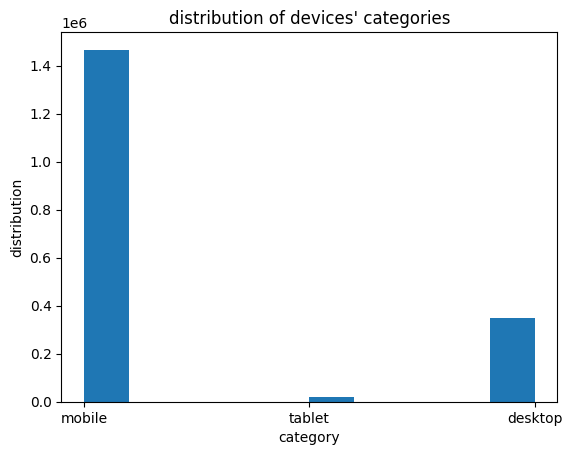

In [71]:
plt.hist(dfs.device_category)
plt.xlabel('category')
plt.ylabel('distribution')
plt.title("distribution of devices' categories")

Text(0.5, 1.0, 'distribution of operation systems')

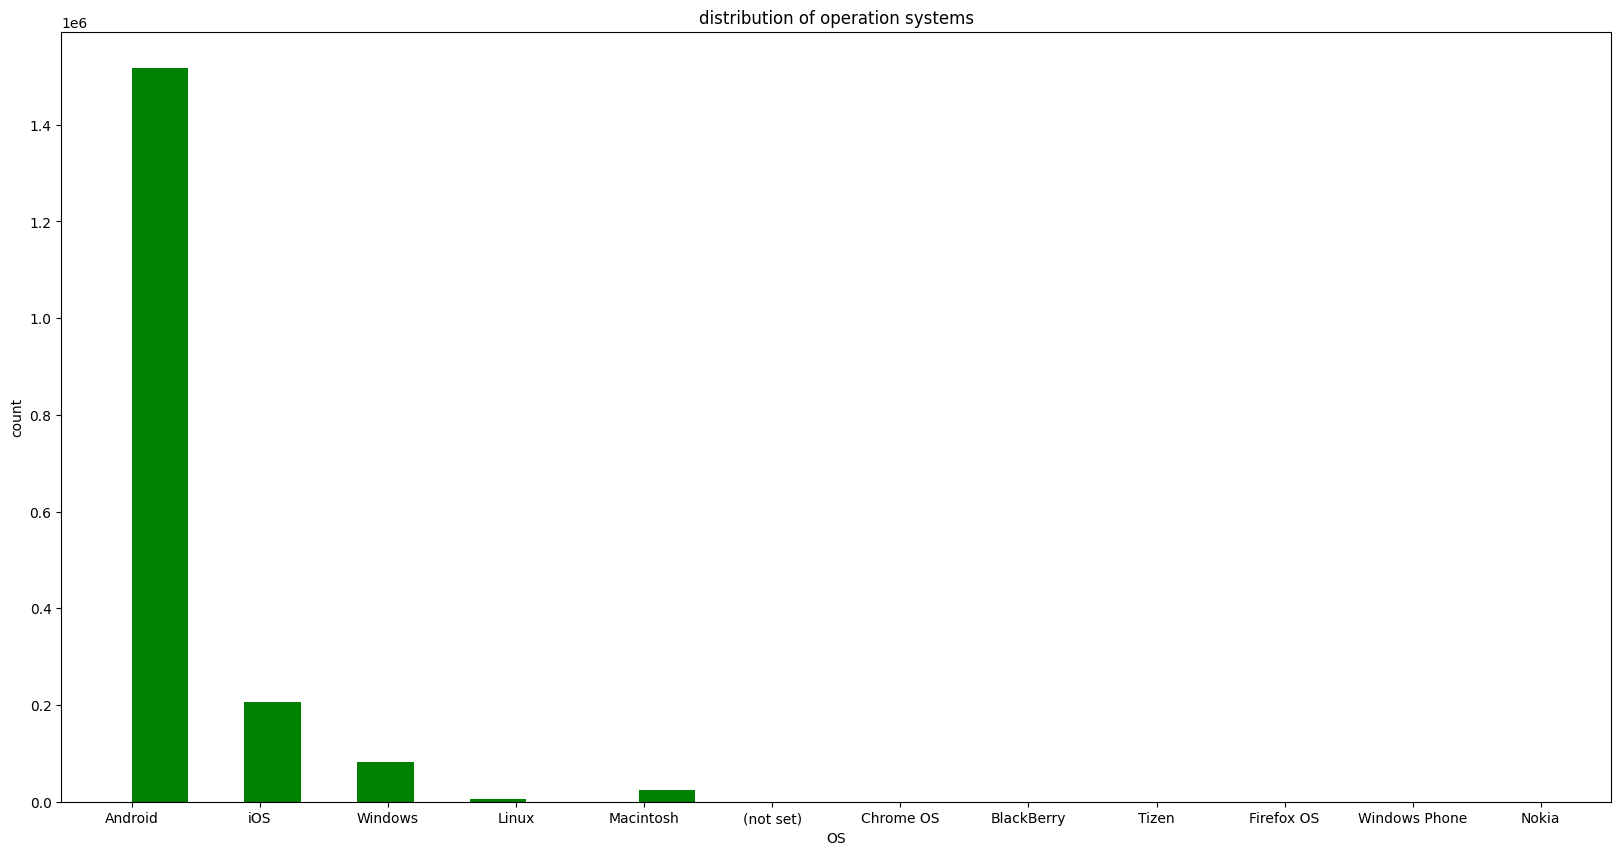

In [72]:
plt.figure(figsize=(20, 10))
plt.hist(dfs.device_os, bins=25, color='green')
plt.xlabel('OS')
plt.ylabel('count')
plt.title('distribution of operation systems')

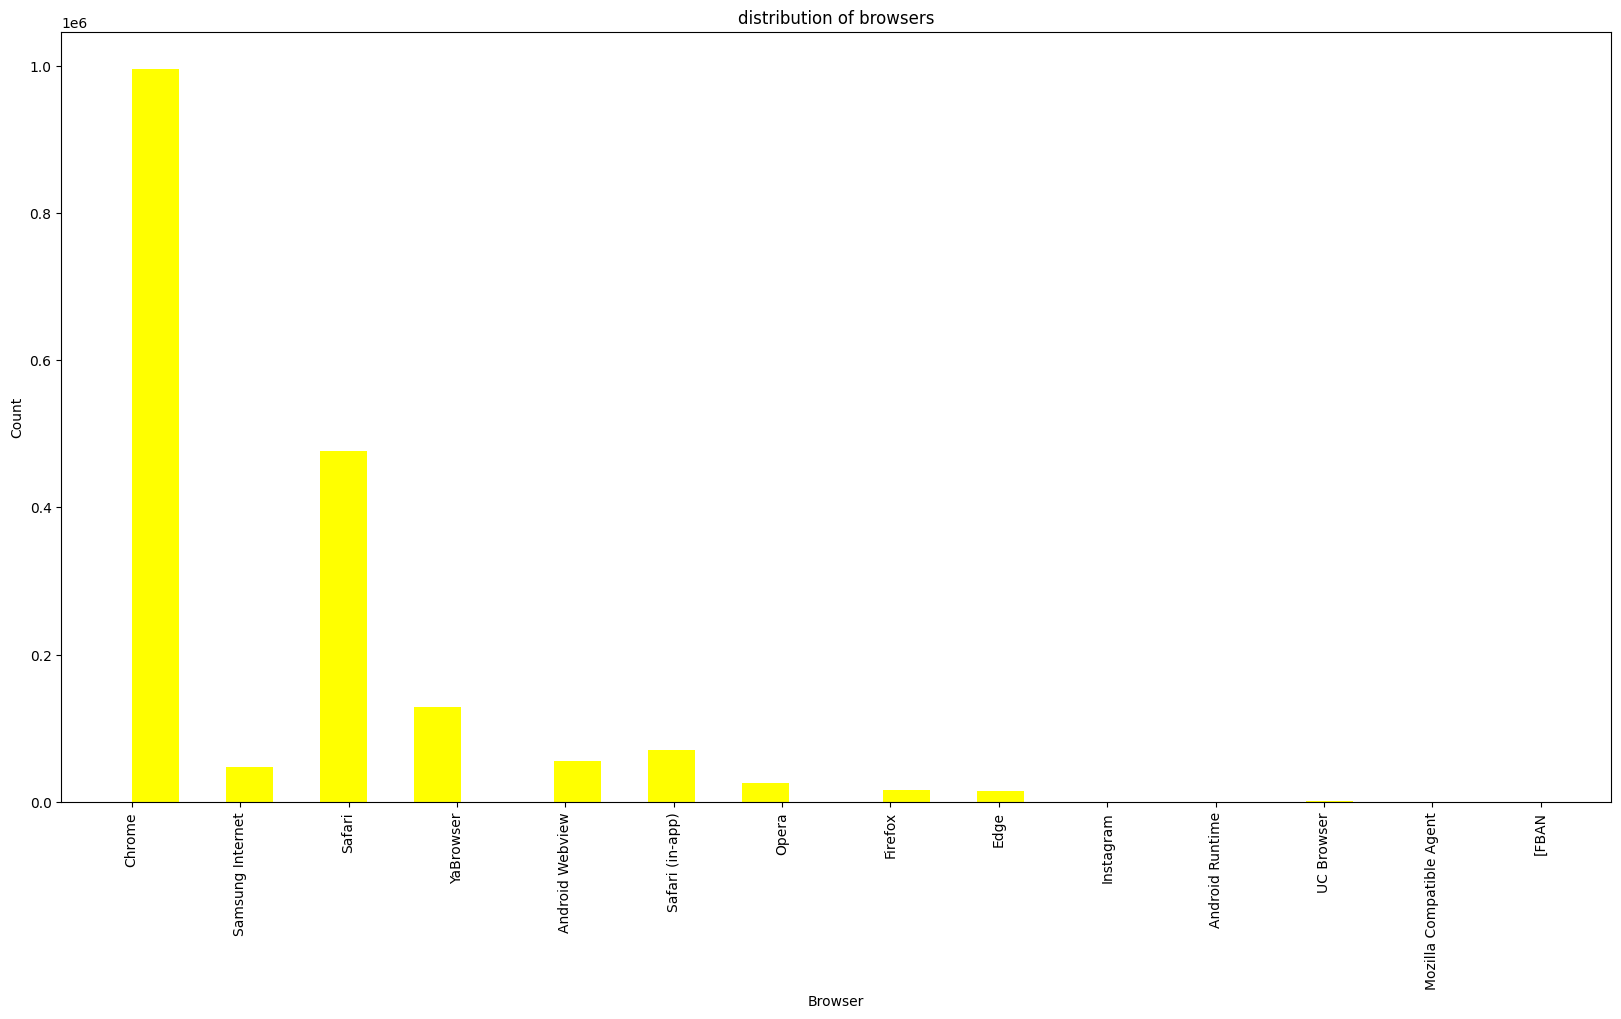

In [73]:
plt.figure(figsize=(20, 10))
plt.hist(dfs.device_browser, bins=30, color='yellow')
plt.xticks(rotation=90)
plt.xlabel('Browser')
plt.ylabel('Count')
plt.title('distribution of browsers')
plt.show()

### Анализ переменных utm_mediums и geo_country

In [74]:
dfs.utm_medium.unique()

<StringArray>
[           'banner',               'cpm',               'cpc',
           'organic',            '(none)',          'referral',
               'smm',           'stories',   'blogger_channel',
   'blogger_stories',             'email',               'app',
            'vk_smm',               'cpv',              'push',
           'partner',                'tg',               'cpa',
              'post',       'smartbanner',         'info_text',
           'outlook',            'clicks',           'landing',
    'blogger_header',                'qr',         '(not set)',
            'fb_smm',               'nkp',        'google_cpc',
               'sms',           'article',         'users_msk',
            'static',            'ok_smm',            'cbaafe',
      'Sbol_catalog', 'landing_interests',        'yandex_cpc',
         'web_polka',          'linktest',          'sber_app',
            'medium',            'tablet',        'promo_sbol',
             'reach',     

In [75]:
dfs.utm_medium.value_counts()

utm_medium
banner               551713
cpc                  425754
(none)               296313
cpm                  241799
referral             144754
organic               59937
email                 28884
push                  28026
stories               10535
cpv                    7979
blogger_channel        7824
smartbanner            6793
blogger_stories        4299
cpa                    4261
tg                     3908
app                    2812
post                   2322
smm                    1963
outlook                1181
clicks                  921
blogger_header          771
(not set)               387
info_text               343
sms                     212
landing                 129
partner                  97
fb_smm                   66
vk_smm                   65
cbaafe                   47
yandex_cpc               36
ok_smm                   28
static                   22
google_cpc               20
article                  16
nkp                      14
web_polka

Удалим те, что меньше 100

In [76]:
threshold_2 = 100

freq2 = dfs['utm_medium'].value_counts()
rare_browsers2 = freq2[freq2 < threshold_2].index

dfs = dfs[~dfs['utm_medium'].isin(rare_browsers2)]
dfs.utm_medium.value_counts()

utm_medium
banner             551713
cpc                425754
(none)             296313
cpm                241799
referral           144754
organic             59937
email               28884
push                28026
stories             10535
cpv                  7979
blogger_channel      7824
smartbanner          6793
blogger_stories      4299
cpa                  4261
tg                   3908
app                  2812
post                 2322
smm                  1963
outlook              1181
clicks                921
blogger_header        771
(not set)             387
info_text             343
sms                   212
landing               129
Name: count, dtype: int64

In [77]:
dfs.geo_country.value_counts()

geo_country
Russia                 1774892
United States            11657
Ukraine                   8929
Ireland                   3998
Belarus                   3635
                        ...   
Guernsey                     1
Equatorial Guinea            1
Kosovo                       1
Niger                        1
Congo - Brazzaville          1
Name: count, Length: 166, dtype: int64

Аналогично и здесь, но установим порог на 300

In [78]:
threshold_3 = 300

freq3 = dfs['geo_country'].value_counts()
rare_browsers3 = freq3[freq3 < threshold_3].index

dfs = dfs[~dfs['geo_country'].isin(rare_browsers3)]
dfs.geo_country.value_counts()

geo_country
Russia                  1774892
United States             11657
Ukraine                    8929
Ireland                    3998
Belarus                    3635
Sweden                     2657
Kazakhstan                 2272
Germany                    2216
Turkey                     1938
Uzbekistan                 1523
Netherlands                1463
United Kingdom             1451
(not set)                  1144
Kyrgyzstan                  974
Georgia                     931
France                      776
Cyprus                      756
Armenia                     673
Finland                     631
Spain                       599
Poland                      514
United Arab Emirates        472
Israel                      429
Tajikistan                  400
Moldova                     385
Latvia                      357
Italy                       355
Azerbaijan                  327
Egypt                       317
Greece                      310
Name: count, dtype: int64

#### Теперь можем построить графики

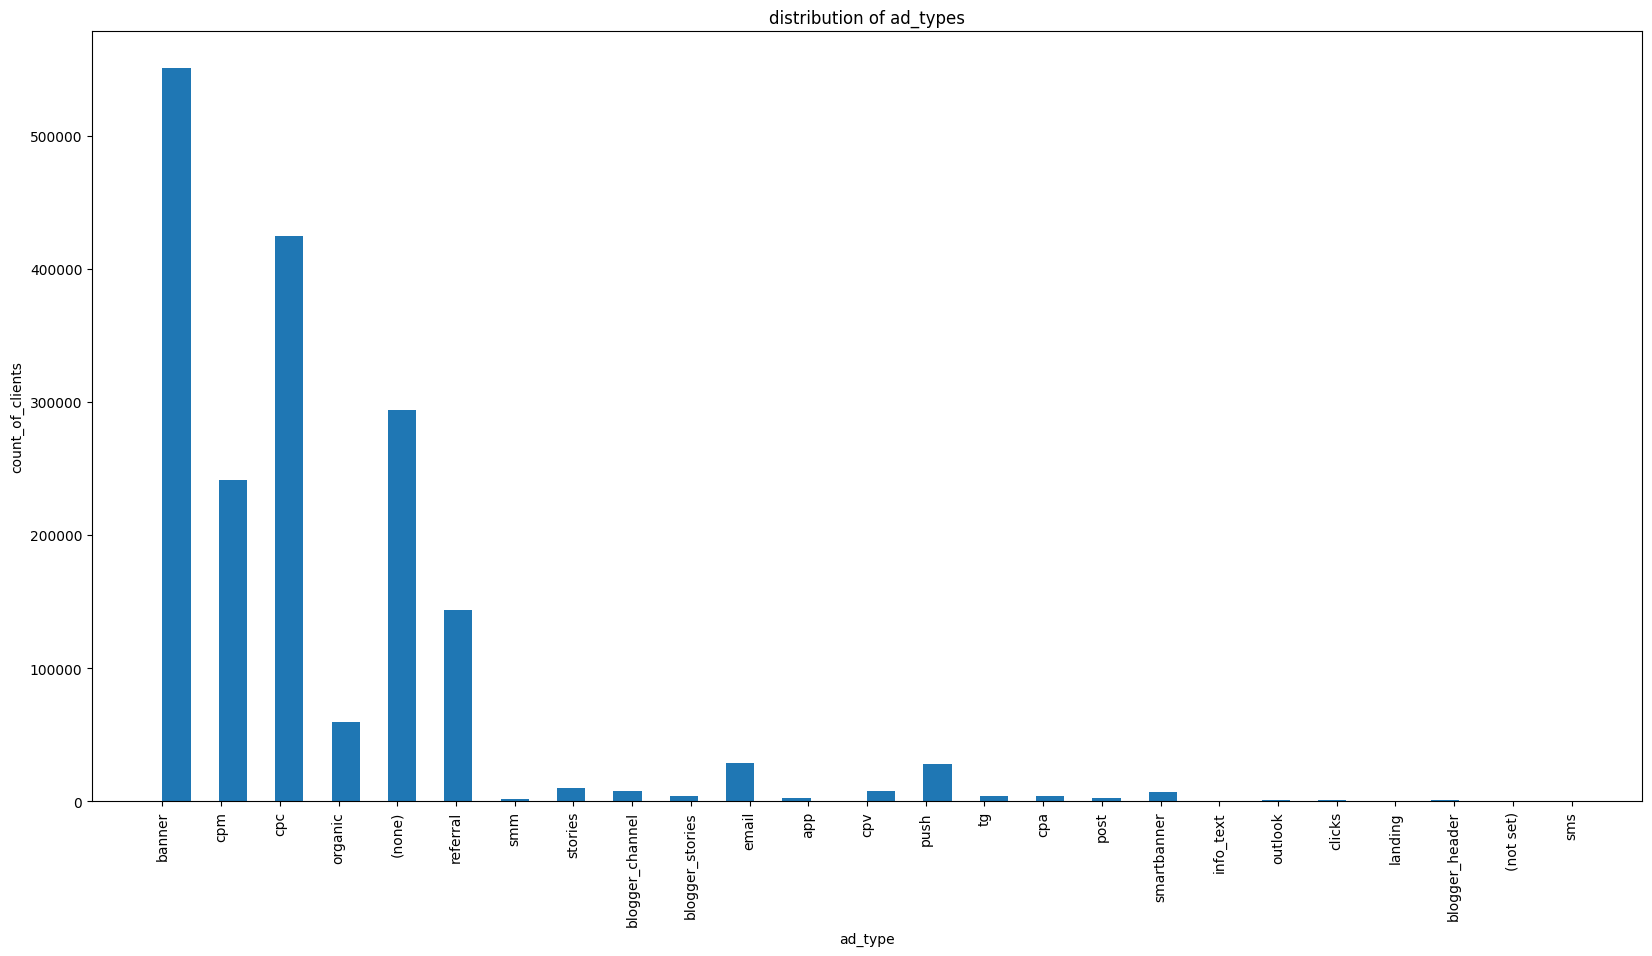

In [79]:
plt.figure(figsize=(20, 10))
plt.hist(dfs.utm_medium, bins=50)
plt.xticks(rotation=90)
plt.xlabel('ad_type')
plt.ylabel('count_of_clients')
plt.title('distribution of ad_types')
plt.show()

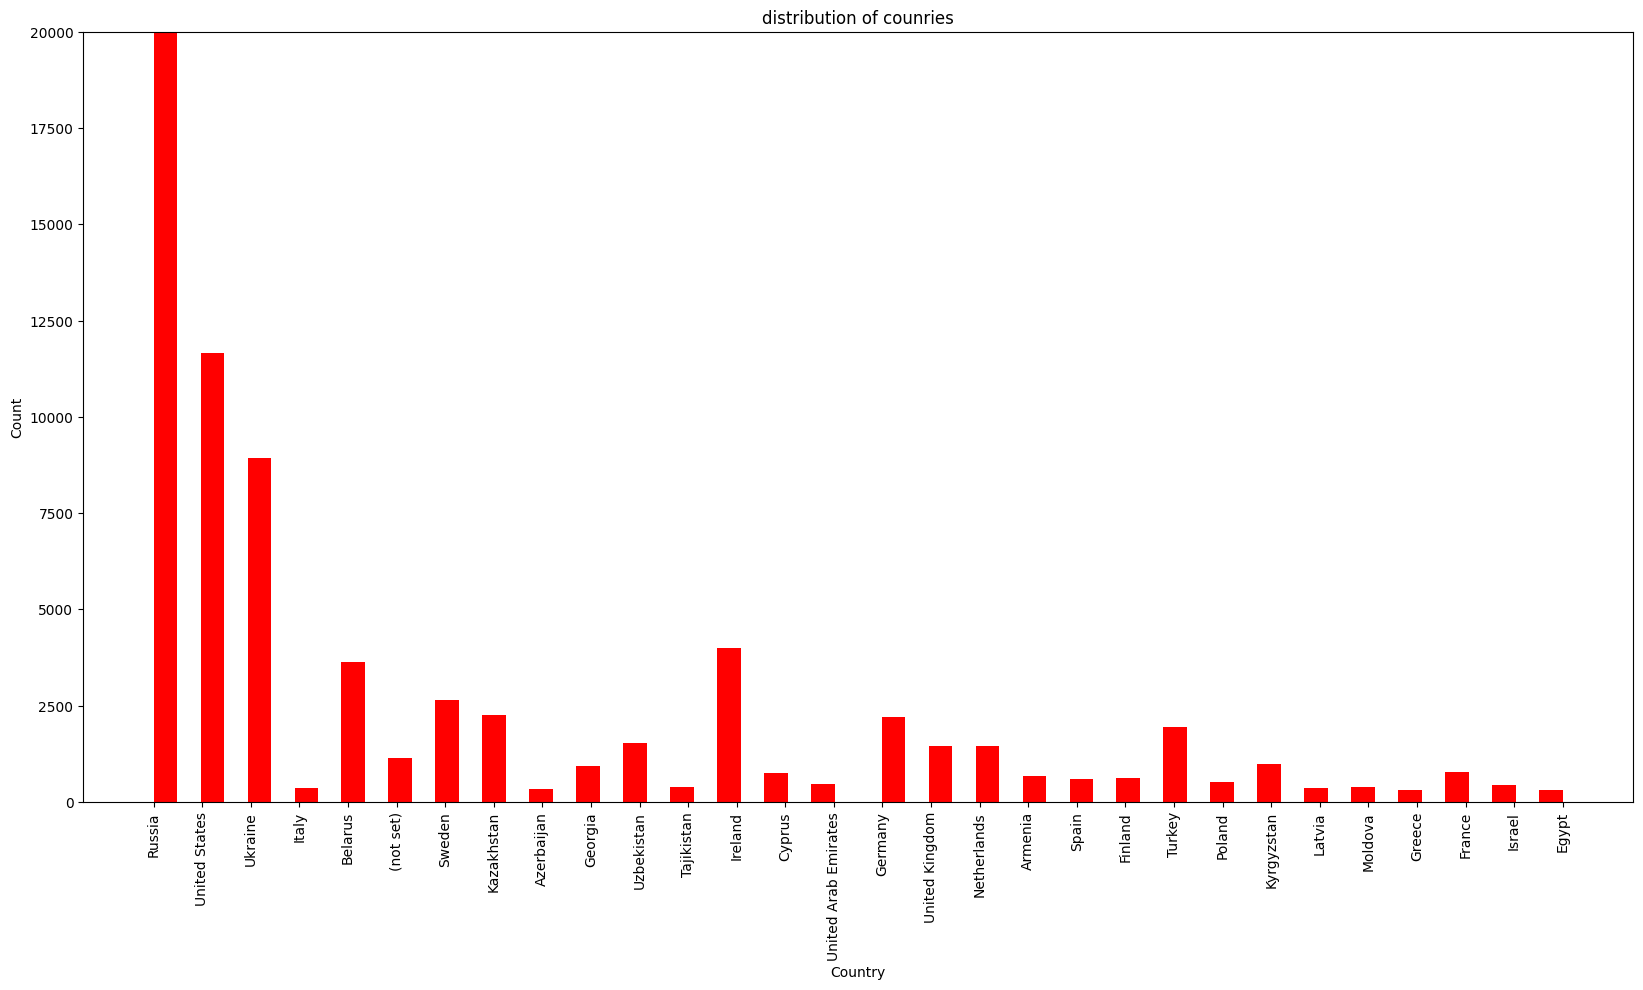

In [80]:
plt.figure(figsize=(20, 10))
plt.hist(dfs.geo_country, bins=60, color='red')
plt.xticks(rotation=90)
plt.ylim(0, 20000)
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('distribution of counries')
plt.show()

### Вывод по таблице


Основная аудитория компании проживает на территории Росси и бользуется в основном мобильными телефонами на базе Android. Браузер: Chrome, а лучшим способом привлечения являются баннеры и cpc.

Text(0.5, 1.0, 'distribution of ad_types in Russia')

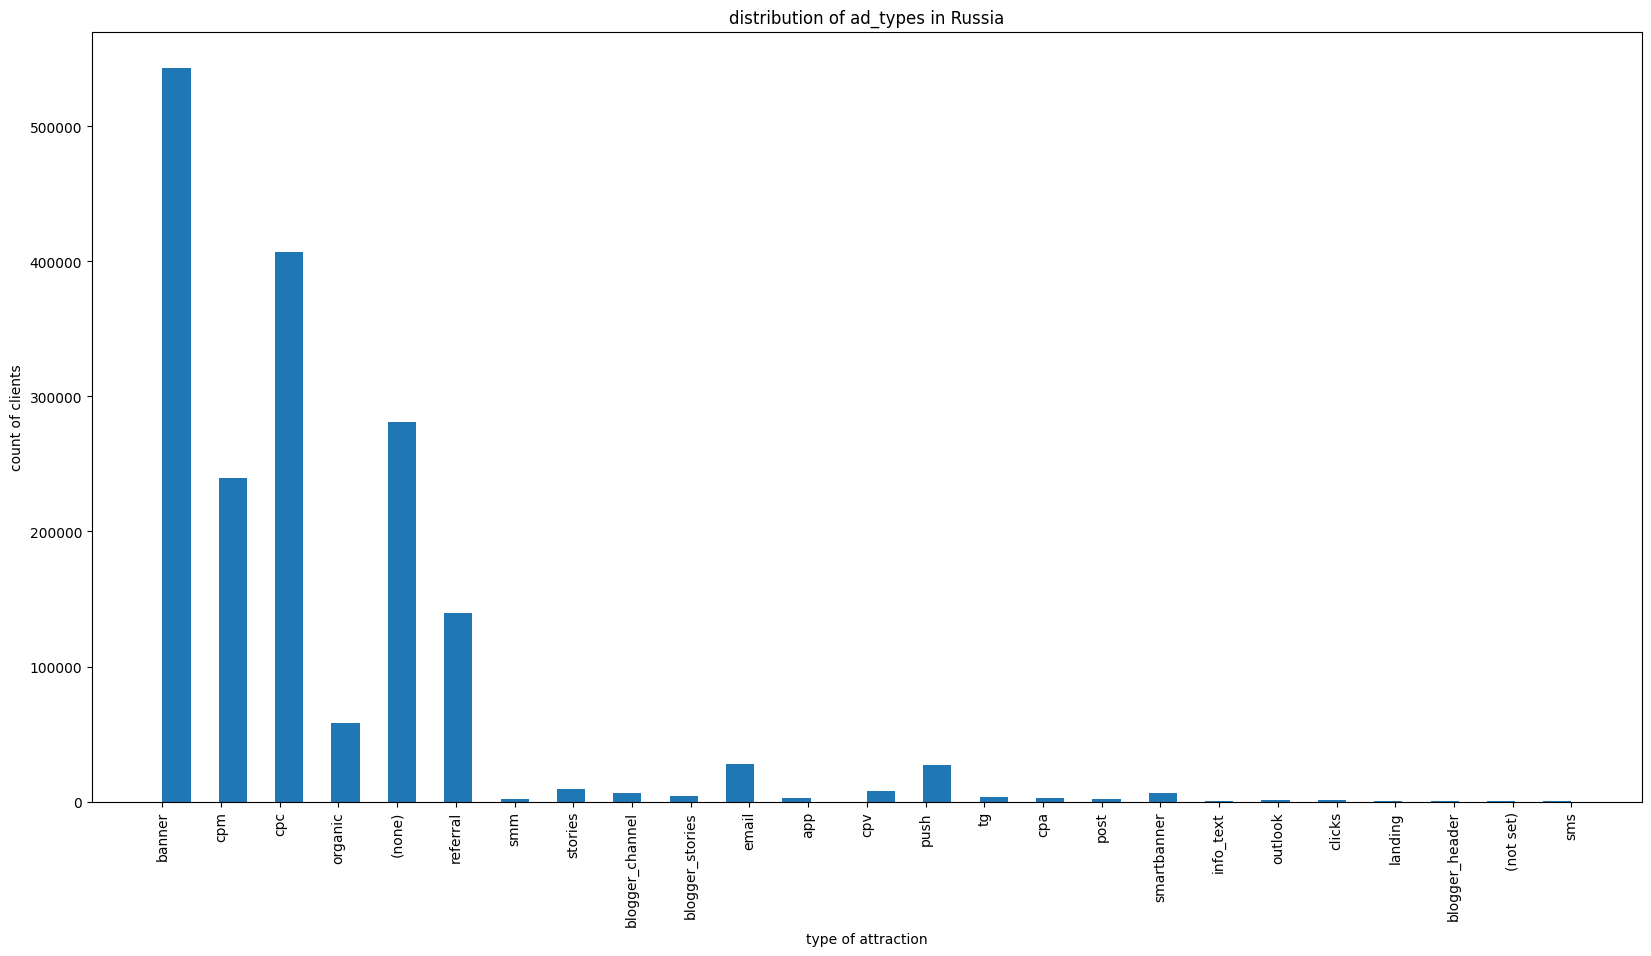

In [81]:
russia = dfs[dfs['geo_country'] == 'Russia']

plt.figure(figsize=(20, 10))
plt.hist(russia.utm_medium, bins=50)
plt.xticks(rotation=90)
plt.xlabel('type of attraction')
plt.ylabel('count of clients')
plt.title('distribution of ad_types in Russia')

Text(0.5, 1.0, 'distribution of browsers in Russia')

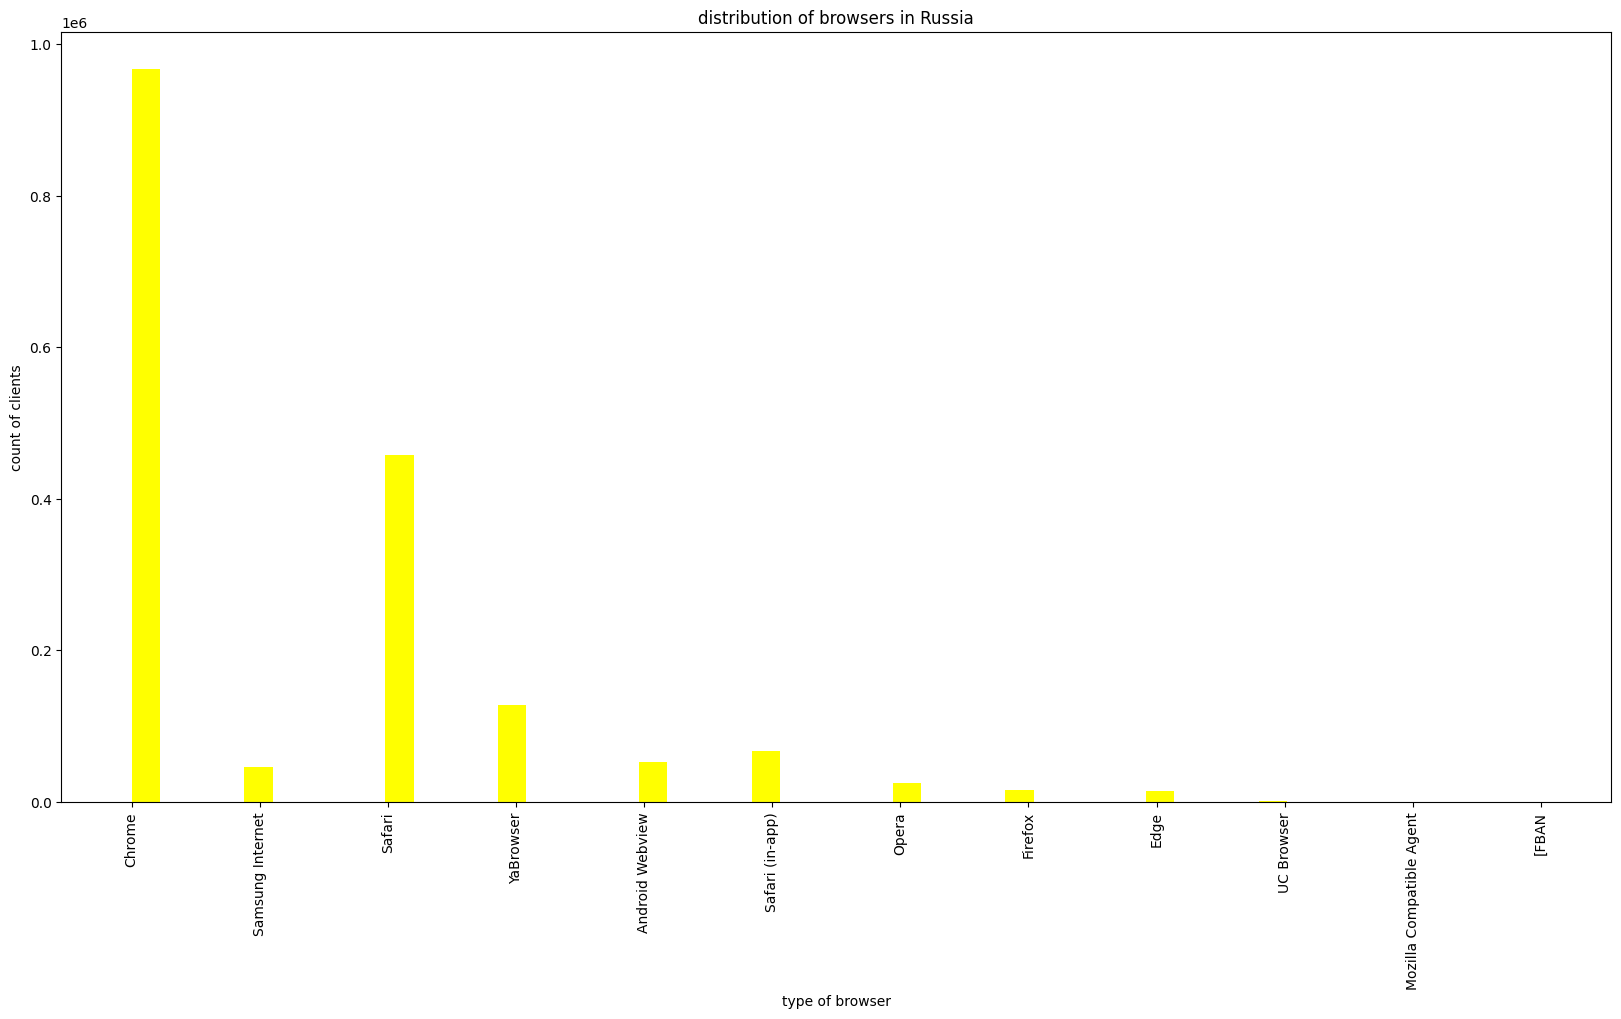

In [82]:
plt.figure(figsize=(20, 10))
plt.hist(russia.device_browser, bins=50, color='yellow')
plt.xticks(rotation=90)
plt.xlabel('type of browser')
plt.ylabel('count of clients')
plt.title('distribution of browsers in Russia')

Text(0.5, 1.0, 'distribution of OS types in Russia')

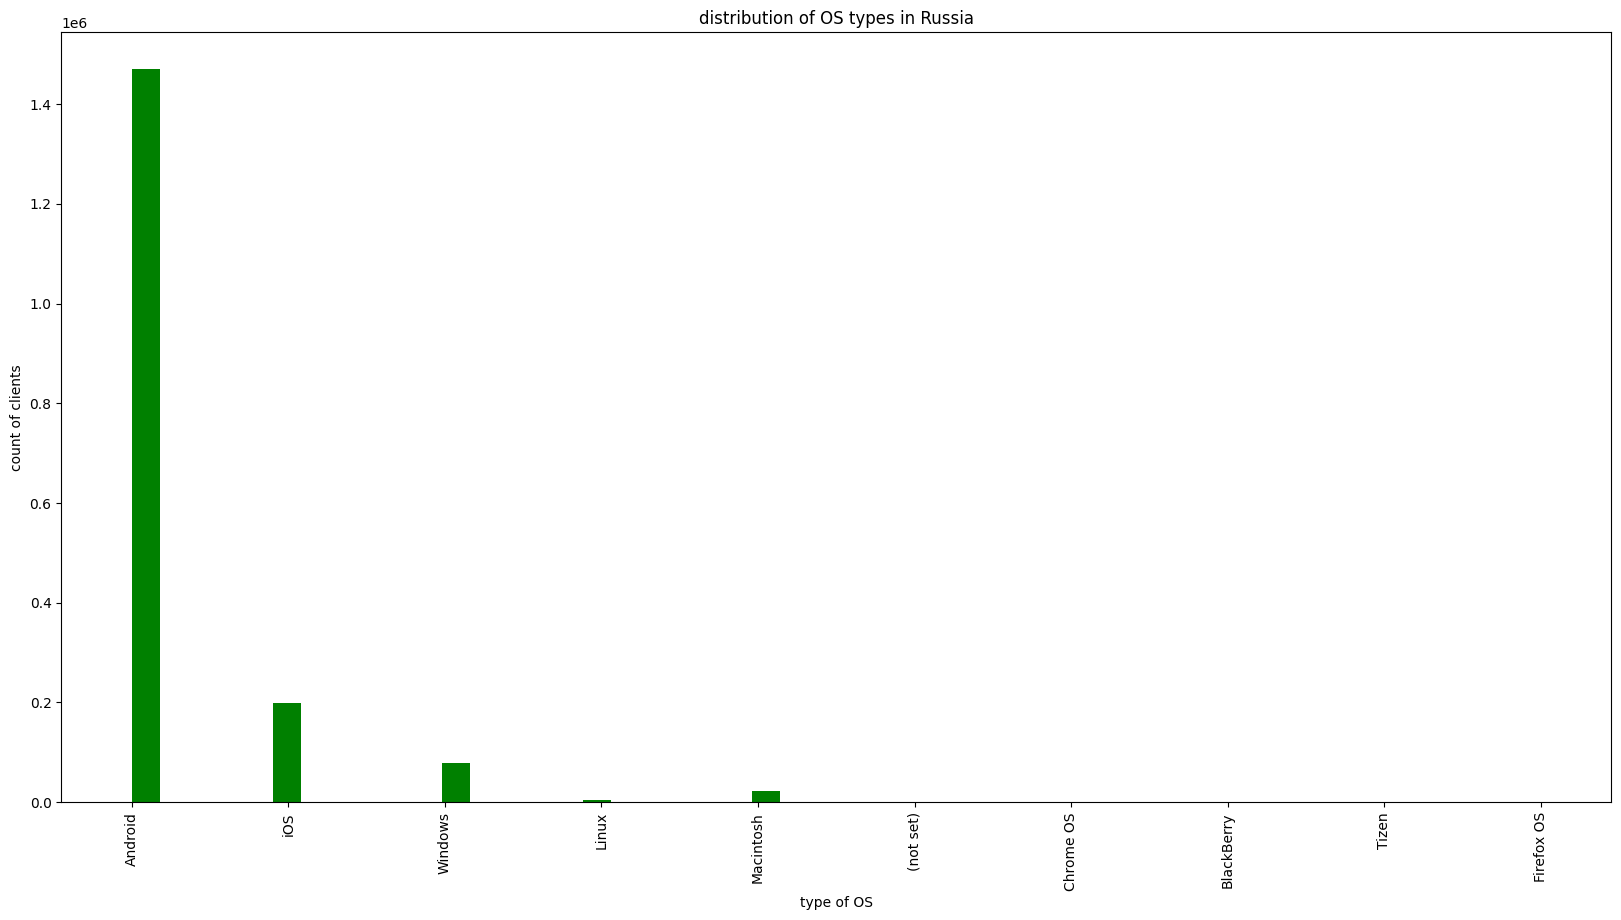

In [83]:
plt.figure(figsize=(20, 10))
plt.hist(russia.device_os, bins=50, color='green')
plt.xticks(rotation=90)
plt.xlabel('type of OS')
plt.ylabel('count of clients')
plt.title('distribution of OS types in Russia')

Таким образом для дальнейшего анализа и построенния моделей возьмём только Россию

In [84]:
new_dfs = dfs.copy()
new_dfs = new_dfs[new_dfs['geo_country'] == 'Russia']
new_dfs.shape

(1774892, 15)

## Анализ таблицы clean_ga_hits

In [85]:
df_hits = clean_hit_df
df_hits.head(5)

,session_id,hit_date,hit_time,hit_number,hit_referer,hit_page_path,event_category,event_action,event_label
0,5639623078712724064.1640254056.1640254056,2021-12-23,597864.0,30,unknown,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show,actionless
1,7750352294969115059.1640271109.1640271109,2021-12-23,597331.0,41,unknown,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show,actionless
2,885342191847998240.1640235807.1640235807,2021-12-23,796252.0,49,unknown,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show,actionless
3,142526202120934167.1640211014.1640211014,2021-12-23,934292.0,46,unknown,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show,actionless
5,6466333295973247896.1640246168.1640246168,2021-12-23,704194.0,41,unknown,sberauto.com/cars?utm_source_initial=youtube&u...,quiz,quiz_show,actionless


In [86]:
df_hits.info()

<class 'pandas.DataFrame'>
Index: 14664872 entries, 0 to 15726469
Data columns (total 9 columns):
 #   Column          Dtype         
---  ------          -----         
 0   session_id      str           
 1   hit_date        datetime64[us]
 2   hit_time        float64       
 3   hit_number      int64         
 4   hit_referer     str           
 5   hit_page_path   str           
 6   event_category  str           
 7   event_action    str           
 8   event_label     str           
dtypes: datetime64[us](1), float64(1), int64(1), str(6)
memory usage: 1.1 GB


### Выделим переменные для анализа

In [87]:
for col in df_hits.columns:
    print(f'{col}: {df_hits[col].nunique()}')

session_id: 1732062
hit_date: 226
hit_time: 750108
hit_number: 62
hit_referer: 37367
hit_page_path: 334715
event_category: 52
event_action: 228
event_label: 37414


Переменные для анализа: hit_number, event_category, event_action, hit_page_path(нужно обработать ссылки), hit_time. Остальное удаляем из датафрейма, т.к остальные данные не имеют значения (плюс hit_date можно будет получить после inner join-а)

In [88]:
fruitless = ['hit_referer', 'event_label', 'hit_date']
df_hits = df_hits.drop(fruitless, axis=1)
df_hits.head(5)

,session_id,hit_time,hit_number,hit_page_path,event_category,event_action
0,5639623078712724064.1640254056.1640254056,597864.0,30,sberauto.com/cars?utm_source_initial=google&ut...,quiz,quiz_show
1,7750352294969115059.1640271109.1640271109,597331.0,41,sberauto.com/cars/fiat?city=1&city=18&rental_c...,quiz,quiz_show
2,885342191847998240.1640235807.1640235807,796252.0,49,sberauto.com/cars/all/volkswagen/polo/e994838f...,quiz,quiz_show
3,142526202120934167.1640211014.1640211014,934292.0,46,sberauto.com/cars?utm_source_initial=yandex&ut...,quiz,quiz_show
5,6466333295973247896.1640246168.1640246168,704194.0,41,sberauto.com/cars?utm_source_initial=youtube&u...,quiz,quiz_show


In [89]:
df_hits.hit_page_path[3]

'sberauto.com/cars?utm_source_initial=yandex&utm_medium_initial=cpc&utm_campaign_initial=XHNUiSKKGTEpSAlaVMFQ|qngiJQKcRremsAJnZbvx&utm_content_initial=yXzSAJWSuRbYeLFyMVFl|FbLFbRPHmkXzRVZGVMml|xAEYTlJDbQNwQTLGxICQ|UfTTPxcoqsUGiUaNbCPg|lFpAoUqEvHoyZfCNRuCR|XHhwZeVQAlxBVPPTHGks|rjbbNGNkjGThUJNtsWZQ|SzHvtGAIoyKeoWyQATVI|ZIKCVYXYgRrZdwlVkEEf|HbolMJUevblAbkHClEQa|kqZPVvZmXADsCZxIQwbv|vnTlRpYmthtVDImMLSmr|OfdDOXSwHYclonQJpPxh|YhdYMAYSoTzDKQYzVVMr|HbolMJUevblAbkHClEQa&utm_term_initial=&city=1&rental_page=rental_only&rental_car=rental_only&city=18'

При прохождении по ссылке мы получаем ровно ничего. Нас просто перебрасывает на главную страницу. Это означает, что данные с подобными ссылками просто бесполезны. Оставим только те, где указанн бренд автомобиля.

### Анализируем сразу все переменные, но начинаем с event_category

In [90]:
df_hits.event_category.value_counts()

event_category
card_web                         6830409
search_form                      2279199
sub_page_view                    1942646
sub_button_click                 1030272
listing_ads                       959211
cars                              338940
sap_search_form                   332806
quiz                              246663
sap_search__form                  177489
auth                              169139
jivosite                           86129
chat                               70766
ad_banner                          38211
offers                             30201
navigation                         24997
footer                             19369
sub_submit                         16461
greenday_sub_button_click          15370
main_banners                       13303
scrolling_main_page                11132
profile_menu                       11007
active_invitation                   7910
header                              3273
my_idea                             2098
g

Сокращаем диапазон, удаляя незначительные куски данных

In [91]:
threshold_hit_1 = 10000

freq_hit = df_hits['event_category'].value_counts()
rare_cats = freq_hit[freq_hit < threshold_hit_1].index

df_hits = df_hits[~df_hits['event_category'].isin(rare_cats)]
df_hits.event_category.value_counts()

event_category
card_web                     6830409
search_form                  2279199
sub_page_view                1942646
sub_button_click             1030272
listing_ads                   959211
cars                          338940
sap_search_form               332806
quiz                          246663
sap_search__form              177489
auth                          169139
jivosite                       86129
chat                           70766
ad_banner                      38211
offers                         30201
navigation                     24997
footer                         19369
sub_submit                     16461
greenday_sub_button_click      15370
main_banners                   13303
scrolling_main_page            11132
profile_menu                   11007
Name: count, dtype: int64

Выделим только целевые действия, с которыми нам предстоит работать

In [92]:
df_hits.event_action.value_counts() # оставим без обработки редкий значений, т.к в них может оказаться целевое действие

event_action
view_card                   3272050
view_new_card               3257142
sub_landing                 1772090
go_to_car_card               895954
sub_view_cars_click          780606
                             ...   
sber_id_auth_error                2
from_credit_landing_pos           2
click_free_car_selection          1
continue in social                1
new_year_road_help_btn            1
Name: count, Length: 158, dtype: int64

Можем теперь окончательно сосредоточить данные

In [93]:
df_hits['brand'] = df_hits['hit_page_path'].str.extract(r'/cars/all/([^/?]+)', expand=False)
df_hits['brand']

0                     NaN
1                     NaN
2              volkswagen
3                     NaN
5                     NaN
                ...      
15726465           toyota
15726466    mercedes-benz
15726467           toyota
15726468              bmw
15726469              bmw
Name: brand, Length: 14643720, dtype: str

<Axes: >

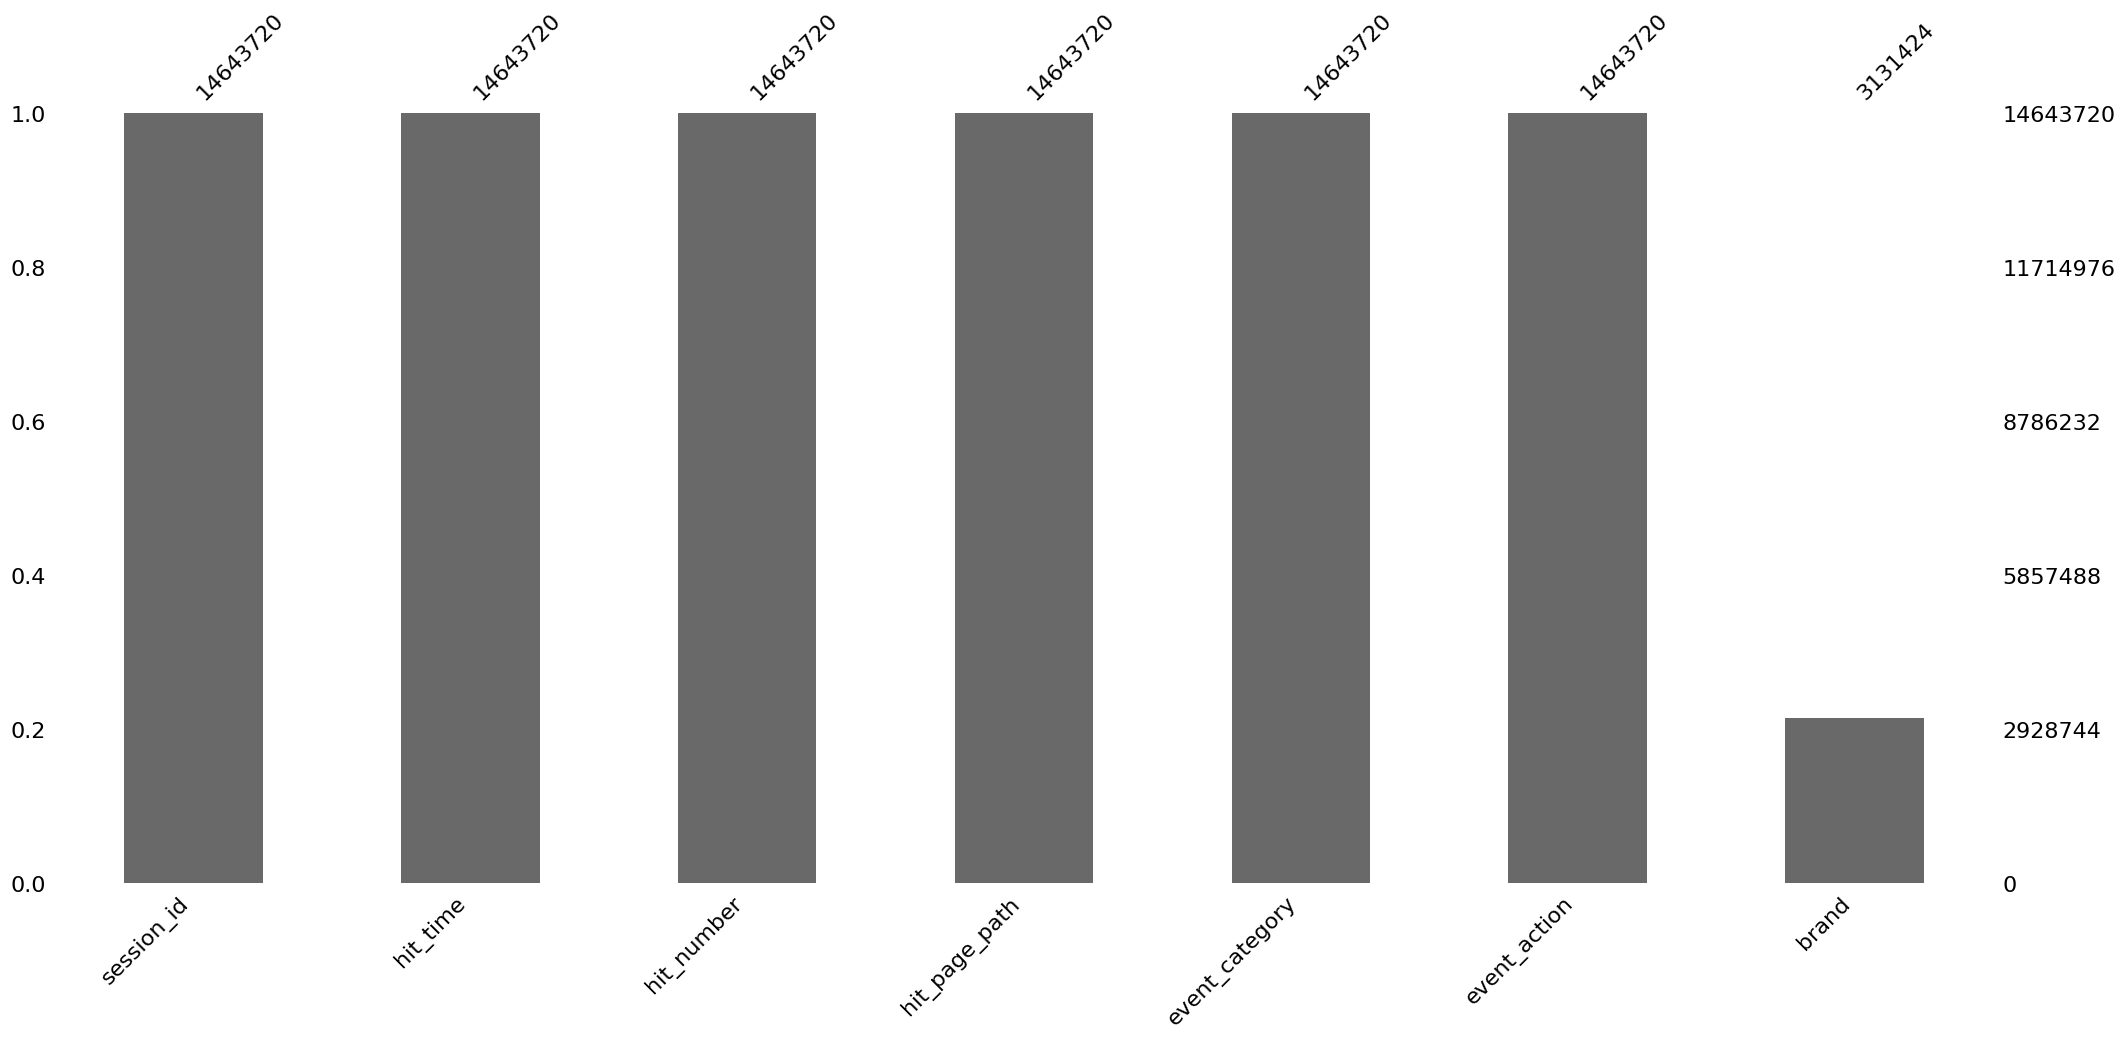

In [94]:
msno.bar(df_hits)

Выбираем данные, в которых есть бренд (если нет бренда, то данные бесполезны для анализа). Целевых действий не будет без бренда

In [95]:
df_hits_clean = df_hits.copy().dropna()
df_hits_clean.shape

(3131424, 7)

<Axes: >

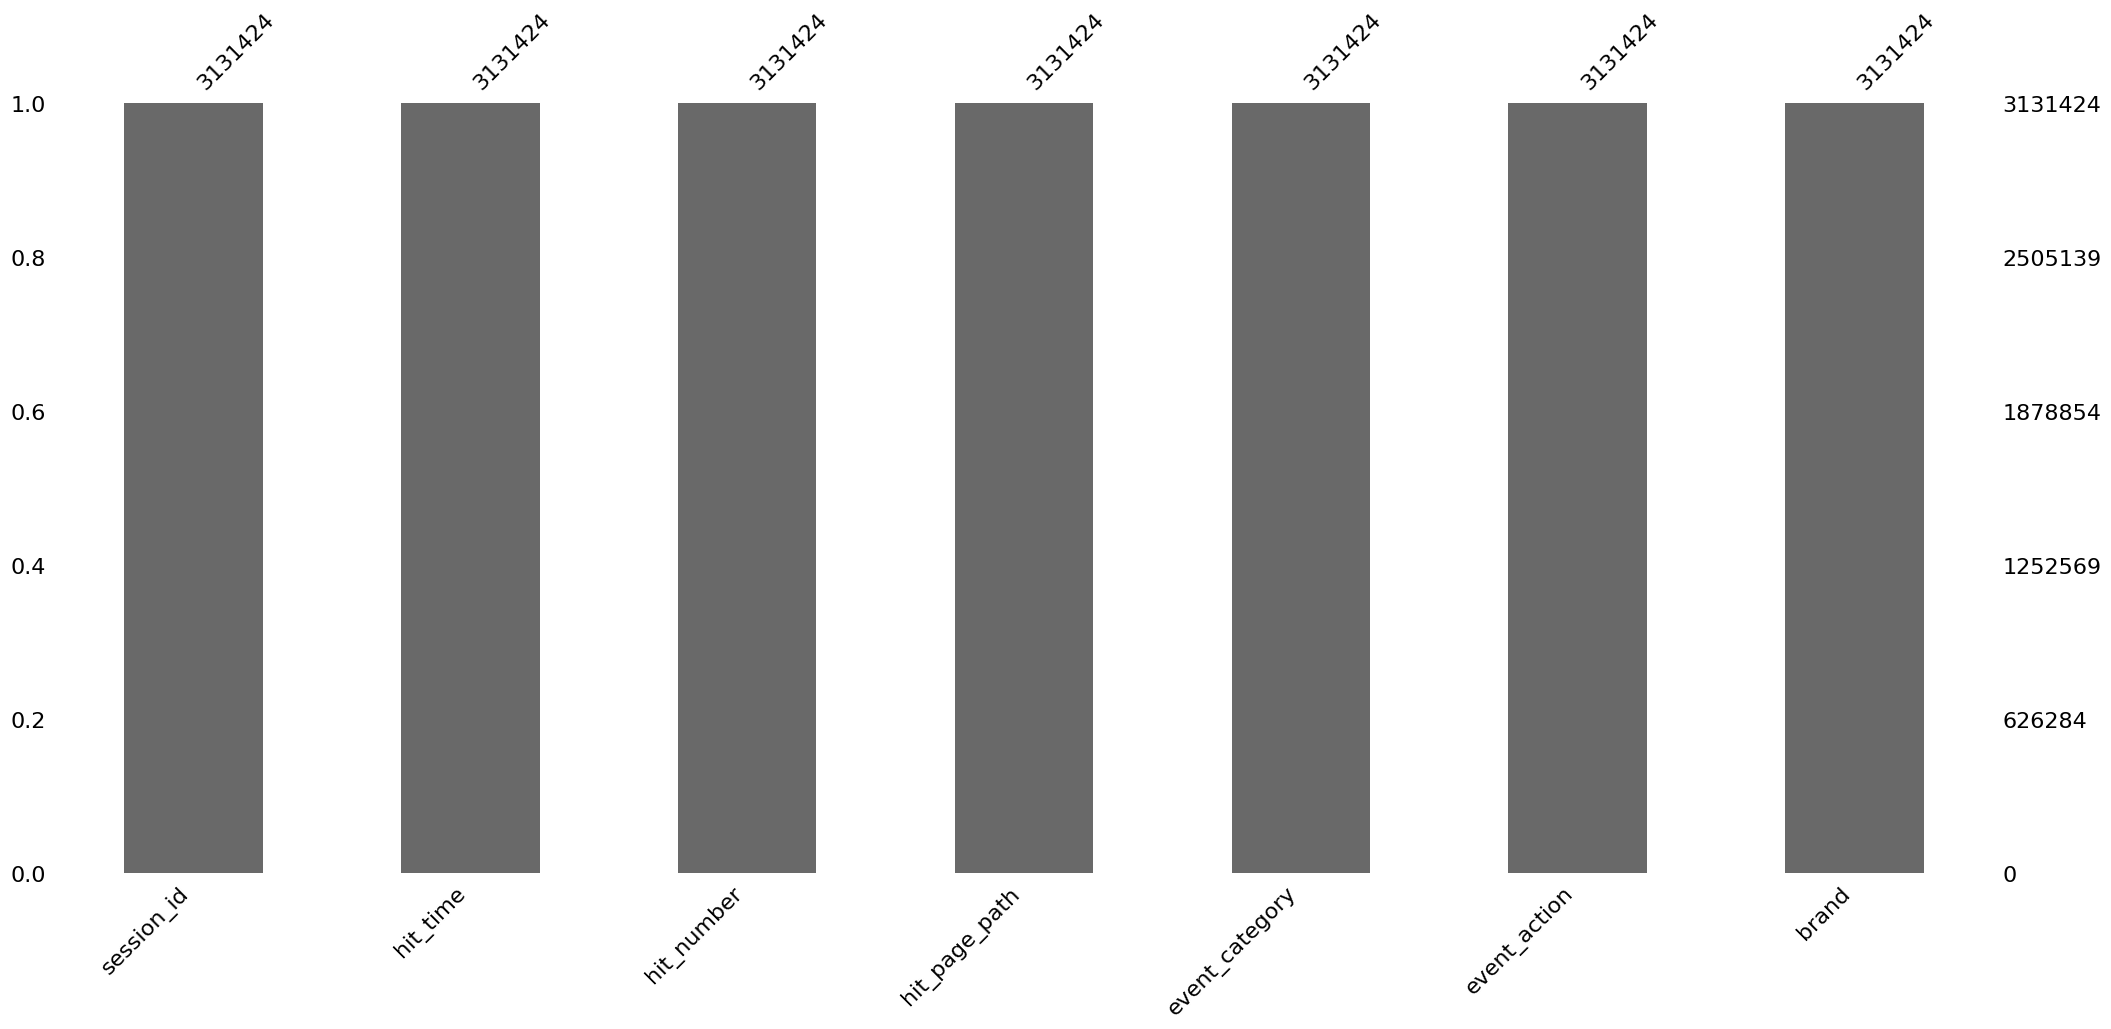

In [96]:
msno.bar(df_hits_clean)

### Строим графики распределений

Text(0.5, 1.0, 'distribution of brands')

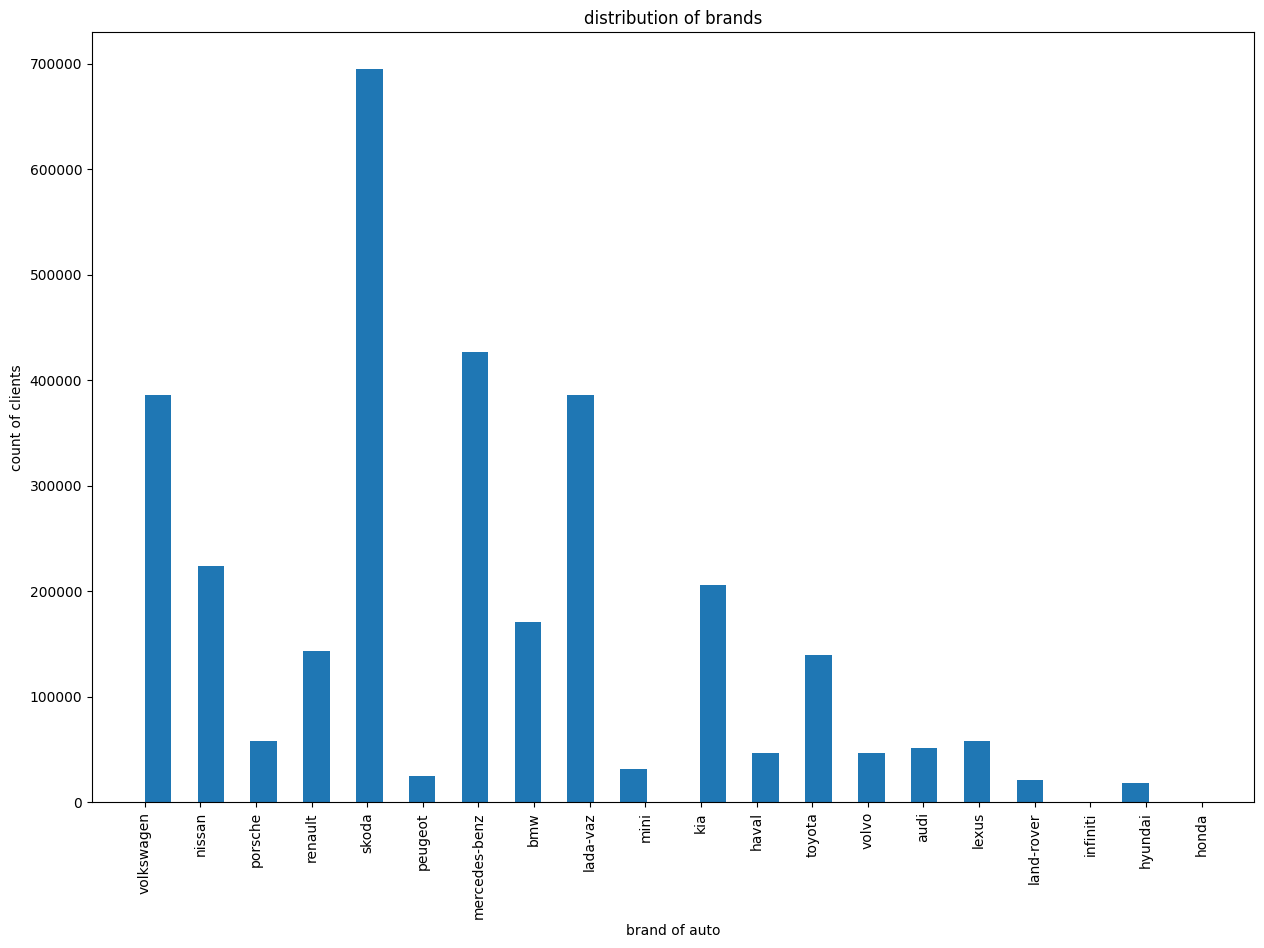

In [97]:
plt.figure(figsize=(15, 10))
plt.hist(df_hits_clean.brand, bins=40)
plt.xticks(rotation=90)
plt.xlabel('brand of auto')
plt.ylabel('count of clients')
plt.title('distribution of brands')

По графику видно, что самыми популярными автомобилями являются skoda, volkswagen, mercedes-benz и lada-vaz

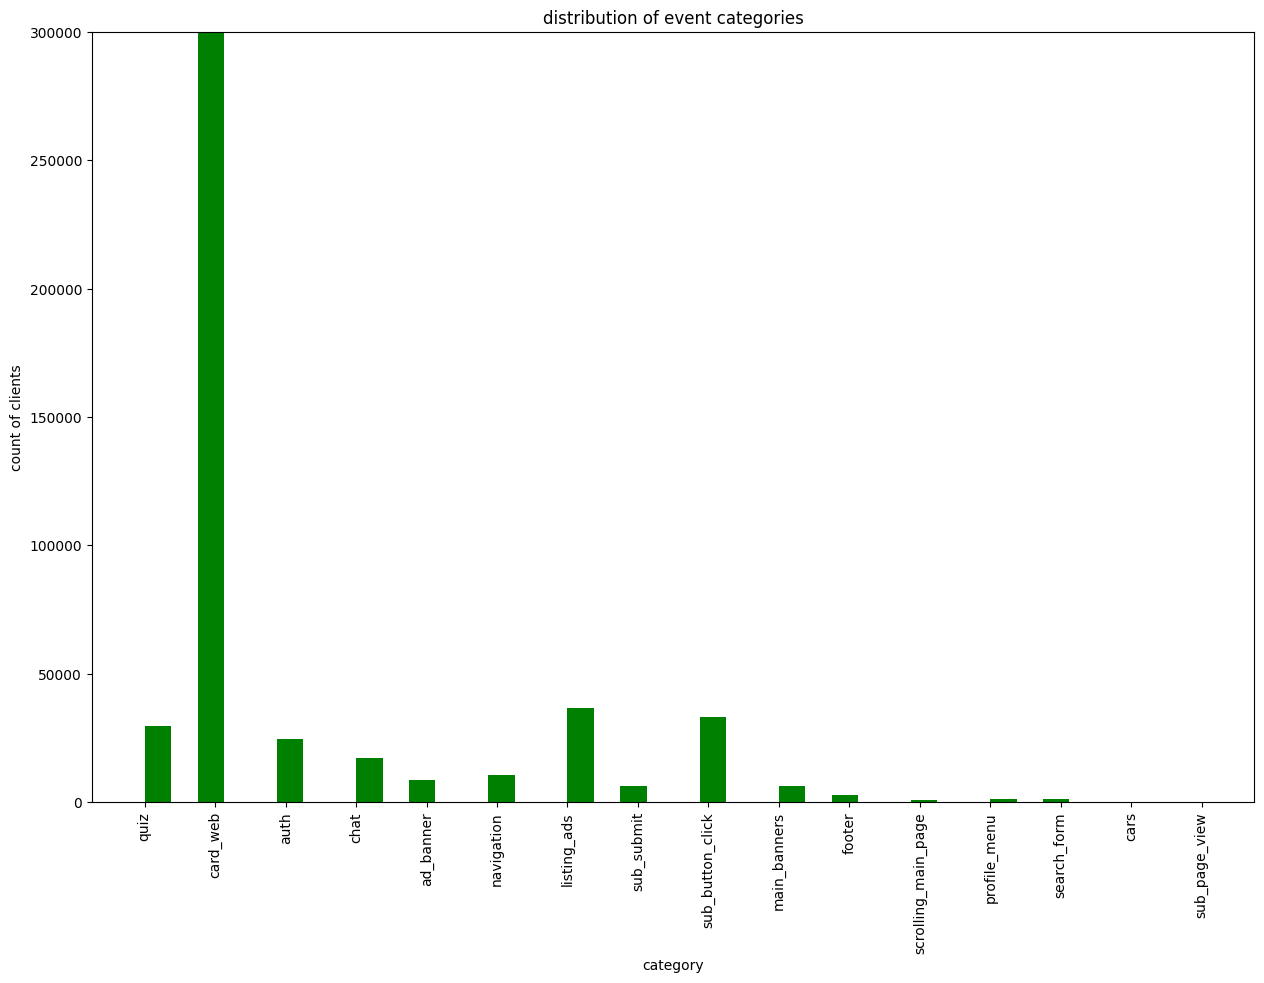

In [98]:
plt.figure(figsize=(15, 10))
plt.hist(df_hits_clean.event_category, bins=40, color='green')
plt.xticks(rotation=90)
plt.ylim((0, 300000))
plt.xlabel('category')
plt.ylabel('count of clients')
plt.title('distribution of event categories')
plt.show()

## Объединение таблиц в окончательный датафрейм и его анализ

In [99]:
df = pd.merge(new_dfs, df_hits_clean, on='session_id', how='left')
df.shape

(4466560, 21)

<Axes: >

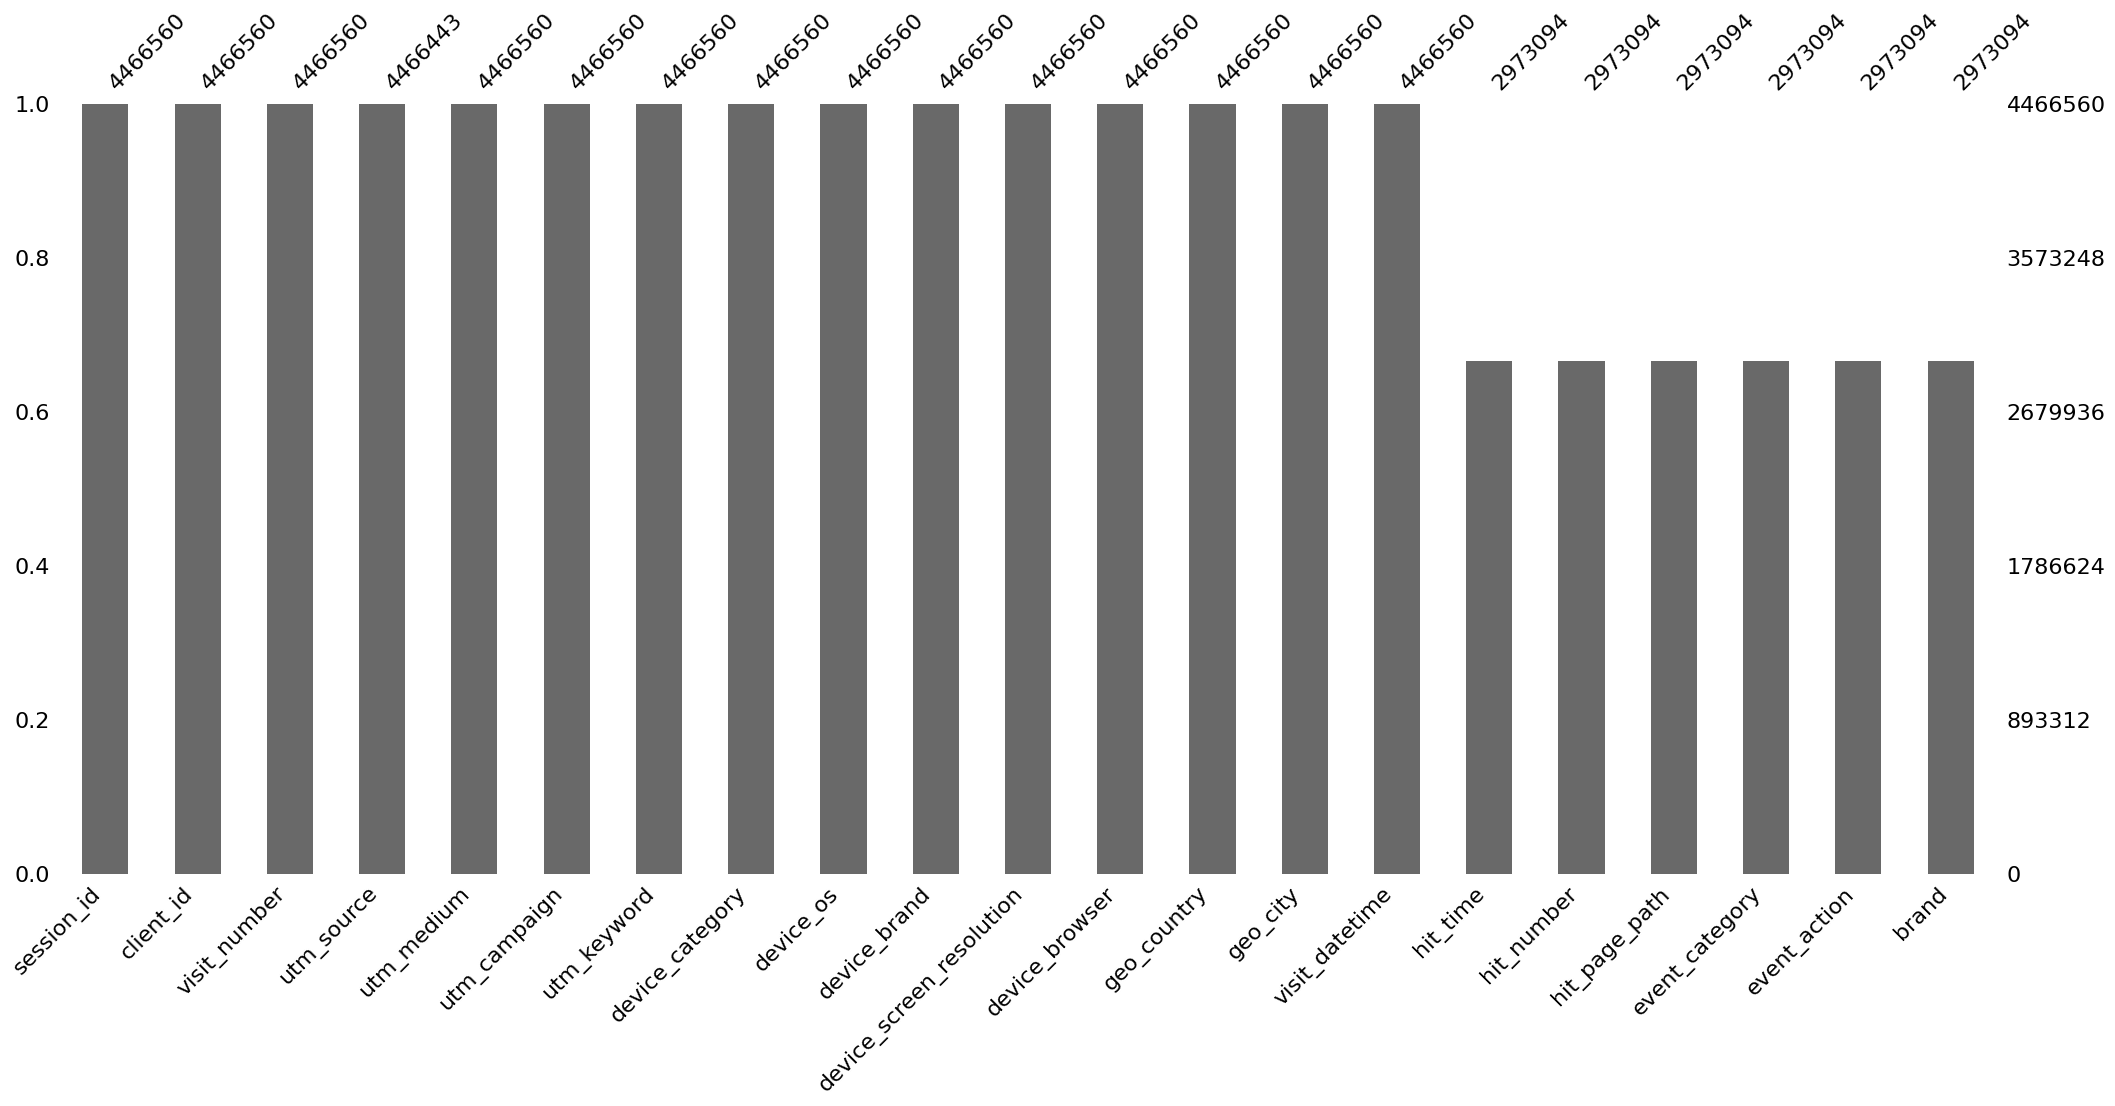

In [100]:
msno.bar(df)

In [101]:
df.head(10)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,...,device_browser,geo_country,geo_city,visit_datetime,hit_time,hit_number,hit_page_path,event_category,event_action,brand
0,9055434745589932991.1637753792.1637753792,2108382700.1637753791,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,...,Chrome,Russia,Zlatoust,2021-11-24 14:36:32,NaN,NaN,NaN,NaN,NaN,NaN
1,905544597018549464.1636867290.1636867290,210838531.1636867288,1,MvfHsxITijuriZxsqZqt,cpm,FTjNLDyTrXaWYgZymFkV,IGUCNvHlhfHpROGclCit,mobile,Android,Samsung,...,Samsung Internet,Russia,Moscow,2021-11-14 08:21:30,NaN,NaN,NaN,NaN,NaN,NaN
2,9055446045651783499.1640648526.1640648526,2108385331.1640648523,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,Android,Huawei,...,Chrome,Russia,Krasnoyarsk,2021-12-28 02:42:06,NaN,NaN,NaN,NaN,NaN,NaN
3,9055447046360770272.1622255328.1622255328,2108385564.1622255328,1,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,Android,Xiaomi,...,Chrome,Russia,Moscow,2021-05-29 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN
4,9055447046360770272.1622255345.1622255345,2108385564.1622255328,2,kjsLglQLzykiRbcDiGcD,cpc,campaignless,keywordless,mobile,Android,Xiaomi,...,Chrome,Russia,Moscow,2021-05-29 05:00:00,NaN,NaN,NaN,NaN,NaN,NaN
5,9055447192389856083.1622453074.1622453074,2108385598.1622453075,1,kjsLglQLzykiRbcDiGcD,organic,LTuZkdKfxRGVceoWkVyg,keywordless,mobile,Android,Apple,...,Safari,Russia,Saint Petersburg,2021-05-31 12:00:00,NaN,NaN,NaN,NaN,NaN,NaN
6,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,45.0,3.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
7,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,485.0,7.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda
8,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,550.0,8.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
9,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,484.0,5.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda


Пропуски заполнить мы не можем, берём только те данные, которые без пропусков

In [102]:
df_clean = df.copy().dropna()
df_clean.head(10)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,...,device_browser,geo_country,geo_city,visit_datetime,hit_time,hit_number,hit_page_path,event_category,event_action,brand
6,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,45.0,3.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
7,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,485.0,7.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda
8,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,550.0,8.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
9,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,484.0,5.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
10,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,45.0,4.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda
11,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,484.0,6.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda
13,9055462349345527315.1638536723.1638536723,2108389127.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,...,Safari,Russia,Moscow,2021-12-03 16:05:23,165771.0,16.0,sberauto.com/cars/all/toyota/camry/f28947a1?re...,card_web,view_card,toyota
14,9055462349345527315.1638536723.1638536723,2108389127.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,...,Safari,Russia,Moscow,2021-12-03 16:05:23,164983.0,13.0,sberauto.com/cars/all/toyota/camry/f28947a1?re...,card_web,view_card,toyota
15,9055462349345527315.1638536723.1638536723,2108389127.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,...,Safari,Russia,Moscow,2021-12-03 16:05:23,165010.0,14.0,sberauto.com/cars/all/toyota/camry/f28947a1?re...,card_web,view_new_card,toyota
16,9055462349345527315.1638536723.1638536723,2108389127.1638536723,1,ZpYIoDJMcFzVoPFsHGJL,banner,LEoPHuyFvzoNfnzGgfcd,puhZPIYqKXeFPaUviSjo,mobile,iOS,Apple,...,Safari,Russia,Moscow,2021-12-03 16:05:23,166345.0,17.0,sberauto.com/cars/all/toyota/camry/f28947a1?re...,card_web,view_card,toyota


In [103]:
df_clean.shape

(2973007, 21)

Вполне не плохо, теперь можно проводить анализ, строя графики

### Строим графики. Общая картина

In [104]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2973007 entries, 6 to 4466559
Data columns (total 21 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                str           
 1   client_id                 str           
 2   visit_number              int64         
 3   utm_source                str           
 4   utm_medium                str           
 5   utm_campaign              str           
 6   utm_keyword               str           
 7   device_category           str           
 8   device_os                 str           
 9   device_brand              str           
 10  device_screen_resolution  str           
 11  device_browser            str           
 12  geo_country               str           
 13  geo_city                  str           
 14  visit_datetime            datetime64[us]
 15  hit_time                  float64       
 16  hit_number                float64       
 17  hit_page_path           

Вот какие зависимости можно посмотреть: brand & utm_medium, brand & geo_city, event_action & utm_medium, hit_number & event_action, visit_number & event_action

#### Графики с целевыми переменными (event_action)

In [105]:
df_clean.utm_medium.unique()

<StringArray>
[            'cpc',          'banner',        'referral',          '(none)',
             'cpm',           'email',         'organic',             'cpa',
            'push',       'info_text',     'smartbanner',         'outlook',
 'blogger_channel',          'clicks', 'blogger_stories',            'post',
              'tg',             'smm',  'blogger_header',       '(not set)',
             'sms',             'app',             'cpv',         'stories',
         'landing']
Length: 25, dtype: str

In [106]:
df_clean.event_action.unique()

<StringArray>
[                       'view_new_card',
                            'view_card',
                           'photos_all',
                               'photos',
                       'go_to_car_card',
                   'sub_submit_success',
           'sub_car_claim_submit_click',
                  'sub_car_claim_click',
                'click_on_subscription',
                         'analystlabel',
 ...
 'sber_id_auth_show_deactivation_popup',
              'sber_id_auth_back_error',
                        'go_to_support',
                         'search_km_to',
       'new_year_road_help_banner_show',
                          'sub_landing',
     'show_plug_entered_six_months_ago',
                     'tap_on_phone_800',
   'sber_id_auth_click_on_deactivation',
                      'search_power_to']
Length: 106, dtype: str

Сколько целевых действий приходится на каждый метод подачи рекламы?

In [107]:
curr = df_clean[df_clean['event_action'].isin([
    'sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click', 
    'sub_submit_success', 'sub_car_request_submit_click'
])]
stats = curr.groupby(['utm_medium'], as_index=False)[['event_action']].count()
stats = stats.rename(columns={'event_action': 'count_of_actions'})
stats.head(5)

,utm_medium,count_of_actions
0,(none),2239
1,(not set),10
2,app,23
3,banner,11996
4,blogger_channel,14


Text(0.5, 1.0, 'Depending between utm_medium and count of action')

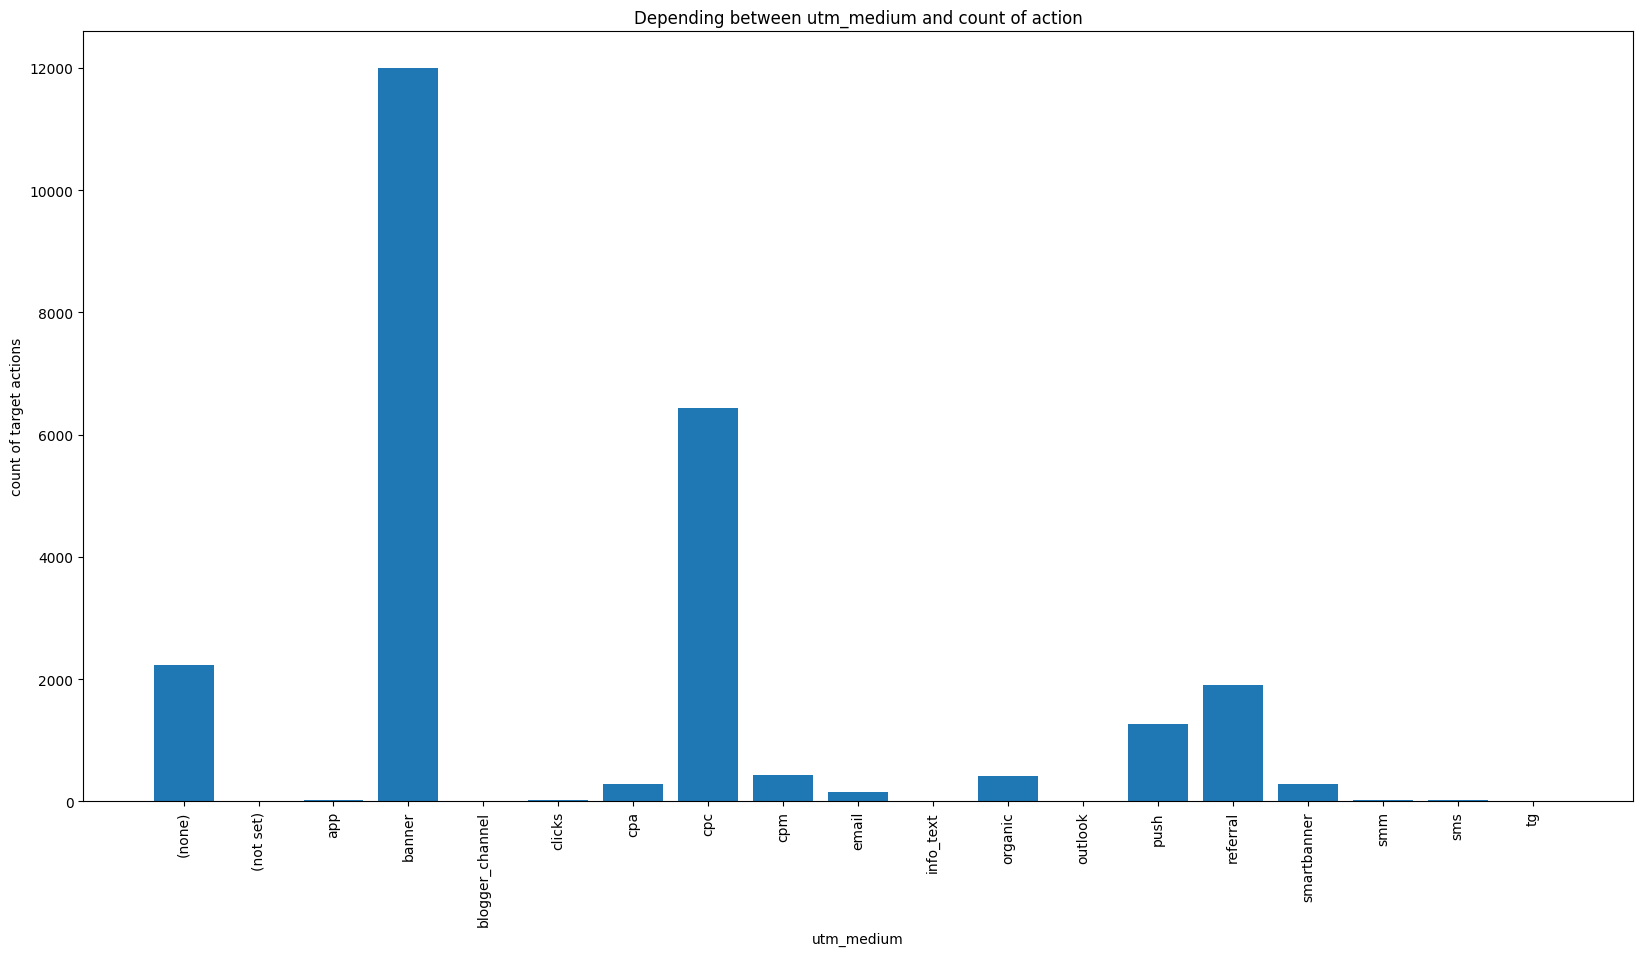

In [108]:
plt.figure(figsize=(20, 10))
plt.bar(stats['utm_medium'], stats['count_of_actions'])
plt.xticks(rotation=90)
plt.xlabel('utm_medium')
plt.ylabel('count of target actions')
plt.title('Depending between utm_medium and count of action')

С какого нажатия совершаются действия?

In [109]:
df_clean.hit_number.unique()

array([ 3.,  7.,  8.,  5.,  4.,  6., 16., 13., 14., 17., 18., 15., 39.,
       34., 33., 36., 37., 38., 35., 12., 55., 29., 58., 28., 44., 56.,
       27., 26., 57., 25., 59., 42., 45., 40., 61., 41., 24., 23., 60.,
       43.,  9., 11., 10., 52., 54., 62., 32., 22., 53., 31., 30., 20.,
       21.,  2., 49., 46., 50., 51., 19.,  1., 48., 47.])

In [110]:
stats_hits = curr.groupby(['hit_number'], as_index=False)[['event_action']].count()
stats_hits = stats_hits.rename(columns={'event_action': 'count_of_actions'})
stats_hits.head(5)

,hit_number,count_of_actions
0,1.0,99
1,2.0,79
2,3.0,80
3,4.0,53
4,5.0,39


Text(0.5, 1.0, 'Depending between hit_number and count of action')

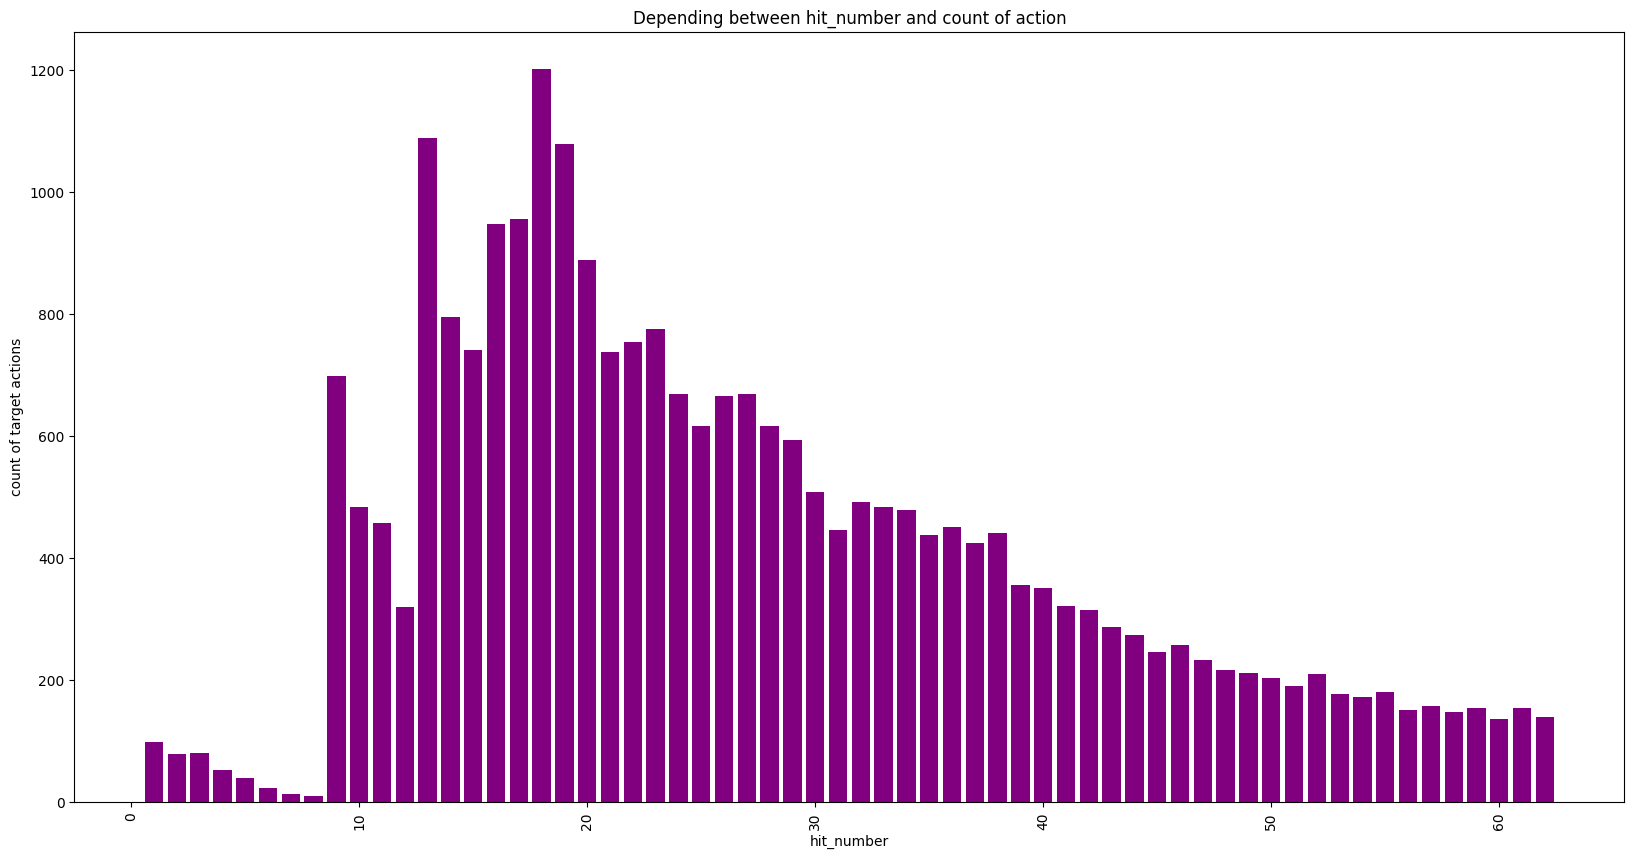

In [111]:
plt.figure(figsize=(20, 10))
plt.bar(stats_hits['hit_number'], stats_hits['count_of_actions'], color='purple')
plt.xticks(rotation=90)
plt.xlabel('hit_number')
plt.ylabel('count of target actions')
plt.title('Depending between hit_number and count of action')

Пик целевых действия наблюдается с 9 до 25 кликов. Дальше пользователь, вероятно, сомневается и количество целевых действий падает

За которые по счёту сессии совершаются в основном целевые действия?

In [112]:
stats_sessions = curr.groupby(['visit_number'], as_index=False)[['event_action']].count()
stats_sessions = stats_sessions.rename(columns={'event_action': 'count_of_actions'})
stats_sessions.head(5)

,visit_number,count_of_actions
0,1,17860
1,2,3690
2,3,1270
3,4,864
4,5,493


Text(0.5, 1.0, 'distribution of browsers in Russia')

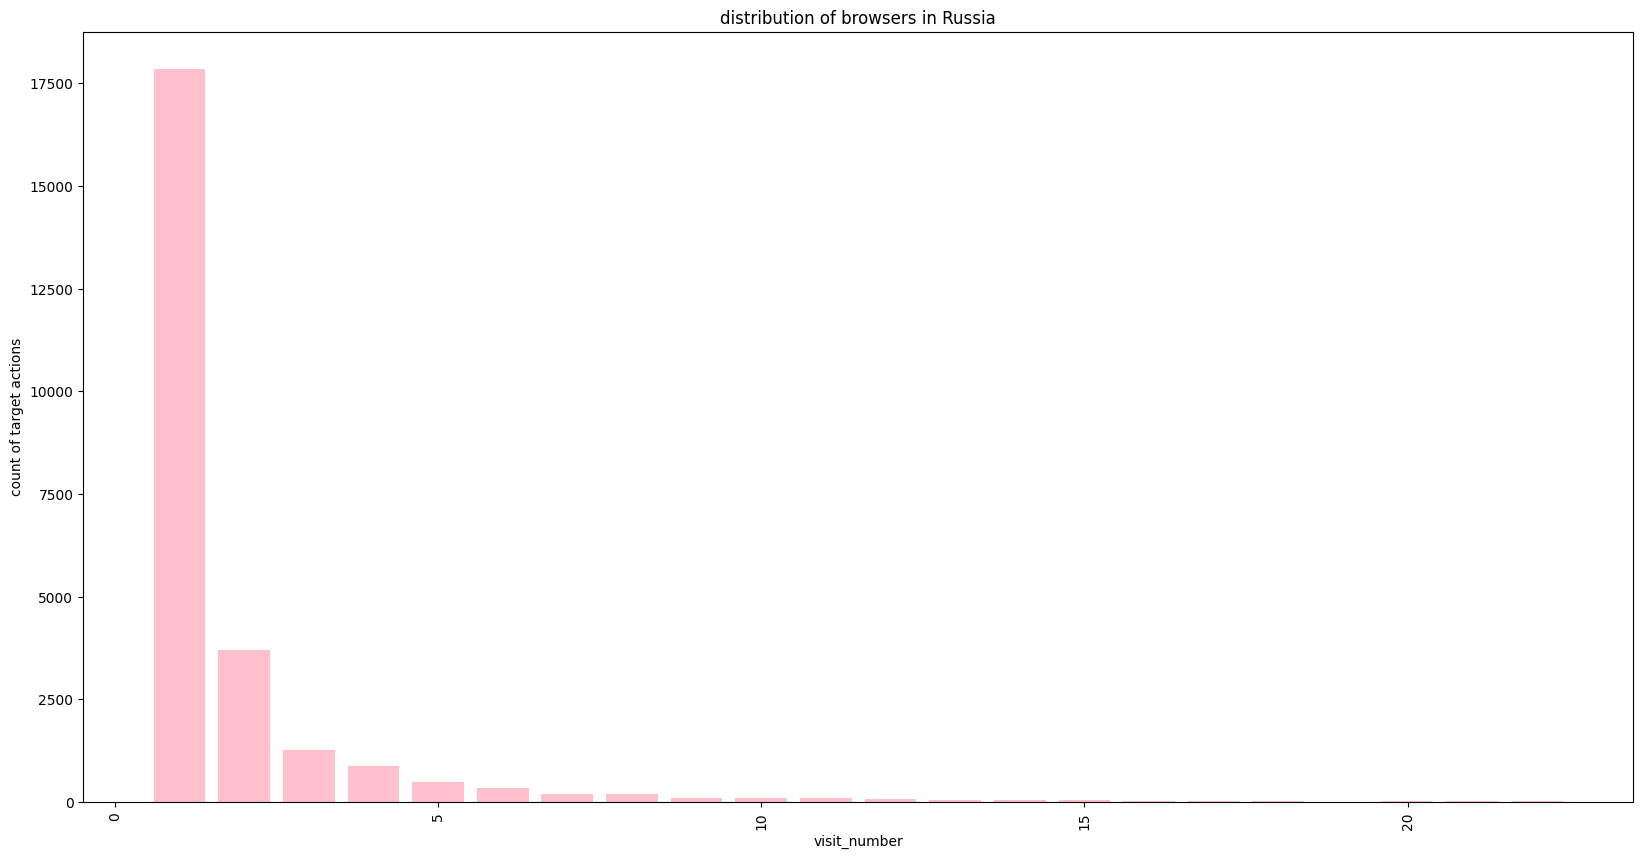

In [113]:
plt.figure(figsize=(20, 10))
plt.bar(stats_sessions['visit_number'], stats_sessions['count_of_actions'], color='pink')
plt.xticks(rotation=90)
plt.xlabel('visit_number')
plt.ylabel('count of target actions')
plt.title('distribution of browsers in Russia')

Вероятность совершения целевого действия наибольшая при первом визите. При дальнейших посещениях, похоже, возникают сомнения.

#### Дополнительные графики

##### Зависимость бренда от способа рекламного привлечения

In [114]:
df_clean.brand.unique()

<StringArray>
[        'skoda',        'toyota', 'mercedes-benz',       'hyundai',
         'haval',           'bmw',      'lada-vaz',           'kia',
    'volkswagen',       'renault',         'volvo',          'mini',
    'land-rover',        'nissan',         'lexus',          'audi',
       'porsche',       'peugeot',         'honda',      'infiniti']
Length: 20, dtype: str

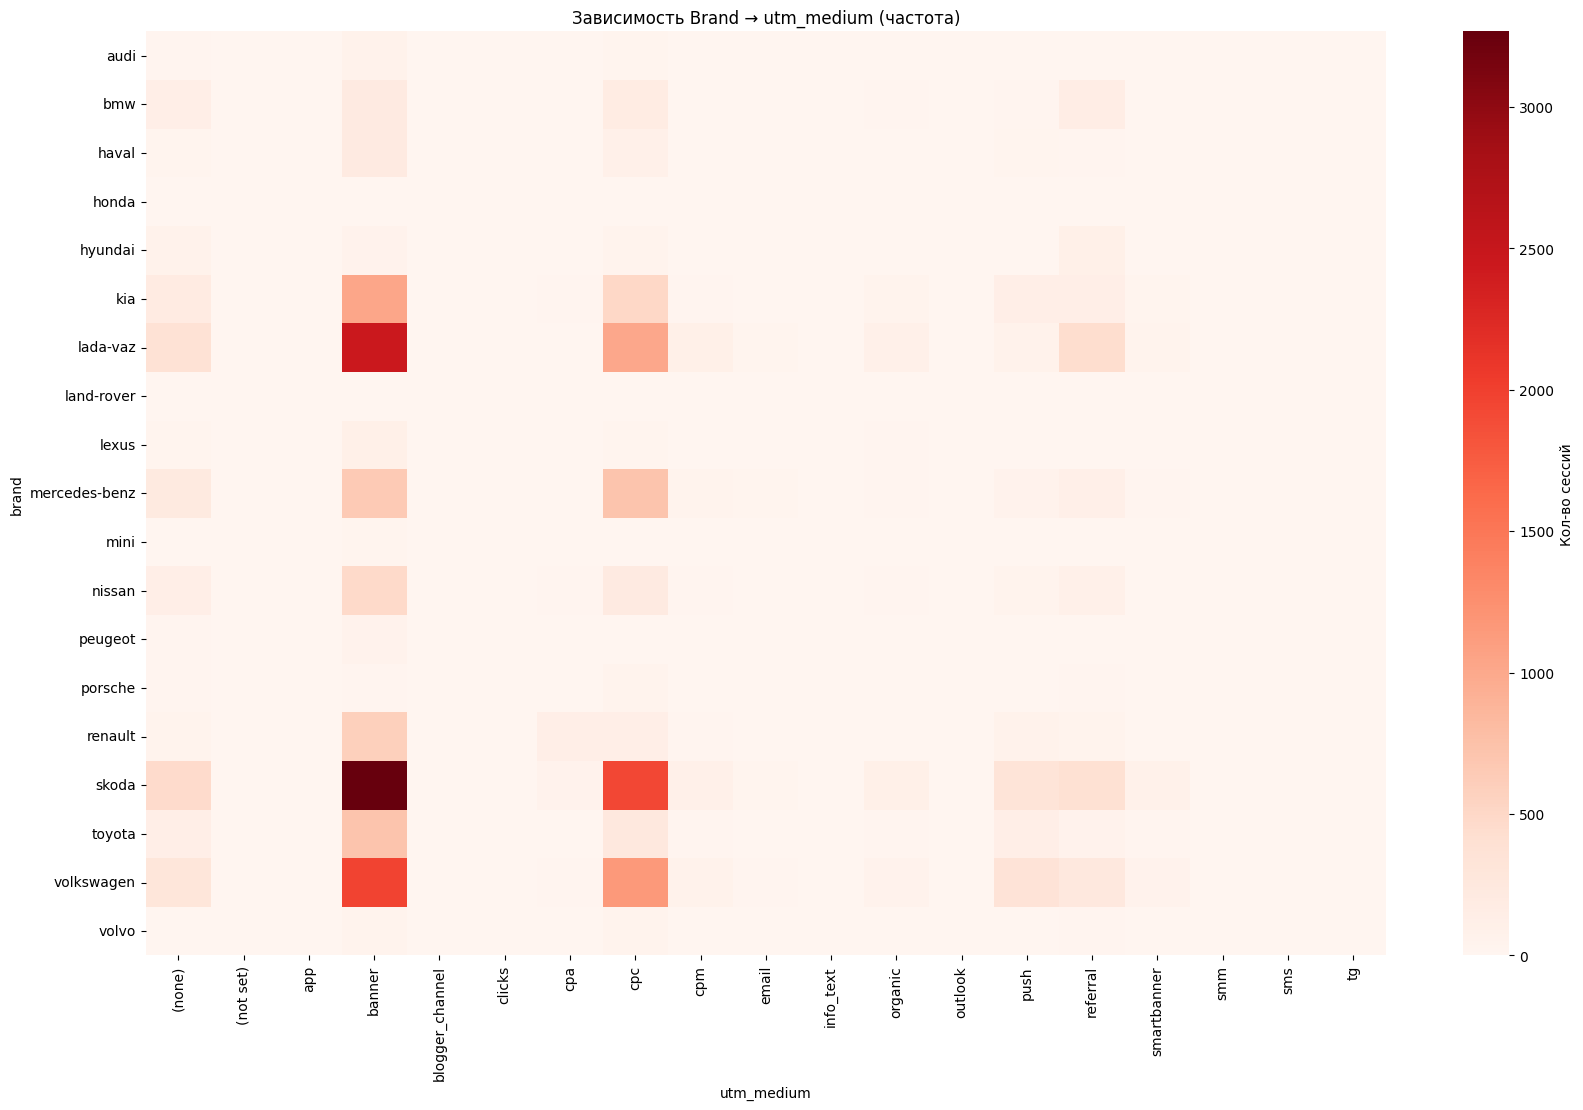

In [115]:
pivot = pd.crosstab(curr['brand'], curr['utm_medium'])
plt.figure(figsize=(20, 12))
sns.heatmap(pivot, annot=False, cmap='Reds', cbar_kws={'label': 'Кол-во сессий'})
plt.title('Зависимость Brand → utm_medium (частота)')
plt.xticks(rotation=90)
plt.show()

Можно увидеть, что на баннерах активно рекламируется skoda, lada-vaz и volkswagen. Cpc активно приводит клиентов на покупку шкоды. При этом, многие виды рекламного привлечения просто напросто никого не приводят (например, email, smm и ер). В заключении по этому графику можно также заметить, что раз уж баннеры приводят действительно много клиентов, то можно расширить их разнообразие в плане марки автомобиля.

##### Зависимость выбора бренда от города

In [116]:
curr.geo_city.nunique()

265

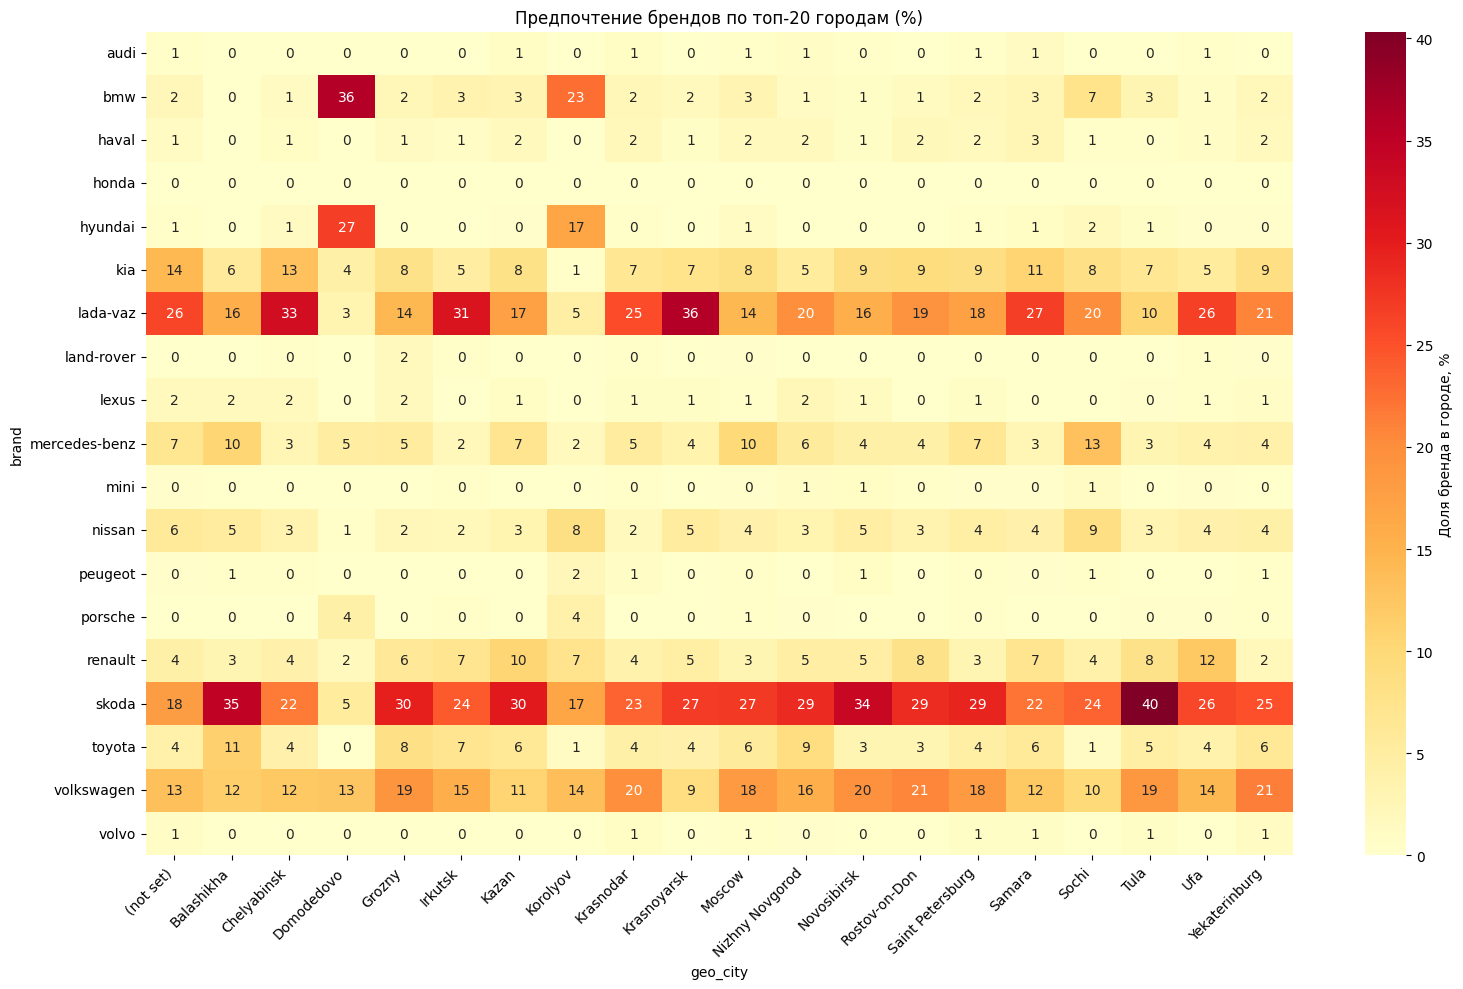

In [117]:
# топ-20 городов, т.к отобразить все 263 будет черезчур трудно
top_cities = curr['geo_city'].value_counts().head(20).index
df_top = curr[curr['geo_city'].isin(top_cities)]

pivot = pd.crosstab(df_top['brand'], df_top['geo_city'], normalize='columns') * 100

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Доля бренда в городе, %'})
plt.title('Предпочтение брендов по топ-20 городам (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Как видно на графике, в Домодедово людям по нраву разъезжать на bmw и hyundai, однако skod-у здесь избегают. В остальных регионах выбор падает либо на skoda, либо на lada-vaz с volkswagen. В итоге мало что можно сказать, нужно построить ещё один график. График распределения городов по рекламному методу

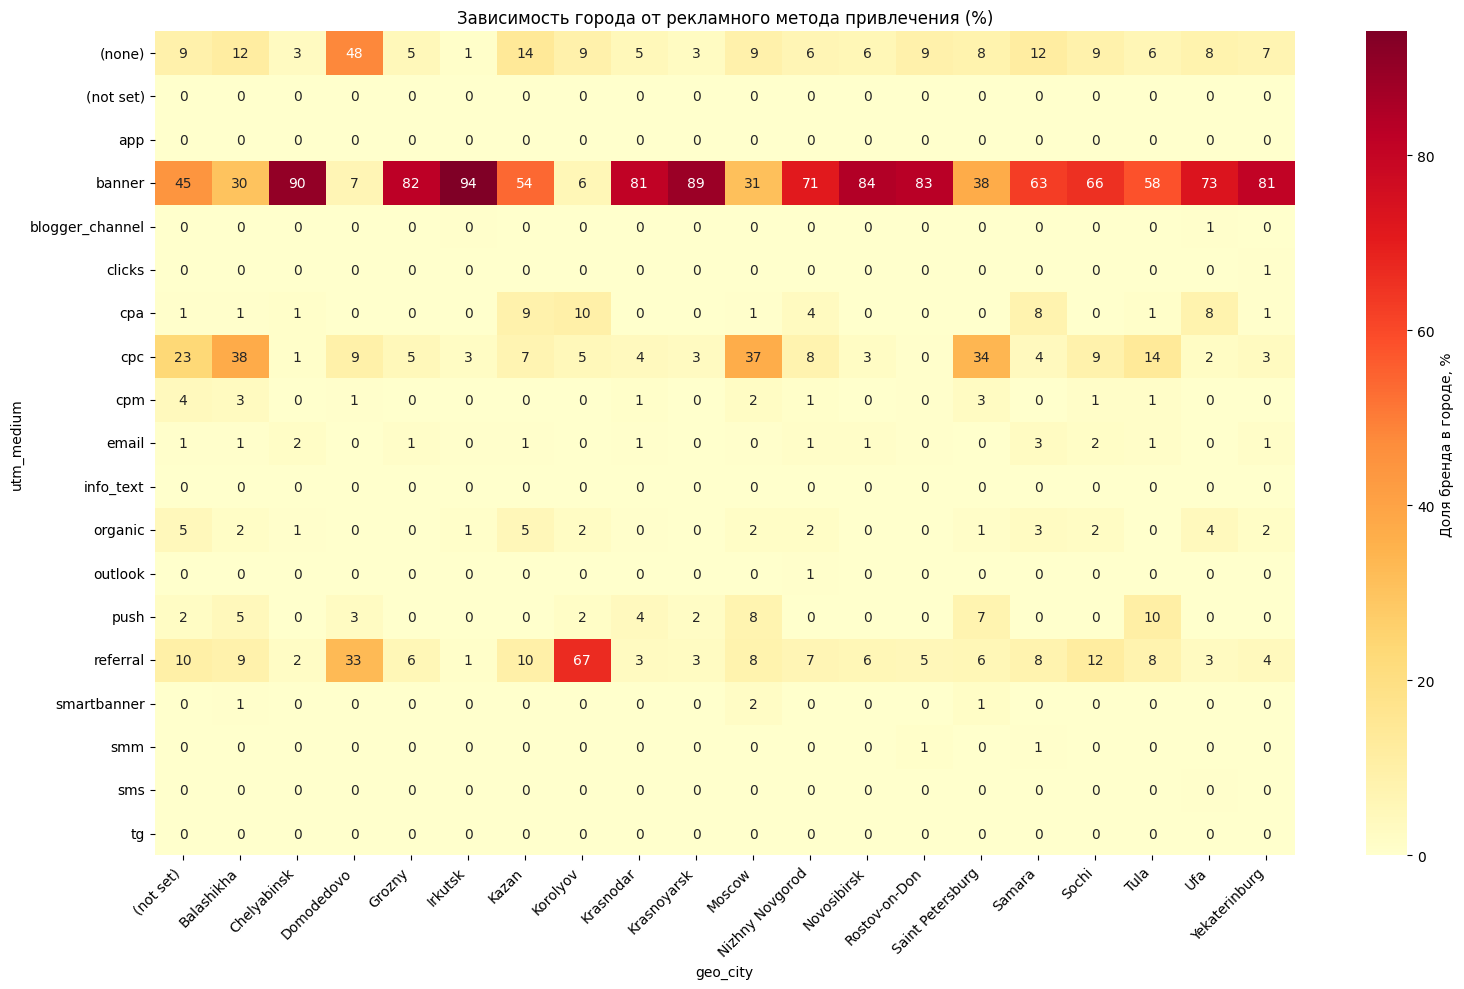

In [118]:
pivot = pd.crosstab(df_top['utm_medium'], df_top['geo_city'], normalize='columns') * 100

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd', 
            cbar_kws={'label': 'Доля бренда в городе, %'})
plt.title('Зависимость города от рекламного метода привлечения (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Причина почему в Домодедово не ездят на skoda на глаза: там, похоже, совсем нет баннеров; основной метод привлечения здесь - реферальная программа. В остальных городах всё тоже объясняется. Все ездят на skoda, volkswagen, lada-vaz, т.к основным методом привлечения являются баннеры с этими марками

### Вывод по графикам

#### По поводу рекламы 

Во-первых, необходимо избавится от невыгодных методов привлечения клиентов: email, smm, info_text, tg, smartbanner, outlook, clicks, blogger_channel. Некоторые методы из последующего списка можно улучшить, т.к у них есть всё-же привлечение: cpa, cpm, cpc, referral.

Во-вторых, баннеры рекламируют небольшое количество марок автомобилей. Т.к этот метод привлечения является основным и самым сильным, требуется рекламировать больше марок автомобилей. Также необходимо разобраться с баннерами в Домодедово (они функционируют? Их достаточно? Есть ли они там вообще?)


#### По поводу целевых действий

Пик целевых действий происходит на момент первой сессии в 9-25 кликах. При этом, если это уже вторая сессия, количество целевых действий значительно снижается. Также при росте кликов (от 25) количество целевых действий падает. Крайне редко целевые действия совершаются сразу (на первых кликах). 

### Вычисление корреляций

Сначала нужно предположить, между какими переменными вообще возможна корреляция. Конечно же у количественных

In [119]:
df_clean.info()

<class 'pandas.DataFrame'>
Index: 2973007 entries, 6 to 4466559
Data columns (total 21 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                str           
 1   client_id                 str           
 2   visit_number              int64         
 3   utm_source                str           
 4   utm_medium                str           
 5   utm_campaign              str           
 6   utm_keyword               str           
 7   device_category           str           
 8   device_os                 str           
 9   device_brand              str           
 10  device_screen_resolution  str           
 11  device_browser            str           
 12  geo_country               str           
 13  geo_city                  str           
 14  visit_datetime            datetime64[us]
 15  hit_time                  float64       
 16  hit_number                float64       
 17  hit_page_path           

Начнём с колличественнных переменных. Так как их немного сделаем всё в один блок кода

Числовые колонки: ['visit_number', 'hit_time', 'hit_number']
              visit_number  hit_time  hit_number
visit_number      1.000000  0.005776   -0.024175
hit_time          0.005776  1.000000    0.419086
hit_number       -0.024175  0.419086    1.000000


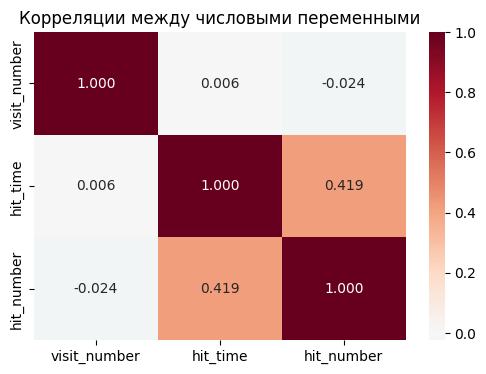

In [120]:
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
print("Числовые колонки:", list(numeric_cols))

corr_numeric = df_clean[numeric_cols].corr()
print(corr_numeric)

plt.figure(figsize=(6, 4))
sns.heatmap(corr_numeric, annot=True, fmt='.3f', cmap='RdBu_r', center=0)
plt.title('Корреляции между числовыми переменными')
plt.show()

Сильных и значительных корреляций нет, идём далее

#### Категориальные переменные

In [121]:
# Для анализа зависимостей между категориальными переменными воспользуемся методом cramers's-v
def cramers_v(x, y):
    from scipy.stats import chi2_contingency
    confusion = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion)[0]
    n = confusion.sum().sum()
    phi2 = chi2 / n
    r, k = confusion.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Сделаем список категориальных переменных, пригодных для анализа
categorical_cols = ['brand', 'geo_city', 'device_category', 'device_os', 
                    'device_brand', 'utm_medium', 'utm_source', 'visit_number']

results = []
for i, col1 in enumerate(categorical_cols):
    for col2 in categorical_cols:
        if col1 < col2:
            try:
                v = cramers_v(df_clean[col1], df_clean[col2])
                results.append({'var1': col1, 'var2': col2, 'cramers_v': v})
            except:
                pass

results_df = pd.DataFrame(results).sort_values('cramers_v', ascending=False)
print("\nСильные связи (категория - категория):")
print(results_df[results_df['cramers_v'] > 0.3])


Сильные связи (категория - категория):
               var1             var2  cramers_v
20     device_brand  device_category   0.724289
25       utm_medium       utm_source   0.705791
11  device_category        device_os   0.615989
21     device_brand        device_os   0.454613
13  device_category       utm_source   0.389768
12  device_category       utm_medium   0.340418


Запомним первые три связи. Здесь довольно большая корреляция, что может сказаться на дальнейшей обработке данных для обучения модели

#### Анализ качественных переменных с колличественными

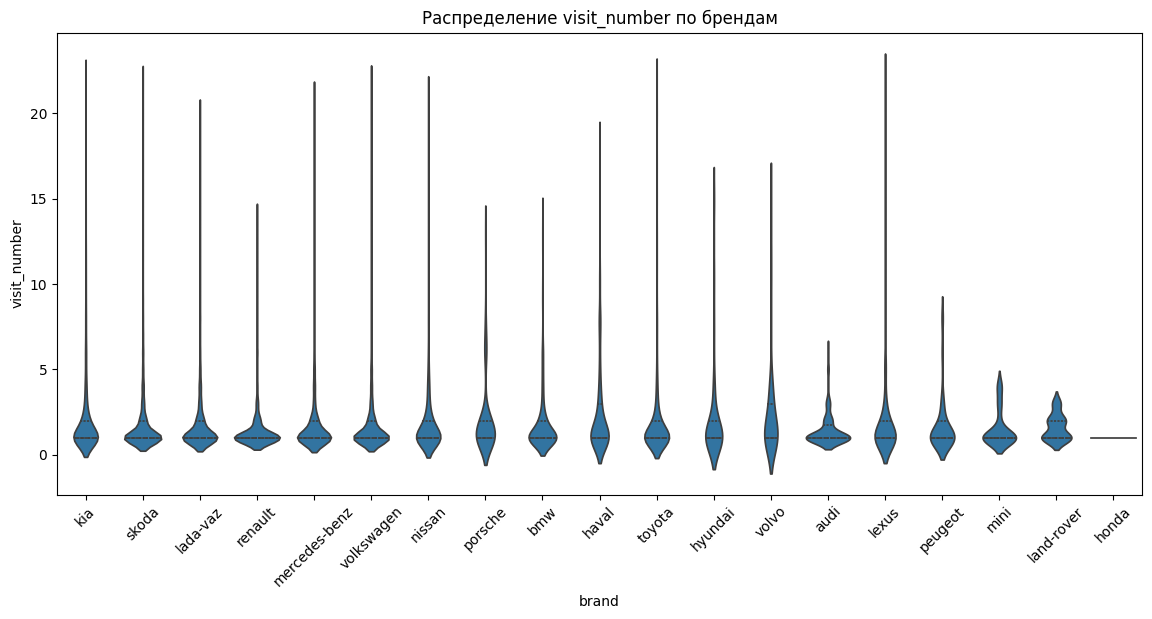

In [122]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=curr, x='brand', y='visit_number', inner='quartile')
plt.xticks(rotation=45)
plt.title('Распределение visit_number по брендам')
plt.show()

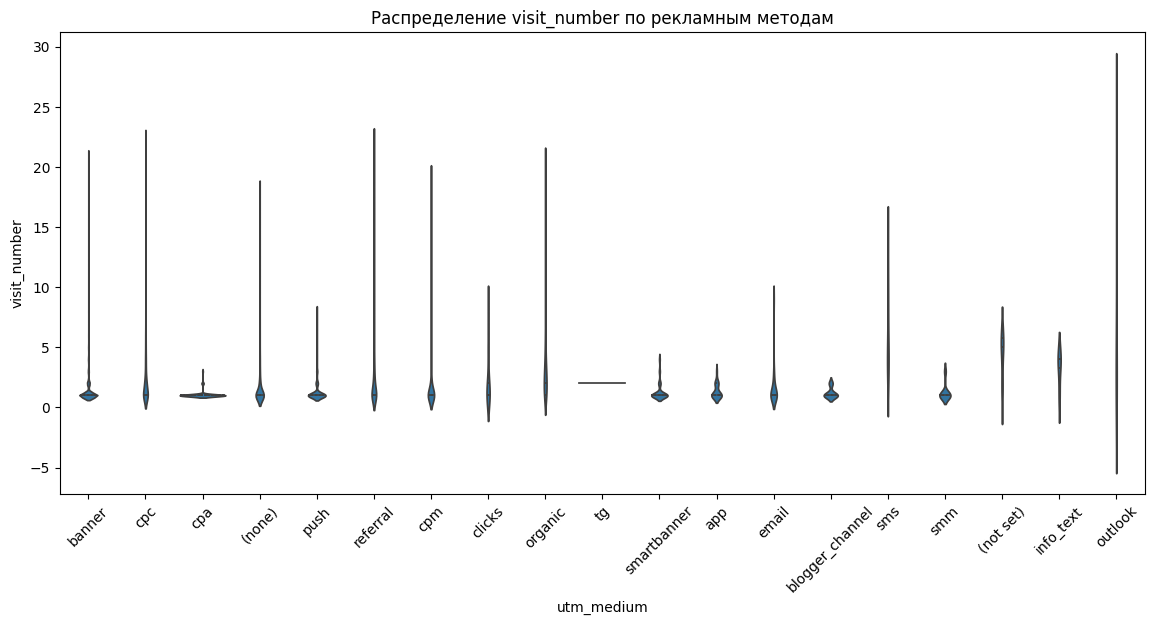

In [123]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=curr, x='utm_medium', y='visit_number', inner='quartile')
plt.xticks(rotation=45)
plt.title('Распределение visit_number по рекламным методам')
plt.show()

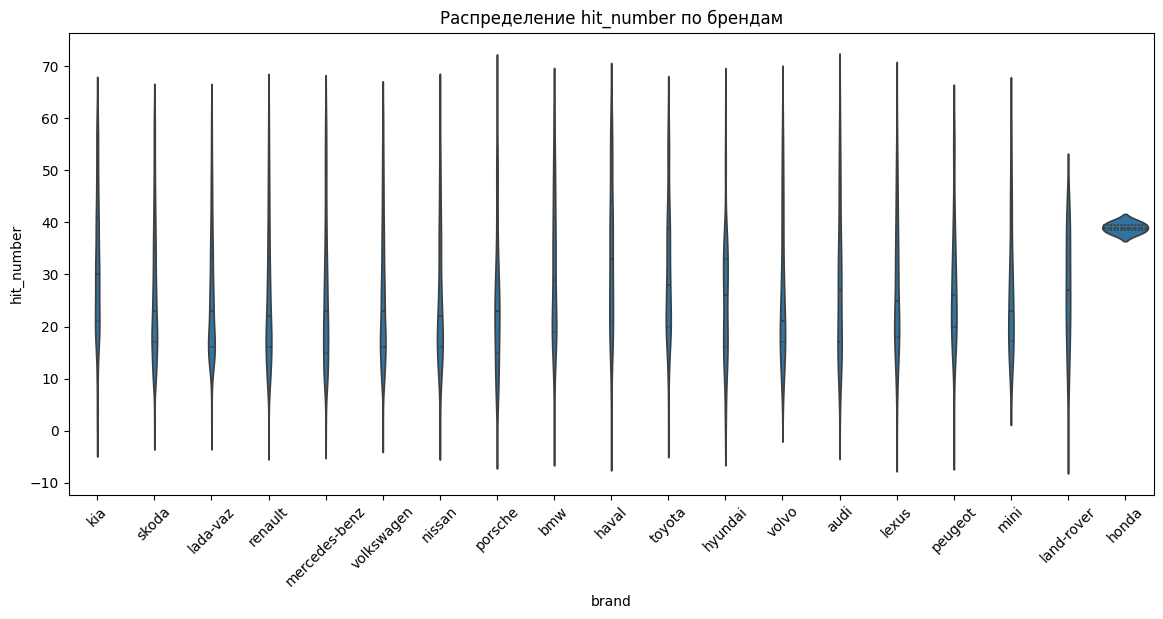

In [124]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=curr, x='brand', y='hit_number', inner='quartile')
plt.xticks(rotation=45)
plt.title('Распределение hit_number по брендам')
plt.show()

Впринципе ничего интересного. Единственное, что с хондой целевые действия совершаются только при 40-50 кликах.

### Вывод по корреляциям

Значительные корреляции были замечены у переменных, близких по своей сущности. Вот эти зависимости: utm_medium ~ utm_source, device_brand ~ device_category, device_category ~ device_os.

На этапе feature engineering-а удалим переменные utm_source (utm_medium более информативная переменная), device_brand и device_os (device_category их обобщает)

In [125]:
del mask
del stats_hits
del stats
del stats_sessions
del numeric_cols
del df_top
del pivot
gc.collect()

92574

In [126]:
del curr
gc.collect()

29434

# Feature Engineering

In [127]:
df = df_clean.copy()
df.head(5)

,session_id,client_id,visit_number,utm_source,utm_medium,utm_campaign,utm_keyword,device_category,device_os,device_brand,...,device_browser,geo_country,geo_city,visit_datetime,hit_time,hit_number,hit_page_path,event_category,event_action,brand
6,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,45.0,3.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
7,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,485.0,7.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda
8,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,550.0,8.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
9,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,484.0,5.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_new_card,skoda
10,9055455318486370642.1640843788.1640843788,2108387490.1640843602,1,TxKUcPpthBDPieTGmVhx,cpc,FTjNLDyTrXaWYgZymFkV,PwscUHjoUJDrtfWESIHj,tablet,Android,Lenovo,...,YaBrowser,Russia,Saint Petersburg,2021-12-30 08:56:28,45.0,4.0,sberauto.com/cars/all/skoda/rapid/bf24b977?ren...,card_web,view_card,skoda


In [128]:
df.info()

<class 'pandas.DataFrame'>
Index: 2973007 entries, 6 to 4466559
Data columns (total 21 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   session_id                str           
 1   client_id                 str           
 2   visit_number              int64         
 3   utm_source                str           
 4   utm_medium                str           
 5   utm_campaign              str           
 6   utm_keyword               str           
 7   device_category           str           
 8   device_os                 str           
 9   device_brand              str           
 10  device_screen_resolution  str           
 11  device_browser            str           
 12  geo_country               str           
 13  geo_city                  str           
 14  visit_datetime            datetime64[us]
 15  hit_time                  float64       
 16  hit_number                float64       
 17  hit_page_path           

In [129]:
json_str = df.iloc[[0]].to_json(orient='records')
json_str

/tmp/ipykernel_4479/3227009509.py:1: Pandas4Warning: The default 'epoch' date format is deprecated and will be removed in a future version, please use 'iso' date format instead.
  json_str = df.iloc[[0]].to_json(orient='records')


'[{"session_id":"9055455318486370642.1640843788.1640843788","client_id":"2108387490.1640843602","visit_number":1,"utm_source":"TxKUcPpthBDPieTGmVhx","utm_medium":"cpc","utm_campaign":"FTjNLDyTrXaWYgZymFkV","utm_keyword":"PwscUHjoUJDrtfWESIHj","device_category":"tablet","device_os":"Android","device_brand":"Lenovo","device_screen_resolution":"602x1029","device_browser":"YaBrowser","geo_country":"Russia","geo_city":"Saint Petersburg","visit_datetime":1640854588000,"hit_time":45.0,"hit_number":3.0,"hit_page_path":"sberauto.com\\/cars\\/all\\/skoda\\/rapid\\/bf24b977?rental_page=rental_car","event_category":"card_web","event_action":"view_new_card","brand":"skoda"}]'

## Очистим ненужные колонки 

#### Посмотрим на некоторые колонки, к которым есть сомнения

In [130]:
df.utm_campaign.unique() # Удаляем, много неинформативных данных

<StringArray>
['FTjNLDyTrXaWYgZymFkV', 'LEoPHuyFvzoNfnzGgfcd', 'LTuZkdKfxRGVceoWkVyg',
 'gecBYcKZCPMcVYdSSzKP',         'campaignless', 'SgIUDYUKnyWHVowUOqid',
 'GWZGdHKPgmZPNPwkJshU', 'XGYOaJEasWTwAKNdCGVX', 'dMIPlIFgKzafYgowsqtp',
 'nSReTmyFtbSjlPrTKoaX',
 ...
 'wWtqUernqIfFLJdJysKt', 'maiZOsuEAMdeoRVsYoFk', 'viJRyeJfSPaqDtxzXuOp',
 'vgnFYqlaqdoLREHruWar', 'JSpqZazJfaFgfkyRxcgv', 'aPqwsNrUDOqqlOPbgStP',
 'jXKhPqSdMbcUvJsaNCVA', 'MXqmDyetMTICSSitTjWV', 'wiaGHeLepWDNwXuBHvDB',
 'pbDudNzVMOgnBNGCXLTy']
Length: 249, dtype: str

In [131]:
df.device_screen_resolution.unique() # у нас есть device_category

<StringArray>
[ '602x1029',   '390x844',   '412x869',   '320x568',   '412x915',   '393x851',
   '412x892',   '375x812',   '339x716',   '384x832',
 ...
 '1600x1053',   '534x330',  '464x1028',   '442x706',  '1024x969',   '347x753',
  '450x1012',  '2240x960',  '483x1063',  '464x1123']
Length: 2686, dtype: str

In [132]:
df.device_browser.unique() # оставляем

<StringArray>
[               'YaBrowser',                   'Safari',
          'Android Webview',                   'Chrome',
          'Safari (in-app)',         'Samsung Internet',
                    'Opera',                  'Firefox',
                     'Edge',               'UC Browser',
 'Mozilla Compatible Agent']
Length: 11, dtype: str

In [133]:
df.geo_city.unique() # на самом деле, хоть данных довольно много, но город довольно важная деталь

<StringArray>
['Saint Petersburg',           'Moscow',            'Sochi',
     'Novorossiysk',        'Astrakhan',           'Reutov',
             'Tula',      'Krasnoyarsk',           'Samara',
        'Krasnodar',
 ...
        'Priozersk',            'Bavly',          'Russkiy',
       'Shchyokino',          'Nogliki',       'Prokhladny',
         'Bologoye',           'Beslan',   'Novaya Adygeya',
          'Otradny']
Length: 452, dtype: str

In [134]:
df.event_category.unique() # можно оставить, т.к сильной корреляции с event_action нету

<StringArray>
[           'card_web',         'listing_ads',          'sub_submit',
    'sub_button_click',        'main_banners',           'ad_banner',
                'quiz',                'auth',          'navigation',
              'footer', 'scrolling_main_page',                'chat',
        'profile_menu',         'search_form',                'cars',
       'sub_page_view']
Length: 16, dtype: str

In [135]:
df.utm_keyword.unique() # что-то не явное. Слишком многообразны данные

<StringArray>
['PwscUHjoUJDrtfWESIHj', 'puhZPIYqKXeFPaUviSjo',          'keywordless',
 'cdPAGAvKeBGoqAkQBuGR', 'NnplfljjtYPiMnRvogpA', 'ITfrGJNwVsHBGJMAKoct',
 'hAmNSZmQkKQKAjZEGlgb', 'aVpHHMXeGTRlQvVjmqUe', 'jfLxUKobDdJlutbwyjaU',
 'RJUQscGDTnAqljrzLLxu',
 ...
 'XvjcKxQTaHQvFIZPfhhy', 'tlfQioxYValDMNqdTGFZ', 'vIcDHlGzzFaHjErfhRtL',
 'DnEUulZAecfGPvdtZBYS', 'hIlpdXTVGwzYWIOqvhtN', 'WlbWUObZWvsimzdFdLYw',
 'maiZOsuEAMdeoRVsYoFk', 'aCaBoYaQJPVffhjBQnut', 'vhpnGVtJxagqKJLKMned',
 'icDKqLuuLakGISOQwadh']
Length: 926, dtype: str

#### Сама очистка

In [136]:
df = df.drop(['session_id', 'utm_source', 'utm_campaign',
              'utm_keyword', 'device_os', 'device_brand', 'device_screen_resolution',
              'geo_country', 'hit_page_path', 'event_category'
             ], axis=1)
df.head(5)

,client_id,visit_number,utm_medium,device_category,device_browser,geo_city,visit_datetime,hit_time,hit_number,event_action,brand
6,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,2021-12-30 08:56:28,45.0,3.0,view_new_card,skoda
7,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,2021-12-30 08:56:28,485.0,7.0,view_card,skoda
8,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,2021-12-30 08:56:28,550.0,8.0,view_new_card,skoda
9,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,2021-12-30 08:56:28,484.0,5.0,view_new_card,skoda
10,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,2021-12-30 08:56:28,45.0,4.0,view_card,skoda


## Проведём классические преобразования данных

In [137]:
df.info()

<class 'pandas.DataFrame'>
Index: 2973007 entries, 6 to 4466559
Data columns (total 11 columns):
 #   Column           Dtype         
---  ------           -----         
 0   client_id        str           
 1   visit_number     int64         
 2   utm_medium       str           
 3   device_category  str           
 4   device_browser   str           
 5   geo_city         str           
 6   visit_datetime   datetime64[us]
 7   hit_time         float64       
 8   hit_number       float64       
 9   event_action     str           
 10  brand            str           
dtypes: datetime64[us](1), float64(2), int64(1), str(7)
memory usage: 272.2 MB


In [138]:
df['visit_datetime'] = pd.to_datetime(
    df['visit_datetime'],
    format='%Y-%m-%d %H:%M:%S'
)
df.info()

<class 'pandas.DataFrame'>
Index: 2973007 entries, 6 to 4466559
Data columns (total 11 columns):
 #   Column           Dtype         
---  ------           -----         
 0   client_id        str           
 1   visit_number     int64         
 2   utm_medium       str           
 3   device_category  str           
 4   device_browser   str           
 5   geo_city         str           
 6   visit_datetime   datetime64[us]
 7   hit_time         float64       
 8   hit_number       float64       
 9   event_action     str           
 10  brand            str           
dtypes: datetime64[us](1), float64(2), int64(1), str(7)
memory usage: 272.2 MB


## Стандартизируем данные

### Преобразование даты

In [139]:
def add_date_features(df, date_col='visit_datetime'):

    df[date_col] = pd.to_datetime(df[date_col])
    
    df['hour'] = df[date_col].dt.hour
    df['dayofweek'] = df[date_col].dt.dayofweek
    df['month'] = df[date_col].dt.month
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
    
    
    df['time_block'] = pd.cut(df['hour'], 
                               bins=[0, 6, 12, 18, 24], 
                               labels=['night', 'morning', 'afternoon', 'evening'])
    
    # кодирование в формат для ML
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
    
    df['dow_sin'] = np.sin(2 * np.pi * df['dayofweek'] / 7)
    df['dow_cos'] = np.cos(2 * np.pi * df['dayofweek'] / 7)
    
    df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
    df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
    
    # Относительные признаки
    min_date = df[date_col].min()
    df['days_since_start'] = (df[date_col] - min_date).dt.days
    
    # Удаляем исходные 
    df = df.drop([date_col, 'hour', 'dayofweek', 'month'], axis=1)
    
    return df

df_data = add_date_features(df, 'visit_datetime')
df_data

,client_id,visit_number,utm_medium,device_category,device_browser,geo_city,hit_time,hit_number,event_action,brand,is_weekend,time_block,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,days_since_start
6,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,45.0,3.0,view_new_card,skoda,0,morning,0.866025,-0.500000,0.433884,-0.900969,-2.449294e-16,1.0,85
7,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,485.0,7.0,view_card,skoda,0,morning,0.866025,-0.500000,0.433884,-0.900969,-2.449294e-16,1.0,85
8,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,550.0,8.0,view_new_card,skoda,0,morning,0.866025,-0.500000,0.433884,-0.900969,-2.449294e-16,1.0,85
9,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,484.0,5.0,view_new_card,skoda,0,morning,0.866025,-0.500000,0.433884,-0.900969,-2.449294e-16,1.0,85
10,2108387490.1640843602,1,cpc,tablet,YaBrowser,Saint Petersburg,45.0,4.0,view_card,skoda,0,morning,0.866025,-0.500000,0.433884,-0.900969,-2.449294e-16,1.0,85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4466555,2108381692.1640968721,1,cpm,desktop,Chrome,Moscow,33010.0,11.0,view_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,87
4466556,2108381692.1640968721,1,cpm,desktop,Chrome,Moscow,34694.0,16.0,view_new_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,87
4466557,2108381692.1640968721,1,cpm,desktop,Chrome,Moscow,250.0,3.0,view_card,mercedes-benz,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,87
4466558,2108381692.1640968721,1,cpm,desktop,Chrome,Moscow,33533.0,14.0,view_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,87


### Остальные колличественные переменные

In [140]:
columns_for_scale = ['visit_number', 'client_id', 'hit_time', 'hit_number', 'days_since_start']

std_scaler = StandardScaler()
std_scaler.fit(df_data[columns_for_scale])
std_scaled = std_scaler.transform(df_data[columns_for_scale])

df_data[columns_for_scale] = std_scaled
df_data.tail(5)

,client_id,visit_number,utm_medium,device_category,device_browser,geo_city,hit_time,hit_number,event_action,brand,is_weekend,time_block,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,days_since_start
4466555,1.665853,-0.362578,cpm,desktop,Chrome,Moscow,-0.520354,-0.750013,view_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,1.652151
4466556,1.665853,-0.362578,cpm,desktop,Chrome,Moscow,-0.513690,-0.387431,view_new_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,1.652151
4466557,1.665853,-0.362578,cpm,desktop,Chrome,Moscow,-0.649987,-1.330144,view_card,mercedes-benz,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,1.652151
4466558,1.665853,-0.362578,cpm,desktop,Chrome,Moscow,-0.518284,-0.532464,view_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,1.652151
4466559,1.665853,-0.362578,cpm,desktop,Chrome,Moscow,-0.513690,-0.314915,view_card,bmw,0,evening,-0.965926,0.258819,-0.433884,-0.900969,-2.449294e-16,1.0,1.652151


### Сократим диапазон значений в geo_city до 30 значений

In [141]:
df_data.geo_city.value_counts()[:29]

geo_city
Moscow              1335852
Saint Petersburg     494282
(not set)             88255
Yekaterinburg         59098
Kazan                 55705
Krasnodar             55225
Samara                47141
Ufa                   39564
Nizhny Novgorod       38443
Novosibirsk           33013
Tula                  28356
Chelyabinsk           24624
Grozny                23720
Krasnoyarsk           23277
Rostov-on-Don         22692
Balashikha            21346
Voronezh              21005
Irkutsk               19713
Vladivostok           18384
Yaroslavl             15382
Sochi                 14098
Khimki                13645
Saratov               12150
Perm                  11149
Tyumen                10969
Vidnoye               10431
Odintsovo             10398
Domodedovo             9562
Mytishchi              9005
Name: count, dtype: int64

In [142]:
top30_cities = df_data['geo_city'].value_counts().head(30).index.tolist()

df_data['geo_city'] = df_data['geo_city'].apply(
    lambda x: x if x in top30_cities else 'other'
)

df_data.geo_city.unique()

<StringArray>
['Saint Petersburg',           'Moscow',            'Sochi',
            'other',             'Tula',      'Krasnoyarsk',
           'Samara',        'Krasnodar',  'Nizhny Novgorod',
      'Chelyabinsk',       'Balashikha',           'Tyumen',
    'Rostov-on-Don',      'Vladivostok',    'Yekaterinburg',
         'Voronezh',        '(not set)',             'Perm',
            'Kazan',              'Ufa',        'Mytishchi',
          'Vidnoye',      'Novosibirsk',           'Khimki',
        'Yaroslavl',           'Grozny',         'Korolyov',
        'Odintsovo',          'Irkutsk',       'Domodedovo',
          'Saratov']
Length: 31, dtype: str

## Преобразуем категориальные переменные

In [143]:
del session_df
del clean_df_session
del hit_df
del clean_hit_df
del dfs
del df_hits
del df_hits_clean
del df_clean

In [144]:
del sessions_df
del hits_df
gc.collect()

0

In [145]:
del new_dfs
gc.collect()

0

In [146]:
del results_df
del corr_numeric
del russia
gc.collect()

0

### Преобразование целевой перменной

In [147]:
df_data.event_action.unique()

<StringArray>
[                       'view_new_card',
                            'view_card',
                           'photos_all',
                               'photos',
                       'go_to_car_card',
                   'sub_submit_success',
           'sub_car_claim_submit_click',
                  'sub_car_claim_click',
                'click_on_subscription',
                         'analystlabel',
 ...
 'sber_id_auth_show_deactivation_popup',
              'sber_id_auth_back_error',
                        'go_to_support',
                         'search_km_to',
       'new_year_road_help_banner_show',
                          'sub_landing',
     'show_plug_entered_six_months_ago',
                     'tap_on_phone_800',
   'sber_id_auth_click_on_deactivation',
                      'search_power_to']
Length: 106, dtype: str

Все на месте. Можно преобразовывать. 1 - целевое действие. 0 - другое

In [148]:
def objective_function(data):
    objective = ['sub_car_claim_click', 'sub_car_claim_submit_click',
    'sub_open_dialog_click', 'sub_custom_question_submit_click',
    'sub_call_number_click', 'sub_callback_submit_click', 'sub_submit_success',
    'sub_car_request_submit_click']

    if data.event_action in objective:
        return 1
    else:
        return 0

df_data['event_action'] = df_data.apply(objective_function, axis=1)
df_data.event_action.unique()

array([0, 1])

In [149]:
gc.collect()

0

In [150]:
columns_cat_1 = ['utm_medium', 'device_category', 'device_browser', 'brand', 'geo_city', 'time_block']

ohe = OneHotEncoder(sparse_output=False)
ohe.fit(df_data[columns_cat_1])
print("Fitted!")

Fitted!


In [151]:
encoded = ohe.transform(df_data[columns_cat_1])
print("Encoded!")

Encoded!


In [152]:
gc.collect()

0

In [153]:
df_data[ohe.get_feature_names_out()] = encoded
print("Applied!")

Applied!


/tmp/ipykernel_4479/123775947.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_data[ohe.get_feature_names_out()] = encoded


In [154]:
df_data = df_data.drop(columns_cat_1, axis=1)
df_data

,client_id,visit_number,hit_time,hit_number,event_action,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,...,geo_city_Vladivostok,geo_city_Voronezh,geo_city_Yaroslavl,geo_city_Yekaterinburg,geo_city_other,time_block_afternoon,time_block_evening,time_block_morning,time_block_night,time_block_nan
6,1.665862,-0.362578,-0.650798,-1.330144,0,0,0.866025,-0.500000,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1.665862,-0.362578,-0.649057,-1.040078,0,0,0.866025,-0.500000,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,1.665862,-0.362578,-0.648800,-0.967562,0,0,0.866025,-0.500000,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,1.665862,-0.362578,-0.649061,-1.185111,0,0,0.866025,-0.500000,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10,1.665862,-0.362578,-0.650798,-1.257627,0,0,0.866025,-0.500000,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4466555,1.665853,-0.362578,-0.520354,-0.750013,0,0,-0.965926,0.258819,-0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4466556,1.665853,-0.362578,-0.513690,-0.387431,0,0,-0.965926,0.258819,-0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4466557,1.665853,-0.362578,-0.649987,-1.330144,0,0,-0.965926,0.258819,-0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4466558,1.665853,-0.362578,-0.518284,-0.532464,0,0,-0.965926,0.258819,-0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [155]:
gc.collect()
time.sleep(5)

## Проверка и сохранение

Сохраним OHE и StandartScaler

In [156]:
joblib.dump({'ohe': ohe, 'scaler': std_scaler}, 'model/transformers.pkl')

['model/transformers.pkl']

# Modeling

Определим задачу машинного обучения. Это задача бинарной классификации. Нам подойдут модели: случайный лес, логистическая регрессия, линейная регрессия, многослойный персептрон. Сначала проведём тюнинг моделей, а затем протестируем их на кросс-валидации, после чего выведем наилучшую модель.

## Загрузка и подготовка данных

In [157]:
del std_scaled
gc.collect()

0

In [158]:
del encoded
gc.collect()

0

In [159]:
del ohe
del std_scaler
gc.collect()

0

In [160]:
gc.collect()
print("Taking a break...")
time.sleep(10)

Taking a break...


In [161]:
df = df_data
df.head(5)

,client_id,visit_number,hit_time,hit_number,event_action,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,...,geo_city_Vladivostok,geo_city_Voronezh,geo_city_Yaroslavl,geo_city_Yekaterinburg,geo_city_other,time_block_afternoon,time_block_evening,time_block_morning,time_block_night,time_block_nan
6,1.665862,-0.362578,-0.650798,-1.330144,0,0,0.866025,-0.5,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,1.665862,-0.362578,-0.649057,-1.040078,0,0,0.866025,-0.5,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
8,1.665862,-0.362578,-0.648800,-0.967562,0,0,0.866025,-0.5,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9,1.665862,-0.362578,-0.649061,-1.185111,0,0,0.866025,-0.5,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10,1.665862,-0.362578,-0.650798,-1.257627,0,0,0.866025,-0.5,0.433884,-0.900969,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [162]:
df.event_action.value_counts()

event_action
0    2947468
1      25539
Name: count, dtype: int64

In [163]:
df_tune = df.iloc[0:100000]

X_ = df_tune.drop(['event_action'], axis=1)
y_ = df_tune['event_action']

x_train_, x_test_, y_train_, y_test_ = train_test_split(X_, y_, test_size=0.3, random_state=42)

In [164]:
df_tune.event_action.value_counts()

event_action
0    99118
1      882
Name: count, dtype: int64

## Тюнинг моделей


### Случайный лес

In [165]:
time.sleep(5)
rf_tune = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [50, 100, 150],           
    'max_depth': [10, 15, 20, None],          
    'min_samples_split': [5, 10, 20],         
    'min_samples_leaf': [2, 4, 8],            
    'max_features': ['sqrt', 'log2', 0.3, 0.5], 
    'bootstrap': [True, False]                
}

random_search_rf = RandomizedSearchCV(
    rf_tune,
    param_distributions=param_dist_rf,
    n_iter=30,  # количество итераций
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1, 
    pre_dispatch='2*n_jobs'  # экономия памяти
)

print("Pending...")
random_search_rf.fit(x_train_, y_train_)

print("\n" + "="*50)
print("Best params:")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nThe best ROC-AUC: {random_search_rf.best_score_:.4f}")
time.sleep(5)
del random_search_rf
del rf_tune
gc.collect()

Pending...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params:
  n_estimators: 150
  min_samples_split: 5
  min_samples_leaf: 4
  max_features: sqrt
  max_depth: 20
  bootstrap: False

The best ROC-AUC: 0.8864


50

In [166]:
target_mean = y_test_.mean()
target_mean

np.float64(0.008866666666666667)

Сразу можно заметить утечку данных. Процент целевый действий 0.9 %, а roc_auc получается около 90 %, что просто невозможно. Но где утечка данных? Какие переменные заглядывают в будуще? Можно вспомнить, что у нас была корреляция между hit_time и hit_number. При этом, как можно догадаться, переменная hit_number заглядывает в будущее. От неё нужно избавиться на тестовой выборке df_tune и попробывать ещё раз обучить случайный лес. Hit_time может тоже иметь сильную корреляцию, так что и его следует удалить. Однако у нас ещё есть пара лишних столбцов. Hit_time может тоже иметь сильную корреляцию, так что и его следует удалить. В итоге данные сосредоточатся только на существенных и не связанных между собою данных.

In [167]:
time.sleep(5)
x_train_ = x_train_.drop(['hit_number', 'hit_time', 'client_id'], axis=1)
x_test_ = x_test_.drop(['hit_number', 'hit_time', 'client_id'], axis=1)

gc.collect()

0

In [168]:
x_train_

,visit_number,is_weekend,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,days_since_start,utm_medium_(none),...,geo_city_Vladivostok,geo_city_Voronezh,geo_city_Yaroslavl,geo_city_Yekaterinburg,geo_city_other,time_block_afternoon,time_block_evening,time_block_morning,time_block_night,time_block_nan
115497,-0.362578,0,-1.000000e+00,-1.836970e-16,-0.433884,-0.900969,-2.449294e-16,1.000000,1.389379,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
90962,-0.362578,0,-2.588190e-01,9.659258e-01,-0.433884,-0.900969,-2.449294e-16,1.000000,0.863834,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
41370,-0.362578,1,-5.000000e-01,8.660254e-01,-0.781831,0.623490,-5.000000e-01,0.866025,-0.374949,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
81224,0.555078,1,-9.659258e-01,2.588190e-01,-0.974928,-0.222521,-8.660254e-01,0.500000,-1.463577,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
98595,1.472735,0,-8.660254e-01,-5.000000e-01,-0.433884,-0.900969,-8.660254e-01,0.500000,-1.501115,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9398,-0.362578,0,-8.660254e-01,5.000000e-01,0.781831,0.623490,-8.660254e-01,0.500000,-1.613732,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
82987,0.555078,0,-2.588190e-01,9.659258e-01,0.974928,-0.222521,-8.660254e-01,0.500000,-0.787877,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
115958,-0.362578,0,-5.000000e-01,8.660254e-01,-0.433884,-0.900969,-2.449294e-16,1.000000,1.652151,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
1269,-0.362578,0,-5.000000e-01,8.660254e-01,0.433884,-0.900969,-5.000000e-01,0.866025,0.037979,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [169]:
test_rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=20,
    bootstrap=False,
    class_weight='balanced'
)
test_rf.fit(x_train_, y_train_)

test_prediction_rf = test_rf.predict_proba(x_test_)[:, 1]
print(test_prediction_rf)
print(roc_auc_score(y_test_, test_prediction_rf))

[0.06302068 0.00694609 0.0323049  ... 0.01016756 0.14846868 0.25268197]
0.8721698306437379


Заодно и посмотрим на влияние фичей

In [170]:
f_imp_list = list(zip(x_train_.columns, test_rf.feature_importances_))
f_imp_list

[('visit_number', np.float64(0.045350406967557794)),
 ('is_weekend', np.float64(0.013625179050152434)),
 ('hour_sin', np.float64(0.06762834430102926)),
 ('hour_cos', np.float64(0.06831186815368721)),
 ('dow_sin', np.float64(0.054404150339403795)),
 ('dow_cos', np.float64(0.03574982334022272)),
 ('month_sin', np.float64(0.022409928726841177)),
 ('month_cos', np.float64(0.022450383778701555)),
 ('days_since_start', np.float64(0.10835294628103817)),
 ('utm_medium_(none)', np.float64(0.024845563060318307)),
 ('utm_medium_(not set)', np.float64(2.400050021730093e-05)),
 ('utm_medium_app', np.float64(0.001333258369682629)),
 ('utm_medium_banner', np.float64(0.03831799090053647)),
 ('utm_medium_blogger_channel', np.float64(0.00023595927669385717)),
 ('utm_medium_blogger_header', np.float64(1.698459015412479e-06)),
 ('utm_medium_blogger_stories', np.float64(5.685083497037262e-06)),
 ('utm_medium_clicks', np.float64(4.794686654659748e-05)),
 ('utm_medium_cpa', np.float64(0.0023703184320036396))

In [171]:
time.sleep(5)
del test_rf
gc.collect()

46

Что же, days since strart, похоже, заглядывает в будущее. Нужно этот признак удалить

In [172]:
time.sleep(10)
x_train_ = x_train_.drop(['days_since_start'], axis=1)
x_test_ = x_test_.drop(['days_since_start'], axis=1)

gc.collect()

0

In [173]:
test_rf = RandomForestClassifier(
    n_estimators=150,
    min_samples_split=5,
    min_samples_leaf=4,
    max_features='sqrt',
    max_depth=20,
    bootstrap=False,
    class_weight='balanced'
)
test_rf.fit(x_train_, y_train_)

test_prediction_rf = test_rf.predict_proba(x_test_)[:, 1]
print(test_prediction_rf)
print(roc_auc_score(y_test_, test_prediction_rf))

[0.02736456 0.00070104 0.01152472 ... 0.01458074 0.14514633 0.20298061]
0.8719681678805206


In [174]:
del test_rf
gc.collect()

46

Результат вполне неплохой. Однако нужно посмотреть на другие модели. Может быть они ещё лучше себя покажут?

### Логистическая регрессия

In [175]:
time.sleep(5)
logistic_tune = LogisticRegression(random_state=42)

param_distributions_logistic = {
    'C': loguniform(0.001, 100),  # регуляризация (лог-шкала)
    'solver': ['saga'],  # только saga для больших данных и l1/elasticnet
    'l1_ratio': uniform(0, 1),  # для elasticnet (доля l1)
    'class_weight': [None, 'balanced'],  # балансировка классов
    'tol': uniform(1e-5, 1e-3)  # точность остановки
}

random_search_logistic = RandomizedSearchCV(
    logistic_tune,
    param_distributions=param_distributions_logistic,
    n_iter=30,  # количество итераций
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1, 
    pre_dispatch='2*n_jobs'  # экономия памяти
)

print("Pending...")
random_search_logistic.fit(x_train_, y_train_)

print("\n" + "="*50)
print("Best params:")
for param, value in random_search_logistic.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nThe best ROC-AUC: {random_search_logistic.best_score_:.4f}")

Pending...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/s


Best params:
  C: 0.9163741808778786
  class_weight: None
  l1_ratio: 0.8599404067363206
  solver: saga
  tol: 0.0006903075385877798

The best ROC-AUC: 0.7272


/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [176]:
time.sleep(5)
del logistic_tune
del random_search_logistic
gc.collect()

27

### Многослойный персептрон

In [177]:
time.sleep(5)
mlp_tune = MLPClassifier(random_state=42)


param_dist_mlp = {
    'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)], # слои и нейроны
    'activation': ['relu', 'tanh'],                                    
    'solver': ['adam', 'sgd', 'lbfgs'], # оптимизатор
    'alpha': [0.0001, 0.001, 0.01], # регуляризация L2
    'learning_rate_init': [0.0005, 0.001, 0.005], # начальная скорость обучения
    'batch_size': [128, 256, 512], # размер мини-батча
    'max_iter': [150],
}

random_search_mlp = RandomizedSearchCV(
    mlp_tune,
    param_distributions=param_dist_mlp,
    n_iter=30,  # количество итераций
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1, 
    pre_dispatch='2*n_jobs'  # экономия памяти
)

print("Pending...")
random_search_mlp.fit(x_train_, y_train_)

print("\n" + "="*50)
print("Best params:")
for param, value in random_search_mlp.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nThe best ROC-AUC: {random_search_mlp.best_score_:.4f}")

Pending...
Fitting 3 folds for each of 30 candidates, totalling 90 fits


/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)
/home/


Best params:
  solver: lbfgs
  max_iter: 150
  learning_rate_init: 0.0005
  hidden_layer_sizes: (50,)
  batch_size: 256
  alpha: 0.0001
  activation: tanh

The best ROC-AUC: 0.8229


/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:606: ConvergenceWarning: lbfgs failed to converge after 150 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=150).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [178]:
time.sleep(5)
del mlp_tune
del random_search_mlp
gc.collect()

27

### Ещё раз случайный лес

In [179]:
time.sleep(5)
rf_tune = RandomForestClassifier(random_state=42)

param_dist_rf = {
    'n_estimators': [50, 100, 150],           
    'max_depth': [10, 15, 20, None],          
    'min_samples_split': [5, 10, 20],         
    'min_samples_leaf': [2, 4, 8],            
    'max_features': ['sqrt', 'log2', 0.3, 0.5], 
    'bootstrap': [True, False]                
}

random_search_rf = RandomizedSearchCV(
    rf_tune,
    param_distributions=param_dist_rf,
    n_iter=30,  # количество итераций
    cv=3,
    scoring='roc_auc',
    n_jobs=-1,
    random_state=42,
    verbose=1, 
    pre_dispatch='2*n_jobs'  # экономия памяти
)

print("Pending...")
random_search_rf.fit(x_train_, y_train_)

print("\n" + "="*50)
print("Best params:")
for param, value in random_search_rf.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nThe best ROC-AUC: {random_search_rf.best_score_:.4f}")

Pending...
Fitting 3 folds for each of 30 candidates, totalling 90 fits

Best params:
  n_estimators: 150
  min_samples_split: 5
  min_samples_leaf: 2
  max_features: log2
  max_depth: 15
  bootstrap: True

The best ROC-AUC: 0.8450


В итоге выбор падает на короля бинарной классификации - логистическую регрессию.

In [180]:
time.sleep(5)
del rf_tune
del random_search_rf
gc.collect()

50

## Кросс валидация

Тут есть момент. Т.к данные у нас распределены по времени, то использовать классическое разбиение на 5 фолдов можно, но это не даст точных сведений. Обучение будем проводить с сохранением временных рамок (TimeSeriesSplit)

In [181]:
time.sleep(10)
logreg = LogisticRegression(
    C=0.22965432344634354,
    class_weight=None,
    l1_ratio=0.9717120953891037,
    solver='saga',
    tol=0.0007707850486168975
)
tscv = TimeSeriesSplit(n_splits=5)

cross_val_score(logreg, X_, y_, cv=tscv, scoring='roc_auc')
time.sleep(10)
gc.collect()

/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/home/kirik/project/sber/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


23

В конце появляется отклонение, но результат удовлетворительный. При этом заоблачных показателей не наблюдается, следовательно утечек данных нет, а модель имеет вполне хороший потенциал

## Упаковка готовой модели

In [182]:
del df_tune
del X_
del y_
del x_train_
del x_test_
del y_train_
del y_test_
del logreg
gc.collect()

0

### Подготовим модель для запаковки

In [184]:
time.sleep(5)
model = LogisticRegression(
    C=0.22965432344634354,
    class_weight=None,
    l1_ratio=0.9717120953891037,
    solver='saga',
    tol=0.0007707850486168975
)

Обучим модель и проверим её точность

In [185]:
df = df.drop(['hit_number', 'hit_time', 'client_id', 'days_since_start'], axis=1)
print("DataFrame has been completed for further work.")

DataFrame has been completed for further work.


In [186]:
X = df.drop(['event_action'], axis=1)
y = df['event_action']

del df
gc.collect()

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

# Перерыв для процессора
gc.collect()
time.sleep(10)

model.fit(x_train, y_train)

test_prediction = model.predict_proba(x_test)[:, 1]
roc = roc_auc_score(y_test, test_prediction)
print(roc)

0.6902667250986424


In [187]:
weights = model.coef_[0]
weight_list = list(zip(x_train.columns, weights))
weight_list

[('visit_number', np.float64(0.06358287754494621)),
 ('is_weekend', np.float64(-0.05944544326018483)),
 ('hour_sin', np.float64(-0.047764839968014595)),
 ('hour_cos', np.float64(-0.09397156704191732)),
 ('dow_sin', np.float64(0.003707714307400735)),
 ('dow_cos', np.float64(-0.01108232938789826)),
 ('month_sin', np.float64(-0.11664630823318377)),
 ('month_cos', np.float64(0.387646160214434)),
 ('utm_medium_(none)', np.float64(-0.2465725399704786)),
 ('utm_medium_(not set)', np.float64(0.378994485092164)),
 ('utm_medium_app', np.float64(0.564386535675653)),
 ('utm_medium_banner', np.float64(0.41096138689119727)),
 ('utm_medium_blogger_channel', np.float64(-1.3590934000741812)),
 ('utm_medium_blogger_header', np.float64(0.0)),
 ('utm_medium_blogger_stories', np.float64(-0.21065623233049677)),
 ('utm_medium_clicks', np.float64(0.6611449189212318)),
 ('utm_medium_cpa', np.float64(0.1993261817930017)),
 ('utm_medium_cpc', np.float64(0.0)),
 ('utm_medium_cpm', np.float64(-0.9787036233800834))

Стало гораздо чище, признаки показывают себя лучше. Много полезных выводов можно сделать, подготовим даже по этому поводу pdf файл. А пока удалим бесполезные фичи и переобучим модель.

In [188]:
feature_names = x_train.columns

# весовой датафрейм
feature_weights = pd.DataFrame({
    'feature': feature_names,
    'weight': weights
})

# берём только те признаки, которые отличны от нуля
non_zero_features = feature_weights[feature_weights['weight'] != 0]['feature'].tolist()

print(f"Всего признаков: {len(feature_names)}")
print(f"Признаков с weight != 0: {len(non_zero_features)}")
print(f"Признаков с weight == 0: {len(feature_names) - len(non_zero_features)}")

x_train_filtered = x_train[non_zero_features]
x_test_filtered = x_test[non_zero_features]

print(f"Новая размерность X_train: {x_train_filtered.shape}")
print(f"Новая размерность X_test: {x_test_filtered.shape}")

Всего признаков: 103
Признаков с weight != 0: 88
Признаков с weight == 0: 15
Новая размерность X_train: (2081104, 88)
Новая размерность X_test: (891903, 88)


In [189]:
del model
gc.collect()

0

In [190]:
model_complete = LogisticRegression(
    C=0.22965432344634354,
    class_weight=None,
    l1_ratio=0.9717120953891037,
    solver='saga',
    tol=0.0007707850486168975
)

# Перерыв для процессора
gc.collect()
time.sleep(5)

model_complete.fit(x_train_filtered, y_train)

test_prediction_fil = model_complete.predict_proba(x_test_filtered)[:, 1]
roc_fil = roc_auc_score(y_test, test_prediction_fil)
print(roc_fil)

0.6902648955095141


Практически не изменился показатель, зато модель максимально ориентирована

In [191]:
x_train_filtered.columns

Index(['visit_number', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin',
       'dow_cos', 'month_sin', 'month_cos', 'utm_medium_(none)',
       'utm_medium_(not set)', 'utm_medium_app', 'utm_medium_banner',
       'utm_medium_blogger_channel', 'utm_medium_blogger_stories',
       'utm_medium_clicks', 'utm_medium_cpa', 'utm_medium_cpm',
       'utm_medium_email', 'utm_medium_info_text', 'utm_medium_organic',
       'utm_medium_outlook', 'utm_medium_push', 'utm_medium_referral',
       'utm_medium_smartbanner', 'utm_medium_smm', 'utm_medium_sms',
       'device_category_desktop', 'device_category_mobile',
       'device_browser_Android Webview', 'device_browser_Chrome',
       'device_browser_Edge', 'device_browser_Firefox', 'device_browser_Opera',
       'device_browser_Safari', 'device_browser_Safari (in-app)',
       'device_browser_Samsung Internet', 'device_browser_UC Browser',
       'device_browser_YaBrowser', 'brand_audi', 'brand_bmw', 'brand_haval',
       'brand_hyundai', 'bran

### Упаковываем модель в .pkl файл

In [192]:
joblib.dump({
    'model': model_complete,
    'features': x_train_filtered.columns,
    'metadata': {
        'name': 'target_action_predictor_probability',
        'author': 'KirillTrueMLengineer',
        'date': datetime.now(),
        'accuracy': roc_fil
    }
}, 'model/logreg.pkl')

['model/logreg.pkl']